# The manifold of 1s

Geometry of the MNIST 1s in the **full 784-dimensional pixel space** — no PCA, no learning,
no dimensionality reduction anywhere. Everything below is distances between real images.

Running order matters: cell 2 builds the distance matrix every later cell uses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import mnist

rng_global = np.random.default_rng(0)

Xr, y = mnist.load("train")                      # raw uint8 [N,28,28]
X = Xr.reshape(len(Xr), -1).astype(np.float32) / 255.0
ones = X[y == 1]
n = len(ones)
sq = (ones ** 2).sum(1)

# full 6742 x 6742 distance matrix (~180 MB float32)
D = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * ones @ ones.T, 0))
np.fill_diagonal(D, 0.0)
D = (D + D.T) / 2
Dinf = D + np.eye(n, dtype=np.float32) * 1e9

nn_idx = Dinf.argmin(1)
nn_d   = Dinf.min(1)
THETA  = nn_d.mean()          # the natural length scale of this dataset

print(f"n_ones = {n}   ambient D = {ones.shape[1]}")
print(f"THETA = mean distance from a 1 to its nearest 1 = {THETA:.3f}")


def d_to_data(v, ban=()):
    """Distance from an arbitrary vector to the nearest REAL 1, excluding banned indices."""
    d = np.sqrt(np.maximum((v ** 2).sum() + sq - 2 * ones @ v, 0))
    if len(ban):
        d[list(ban)] = 1e9
    return d.min()


def grid(imgs, titles=None, cols=10, scale=1.15, suptitle=None, cmap="gray", vmin=0, vmax=1):
    imgs = np.asarray(imgs)
    rows = (len(imgs) + cols - 1) // cols
    fig, ax = plt.subplots(rows, cols, figsize=(cols * scale, rows * scale * 1.15), squeeze=False)
    for k, a in enumerate(ax.ravel()):
        if k < len(imgs):
            a.imshow(imgs[k].reshape(28, 28), cmap=cmap, vmin=vmin, vmax=vmax)
            if titles is not None:
                a.set_title(titles[k], fontsize=7, pad=2)
        a.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()

n_ones = 6742   ambient D = 784
THETA = mean distance from a 1 to its nearest 1 = 1.887


## Pixel quantisation

MNIST is `uint8`. The increment is **1/255 ≈ 0.003922**, not 1/100. The grey levels are
anti-aliasing artefacts from LeCun's preprocessing — the original NIST scans were binary.

In [2]:
vals = np.unique(Xr)
flat = Xr.ravel()
print(f"dtype {Xr.dtype}   min {Xr.min()}   max {Xr.max()}")
print(f"distinct pixel values present in all 60k images: {len(vals)}  (all 256? {len(vals)==256})")
print(f"increment after /255: {1/255:.6f}")
print(f"fraction of pixels == 0   : {(flat==0).mean():.4f}")
print(f"fraction of pixels == 255 : {(flat==255).mean():.4f}")
print(f"fraction strictly between : {((flat>0)&(flat<255)).mean():.4f}")
print(f"\nimage space is a finite lattice: 256^784 ~ 10^{784*np.log10(256):.0f} possible images")

dtype uint8   min 0   max 255
distinct pixel values present in all 60k images: 256  (all 256? True)
increment after /255: 0.003922


fraction of pixels == 0   : 0.8088
fraction of pixels == 255 : 0.0067
fraction strictly between : 0.1845

image space is a finite lattice: 256^784 ~ 10^1888 possible images


## The mean of the 1s is not a 1

The four numbers that started this thread. The centroid minimises *mean* distance to the
class, yet is farther from the nearest real 1 than a real 1 is from its own neighbour —
it sits in a hole. The set of 1s is **not convex**.

In [3]:
m = ones.mean(0)

d_mean_to_all = np.sqrt(((ones - m) ** 2).sum(1))
off = D[np.triu_indices(n, 1)]

print(f"dist(mean, nearest real 1)      = {d_mean_to_all.min():.2f}")
print(f"mean dist(mean, a random 1)     = {d_mean_to_all.mean():.2f}")
print(f"typical dist(1, its nearest 1)  = {nn_d.mean():.2f}")
print(f"typical dist(1, another 1)      = {off.mean():.2f}")

print(f"\nmean-of-1s image: min {m.min():.4f}  max {m.max():.4f}  mean {m.mean():.4f}")
print(f"  pixels never inked across ALL {n} ones: {(ones.max(0)==0).sum()} / 784")
print(f"  pixels inked in >50% of ones          : {((ones>0).mean(0)>0.5).sum()} / 784")
print(f"  pixels inked in >90% of ones          : {((ones>0).mean(0)>0.9).sum()} / 784")

dist(mean, nearest real 1)      = 3.16
mean dist(mean, a random 1)     = 4.64
typical dist(1, its nearest 1)  = 1.89
typical dist(1, another 1)      = 6.46

mean-of-1s image: min 0.0000  max 0.9659  mean 0.0760
  pixels never inked across ALL 6742 ones: 201 / 784
  pixels inked in >50% of ones          : 75 / 784
  pixels inked in >90% of ones          : 19 / 784


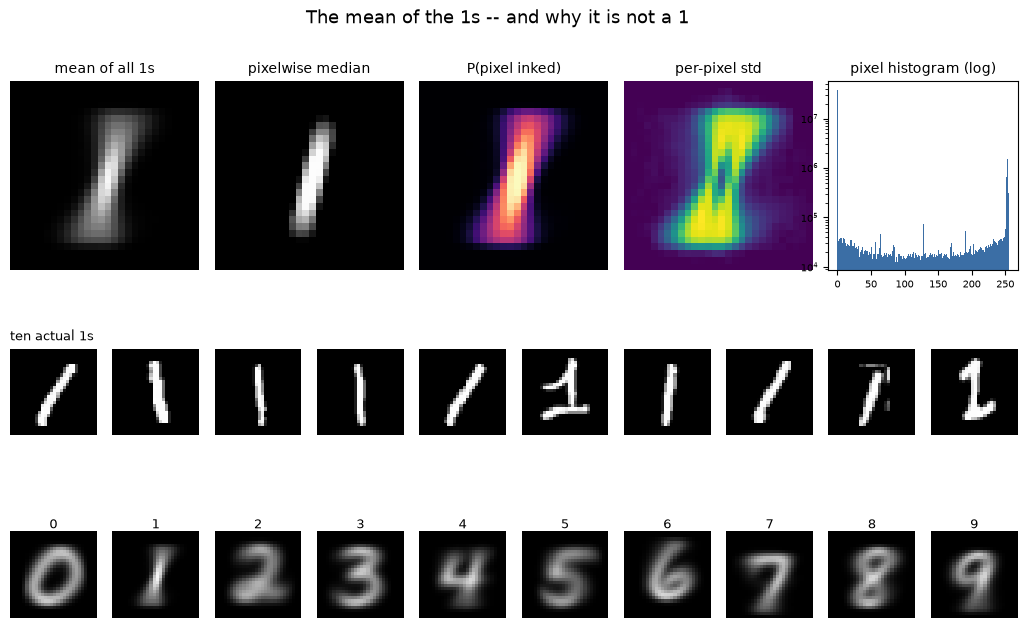

In [4]:
fig = plt.figure(figsize=(13, 7.2))
gs = fig.add_gridspec(3, 10, height_ratios=[1.55, 1, 1], hspace=.42, wspace=.18)

for k, (img, ttl, cm, vm) in enumerate([
        (m,                     "mean of all 1s",   "gray",    (0, 1)),
        (np.median(ones, 0),    "pixelwise median", "gray",    (0, 1)),
        ((ones > 0).mean(0),    "P(pixel inked)",   "magma",   (0, 1)),
        (ones.std(0),           "per-pixel std",    "viridis", (None, None))]):
    a = fig.add_subplot(gs[0, 2*k:2*k+2])
    a.imshow(img.reshape(28, 28), cmap=cm, vmin=vm[0], vmax=vm[1])
    a.set_title(ttl, fontsize=10); a.axis("off")

a = fig.add_subplot(gs[0, 8:])
a.bar(np.arange(256), np.bincount(Xr.ravel(), minlength=256), width=1.0, color="#3b6ea5")
a.set_yscale("log"); a.set_title("pixel histogram (log)", fontsize=10); a.tick_params(labelsize=7)

for j in range(10):
    a = fig.add_subplot(gs[1, j]); a.imshow(ones[j].reshape(28, 28), cmap="gray", vmin=0, vmax=1); a.axis("off")
    if j == 0: a.set_title("ten actual 1s", fontsize=9, loc="left")
for j in range(10):
    a = fig.add_subplot(gs[2, j]); a.imshow(X[y == j].mean(0).reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    a.set_title(str(j), fontsize=9, pad=2); a.axis("off")

fig.suptitle("The mean of the 1s -- and why it is not a 1", fontsize=13)
plt.show()

## Intrinsic dimension (TwoNN)

Facco et al. 2017: the ratio of each point's 2nd to 1st nearest-neighbour distance is
Pareto(d), so `d = n / sum(log mu)`. A ~13-dimensional object living in a 784-dimensional room.

In [5]:
def twonn(Xs, n_sample=2000, seed=0):
    r = np.random.default_rng(seed)
    S = Xs[r.choice(len(Xs), min(n_sample, len(Xs)), replace=False)]
    s2 = (S ** 2).sum(1)
    d2 = s2[:, None] + s2[None, :] - 2 * S @ S.T
    np.fill_diagonal(d2, np.inf)
    rr = np.sqrt(np.maximum(np.sort(d2, 1)[:, :2], 0))
    ok = rr[:, 0] > 0
    return ok.sum() / np.log(rr[ok, 1] / rr[ok, 0]).sum()

print(f"intrinsic dim, all digits : {twonn(X):.1f}")
for c in [1, 8]:
    print(f"intrinsic dim, class {c}    : {twonn(X[y==c]):.1f}")
print("ambient dim               : 784")

intrinsic dim, all digits : 12.7
intrinsic dim, class 1    : 11.2
intrinsic dim, class 8    : 16.6
ambient dim               : 784


## Are the 1s disconnected?

Single-linkage merge heights **are** the H0 persistent-homology barcode. A genuinely separated
pair of clusters shows up as a large gap at the top of the merge list. There isn't one —
the 1s are a single connected piece. Below that, single linkage **chains**: the nice clusters
at t=1.5 collapse into one blob holding two thirds of the data by t=2.0.

In [6]:
Z_single = linkage(squareform(D, checks=False), method="single")
h = Z_single[:, 2]
print("top 15 single-linkage merge heights:", np.round(h[-15:], 2))
print(f"gap between last two merges: {h[-1]-h[-2]:.3f}   (class diameter {D.max():.1f})")
print("-> no persistent gap: H0 is essentially one bar, the 1s are connected\n")

for t in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    lab = fcluster(Z_single, t, criterion="distance")
    s = np.bincount(lab)[1:]; s = s[s > 0]
    big = np.sort(s[s >= 25])[::-1]
    print(f"  t={t:.1f}  clusters {len(s):5d} | size>=25: {len(big):2d} | largest {big[:5]} "
          f"| singletons {(s==1).sum():4d} | in largest {100*big[0]/n:.1f}%")

top 15 single-linkage merge heights: [6.2  6.2  6.22 6.23 6.27 6.28 6.44 6.51 6.55 6.56 6.58 6.64 6.66 6.7
 7.1 ]
gap between last two merges: 0.401   (class diameter 13.9)
-> no persistent gap: H0 is essentially one bar, the 1s are connected

  t=1.5  clusters  5127 | size>=25:  5 | largest [534 374  85  62  36] | singletons 4848 | in largest 7.9%
  t=2.0  clusters  2095 | size>=25:  1 | largest [4455] | singletons 1983 | in largest 66.1%
  t=2.5  clusters   839 | size>=25:  1 | largest [5847] | singletons  806 | in largest 86.7%
  t=3.0  clusters   403 | size>=25:  1 | largest [6319] | singletons  385 | in largest 93.7%
  t=3.5  clusters   237 | size>=25:  1 | largest [6483] | singletons  221 | in largest 96.2%
  t=4.0  clusters   149 | size>=25:  1 | largest [6577] | singletons  138 | in largest 97.6%


## The midpoint test — measuring the reach

Take two 1s, average them, ask how far the result is from *any* real 1. Below a separation of
about **4.5** the midpoint lands closer to the data than a typical 1 is to its own neighbour:
the manifold is locally flat and averaging is safe. Past that it flies off into empty space.

That crossover is an empirical estimate of the **reach** — the curvature scale — obtained
from nothing but distances.

In [7]:
iu = np.triu_indices(n, 1)
dv = D[iu]
rng = np.random.default_rng(0)
print(f"baseline: mean dist from a real 1 to its nearest other 1 = {THETA:.2f}\n")
for lo, hi in [(1,2),(2,3),(3,4),(4,5),(5,6),(6,8),(8,10)]:
    idx = np.where((dv >= lo) & (dv < hi))[0]
    if not len(idx): continue
    pick = rng.choice(idx, min(300, len(idx)), replace=False)
    a, b = iu[0][pick], iu[1][pick]
    mid = (ones[a] + ones[b]) / 2
    dm = np.sqrt(np.maximum((mid**2).sum(1)[:,None] + sq[None,:] - 2*mid@ones.T, 0))
    dm[np.arange(len(pick)), a] = 1e9
    dm[np.arange(len(pick)), b] = 1e9
    r = dm.min(1).mean()
    print(f"  ||x-y|| in [{lo},{hi}): midpoint -> nearest real 1 = {r:.2f}   ({r/THETA:.2f}x baseline)")

baseline: mean dist from a real 1 to its nearest other 1 = 1.89

  ||x-y|| in [1,2): midpoint -> nearest real 1 = 1.27   (0.67x baseline)
  ||x-y|| in [2,3): midpoint -> nearest real 1 = 1.41   (0.75x baseline)


  ||x-y|| in [3,4): midpoint -> nearest real 1 = 1.61   (0.85x baseline)
  ||x-y|| in [4,5): midpoint -> nearest real 1 = 1.87   (0.99x baseline)
  ||x-y|| in [5,6): midpoint -> nearest real 1 = 2.22   (1.18x baseline)


  ||x-y|| in [6,8): midpoint -> nearest real 1 = 3.06   (1.62x baseline)
  ||x-y|| in [8,10): midpoint -> nearest real 1 = 4.04   (2.14x baseline)


## Task 1 — average each 1 with its nearest neighbour

The local version of the class mean. These stay on the manifold: crisp 1s, and the average
sits *closer* to real data than a real 1 sits to its own neighbour.

pair separation ||a-b||                    : mean 1.78
dist(average, nearest OTHER real 1)        : mean 1.57  max 2.15
baseline (real 1 -> its nearest neighbour) : 1.89


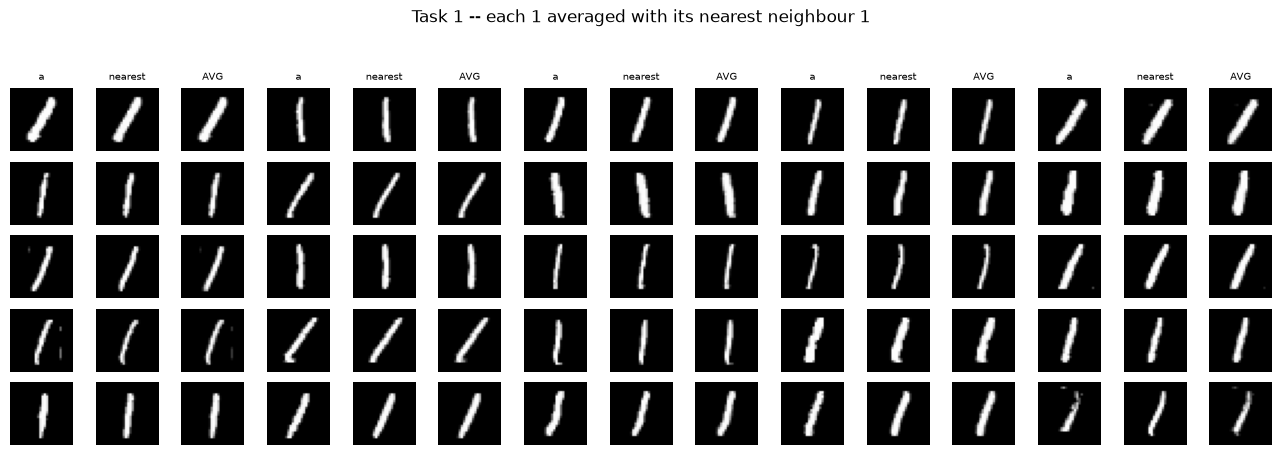

In [8]:
rng = np.random.default_rng(7)
pick = rng.choice(n, 25, replace=False)
a, b = ones[pick], ones[nn_idx[pick]]
avg = (a + b) / 2

dm = np.sqrt(np.maximum((avg**2).sum(1)[:,None] + sq[None,:] - 2*avg@ones.T, 0))
for k, i in enumerate(pick):
    dm[k, i] = 1e9; dm[k, nn_idx[i]] = 1e9
print(f"pair separation ||a-b||                    : mean {nn_d[pick].mean():.2f}")
print(f"dist(average, nearest OTHER real 1)        : mean {dm.min(1).mean():.2f}  max {dm.min(1).max():.2f}")
print(f"baseline (real 1 -> its nearest neighbour) : {THETA:.2f}")

fig, ax = plt.subplots(5, 15, figsize=(13, 4.6))
for r in range(5):
    for g in range(5):
        k = r*5 + g
        for s, (img, lbl) in enumerate([(a[k], "a"), (b[k], "nearest"), (avg[k], "AVG")]):
            A = ax[r, g*3+s]; A.imshow(img.reshape(28,28), cmap="gray", vmin=0, vmax=1); A.axis("off")
            if r == 0: A.set_title(lbl, fontsize=7)
fig.suptitle("Task 1 -- each 1 averaged with its nearest neighbour 1", fontsize=12)
fig.tight_layout(rect=[0,0,1,.94]); plt.show()

## Task 2 — step THETA in a *random* direction

Same distance as Task 1, but in a random direction instead of toward a neighbour. The result is
visibly static-covered and stays ~THETA from every real 1 — a random direction in 784-space is
almost entirely **normal** to a 13-dimensional manifold, so the step buys no progress along it.

This is codimension 771, made visible.

perturbation norm                       : 1.89 spread over 784 dims
  => per-pixel change ~ 0.0674  (17.2 of 255)
dist(perturbed, nearest real 1)         : mean 1.89
pixels driven below 0: 45.3%   above 1: 2.1%

moving 1.89 toward a neighbour -> a real 1
moving 1.89 in a random direction -> still 1.89 from ANY real 1


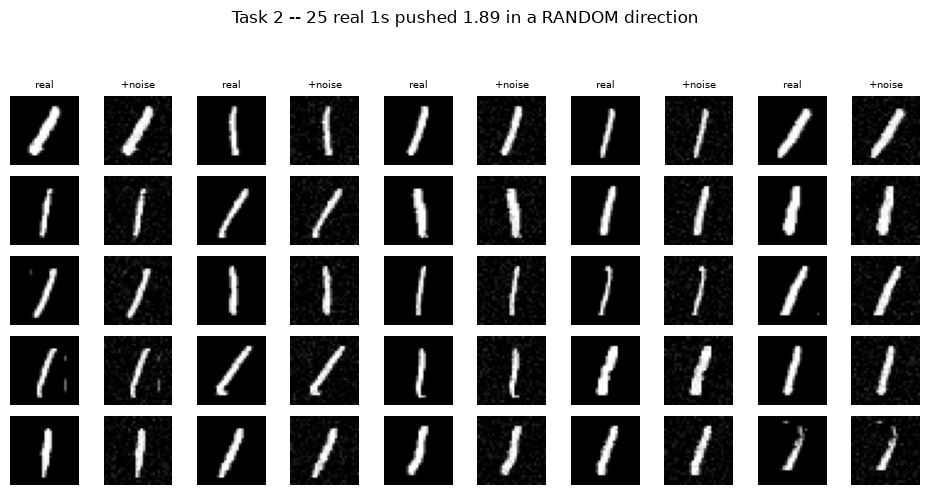

In [9]:
rng = np.random.default_rng(7)
pick2 = rng.choice(n, 25, replace=False)
base = ones[pick2]
u = rng.normal(size=(25, 784)).astype(np.float32)
u /= np.linalg.norm(u, axis=1, keepdims=True)
pert = base + THETA * u

dp = np.sqrt(np.maximum((pert**2).sum(1)[:,None] + sq[None,:] - 2*pert@ones.T, 0))
print(f"perturbation norm                       : {THETA:.2f} spread over 784 dims")
print(f"  => per-pixel change ~ {THETA/np.sqrt(784):.4f}  ({255*THETA/np.sqrt(784):.1f} of 255)")
print(f"dist(perturbed, nearest real 1)         : mean {dp.min(1).mean():.2f}")
print(f"pixels driven below 0: {100*(pert<0).mean():.1f}%   above 1: {100*(pert>1).mean():.1f}%")
print(f"\nmoving {THETA:.2f} toward a neighbour -> a real 1")
print(f"moving {THETA:.2f} in a random direction -> still {dp.min(1).mean():.2f} from ANY real 1")

fig, ax = plt.subplots(5, 10, figsize=(9.5, 5))
for r in range(5):
    for g in range(5):
        k = r*5 + g
        ax[r, g*2].imshow(base[k].reshape(28,28), cmap="gray", vmin=0, vmax=1); ax[r, g*2].axis("off")
        ax[r, g*2+1].imshow(pert[k].reshape(28,28), cmap="gray", vmin=0, vmax=1); ax[r, g*2+1].axis("off")
        if r == 0:
            ax[r, g*2].set_title("real", fontsize=7); ax[r, g*2+1].set_title("+noise", fontsize=7)
fig.suptitle(f"Task 2 -- 25 real 1s pushed {THETA:.2f} in a RANDOM direction", fontsize=12)
fig.tight_layout(rect=[0,0,1,.93]); plt.show()

## Tasks 3 & 4 — sampled vs exhaustive merge tests

**Task 3:** every 1 starts as its own cluster; merge two clusters when 5 randomly drawn
cross-pairs are all within THETA. Run under five different random orders to test the
order-dependence worry.

**Task 4:** same, but check *every* cross-pair and process the closest candidate first.
Requiring all cross-pairs within THETA is exactly **complete linkage** cut at THETA, so
scipy's version is included as a reference.

In [10]:
ei, ej = np.where(np.triu(D <= THETA, 1))
print(f"edges with d<=THETA: {len(ei)}  ({100*len(ei)/(n*(n-1)/2):.4f}% of all pairs)")
print(f"points with >=1 such neighbour: {len(np.union1d(ei, ej))} / {n}\n")

def report(lab, name):
    s = np.bincount(lab); s = s[s > 0]
    diam = max((D[np.ix_(np.where(lab==c)[0], np.where(lab==c)[0])].max()
                for c in np.unique(lab) if (lab==c).sum() > 1), default=0.0)
    print(f"  {name:26s} clusters {len(s):5d} | singletons {(s==1).sum():5d} | largest {s.max():5d} "
          f"| #size>=5 {(s>=5).sum():4d} | MAX DIAMETER {diam:.2f}")

print("TASK 3 -- merge when 5 RANDOM cross-pairs are all <= THETA")
for seed in range(5):
    rng = np.random.default_rng(seed)
    parent = np.arange(n)
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    members = {i: [i] for i in range(n)}
    for e in rng.permutation(len(ei)):
        i, j = ei[e], ej[e]
        ra, rb = find(i), find(j)
        if ra == rb: continue
        A, B = members[ra], members[rb]
        if D[rng.choice(A, 5), rng.choice(B, 5)].max() <= THETA:
            if len(A) < len(B): ra, rb = rb, ra; A, B = B, A
            parent[rb] = ra; A.extend(B); del members[rb]
    report(np.array([find(i) for i in range(n)]), f"seed {seed}")

print("\nTASK 4 -- merge only if EVERY cross-pair <= THETA, closest candidate first")
import heapq
parent = np.arange(n)
def find2(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
members = {i: [i] for i in range(n)}
heap = [(D[ei[e], ej[e]], int(ei[e]), int(ej[e])) for e in range(len(ei))]
heapq.heapify(heap)
merges = 0
while heap:
    d, i, j = heapq.heappop(heap)
    ra, rb = find2(i), find2(j)
    if ra == rb: continue
    A, B = members[ra], members[rb]
    if D[np.ix_(A, B)].max() <= THETA:
        if len(A) < len(B): ra, rb = rb, ra; A, B = B, A
        parent[rb] = ra; A.extend(B); del members[rb]; merges += 1
print(f"  merges accepted: {merges}")
report(np.array([find2(i) for i in range(n)]), "exhaustive")

Z_comp = linkage(squareform(D, checks=False), method="complete")
report(fcluster(Z_comp, THETA, criterion="distance"), "scipy complete linkage")

edges with d<=THETA: 19695  (0.0867% of all pairs)
points with >=1 such neighbour: 4296 / 6742

TASK 3 -- merge when 5 RANDOM cross-pairs are all <= THETA


  seed 0                     clusters  4312 | singletons  3095 | largest    27 | #size>=5  139 | MAX DIAMETER 3.71


  seed 1                     clusters  4304 | singletons  3097 | largest    26 | #size>=5  137 | MAX DIAMETER 3.29


  seed 2                     clusters  4315 | singletons  3103 | largest    26 | #size>=5  153 | MAX DIAMETER 3.06


  seed 3                     clusters  4313 | singletons  3094 | largest    28 | #size>=5  138 | MAX DIAMETER 3.43


  seed 4                     clusters  4314 | singletons  3099 | largest    21 | #size>=5  146 | MAX DIAMETER 3.29

TASK 4 -- merge only if EVERY cross-pair <= THETA, closest candidate first
  merges accepted: 2266
  exhaustive                 clusters  4476 | singletons  3195 | largest    12 | #size>=5  117 | MAX DIAMETER 1.89


  scipy complete linkage     clusters  4514 | singletons  3123 | largest     9 | #size>=5   77 | MAX DIAMETER 1.89


## Task 5 — dense-seeded growth with the centroid test

Seeds are the **densest** points (smallest 10-NN radius), so growth starts at cluster cores
rather than edges. A candidate joins only if

1. the midpoint of (centroid, candidate) stays within THETA of real data — the candidate gets
   50% of the vote, so it can never be drowned out by cluster mass, and
2. the updated centroid also stays within THETA of real data.

In [11]:
dens = np.sort(Dinf, 1)[:, 9]            # 10-NN radius; small = dense
assigned = np.full(n, -1)
clusters = []
HORIZON = 40

for s in np.argsort(dens):
    if assigned[s] != -1: continue
    cid = len(clusters)
    mem = [int(s)]; assigned[s] = cid
    cent = ones[s].copy()
    while True:
        dc = np.sqrt(np.maximum((cent**2).sum() + sq - 2*ones@cent, 0))
        dc[assigned != -1] = 1e9
        cands = np.argsort(dc)[:HORIZON]
        cands = cands[dc[cands] < 1e8]
        took = False
        for x in cands:
            if d_to_data((cent + ones[x]) / 2, [x]) > THETA:      # midpoint stays on manifold
                continue
            newc = (cent * len(mem) + ones[x]) / (len(mem) + 1)
            if d_to_data(newc, [x]) > THETA:                       # centroid stays on manifold
                continue
            mem.append(int(x)); assigned[x] = cid; cent = newc; took = True
            break
        if not took: break
    clusters.append(mem)

sizes = np.array([len(c) for c in clusters])
print(f"clusters {len(clusters)} | singletons {(sizes==1).sum()} | largest {sizes.max()} "
      f"| #size>=5 {(sizes>=5).sum()} | #size>=20 {(sizes>=20).sum()}")
print(f"points in clusters of size>=5: {sizes[sizes>=5].sum()} / {n} ({100*sizes[sizes>=5].sum()/n:.1f}%)")

big = [c for c in clusters if len(c) >= 5]
q  = np.array([d_to_data(ones[c].mean(0), c) for c in big])
dd = np.array([D[np.ix_(c, c)].max() for c in big])
print(f"\nquality test on the {len(big)} clusters of size>=5:")
print(f"  dist(centroid, nearest real 1 outside cluster): mean {q.mean():.2f}  max {q.max():.2f}")
print(f"  fraction passing (<= THETA={THETA:.2f}): {100*(q<=THETA).mean():.1f}%")
print(f"  cluster diameters: mean {dd.mean():.2f}  max {dd.max():.2f}")

clusters 505 | singletons 316 | largest 1797 | #size>=5 47 | #size>=20 19
points in clusters of size>=5: 6084 / 6742 (90.2%)

quality test on the 47 clusters of size>=5:
  dist(centroid, nearest real 1 outside cluster): mean 2.00  max 3.05
  fraction passing (<= THETA=1.89): 51.1%
  cluster diameters: mean 5.66  max 7.25


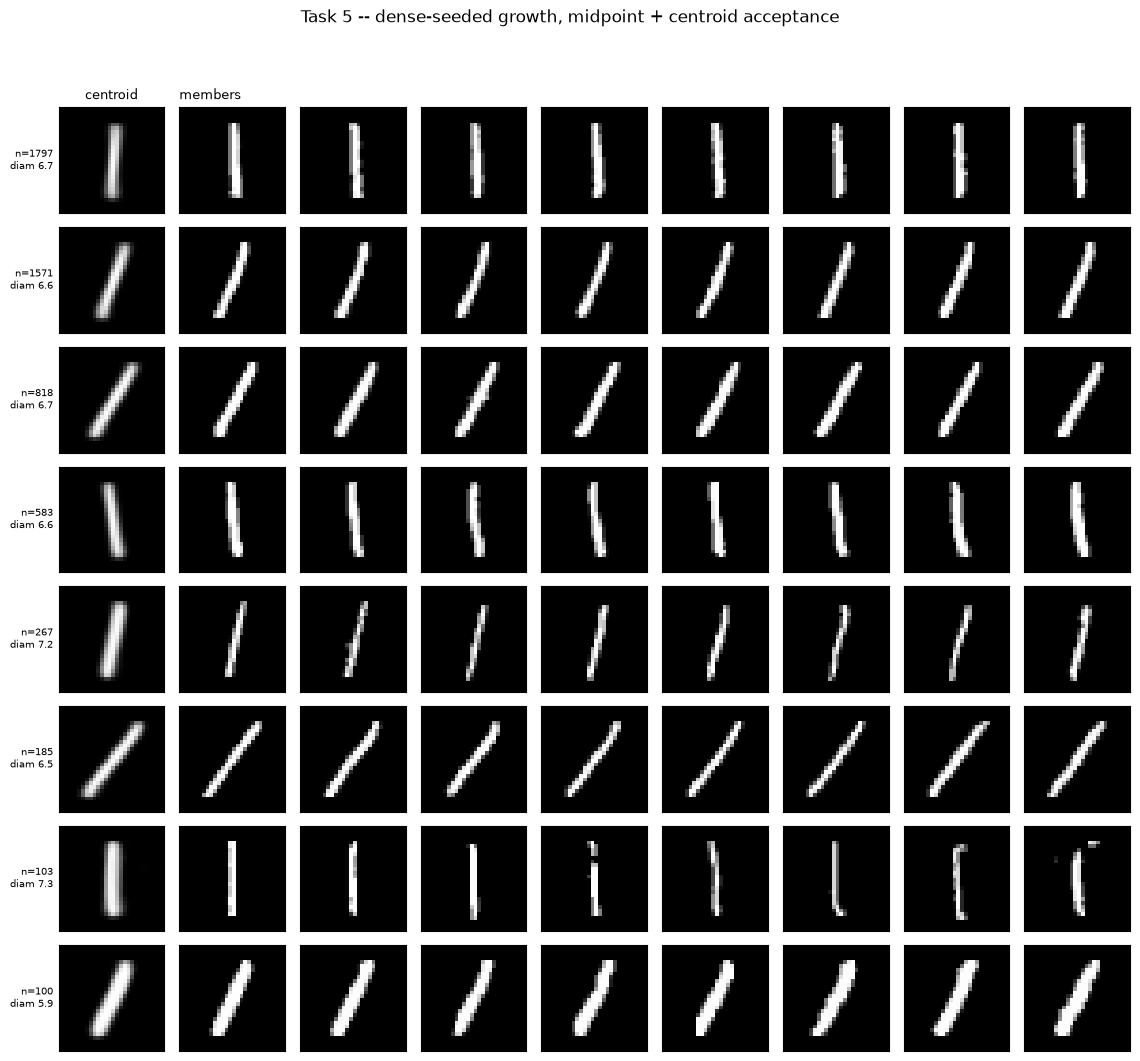

In [12]:
srt = np.argsort([len(c) for c in big])[::-1][:8]
fig, ax = plt.subplots(len(srt), 9, figsize=(11.5, 1.35*len(srt)))
for r, bi in enumerate(srt):
    c = big[bi]
    ax[r, 0].imshow(ones[c].mean(0).reshape(28,28), cmap="gray", vmin=0, vmax=1)
    ax[r, 0].set_ylabel(f"n={len(c)}\ndiam {D[np.ix_(c,c)].max():.1f}",
                        fontsize=7, rotation=0, ha="right", va="center")
    if r == 0: ax[r, 0].set_title("centroid", fontsize=9)
    for j in range(8):
        ax[r, j+1].imshow(ones[c[j % len(c)]].reshape(28,28), cmap="gray", vmin=0, vmax=1)
        if r == 0 and j == 0: ax[r, j+1].set_title("members", fontsize=9, loc="left")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.suptitle("Task 5 -- dense-seeded growth, midpoint + centroid acceptance", fontsize=12)
fig.tight_layout(rect=[0,0,1,.95]); plt.show()

---
# Part II — is THETA real, how far can you average, and is the graph cliquey?

## Is 1.89 a real number or an outlier artefact?

mean/median = 1.09, so the mean sits only 9% above the median. The distribution is
right-skewed (skew 2.6) with a thin tail out to 7.1, but only ~3.5% of 1s sit beyond twice
the median and trimming the top 1% barely moves the mean. **THETA is a real central value**,
not a number dragged up by a handful of isolated digits.

mean 1.887   median 1.728   mean/median = 1.092
std 0.681   skew 2.60
    1%   1.07
    5%   1.21
   10%   1.30
   25%   1.47
   50%   1.73
   75%   2.08
   90%   2.62
   95%   3.12
   99%   4.77
   max   7.10
fraction with nn distance > 2x median : 3.47%
trimmed mean (drop top 1%)            : 1.850


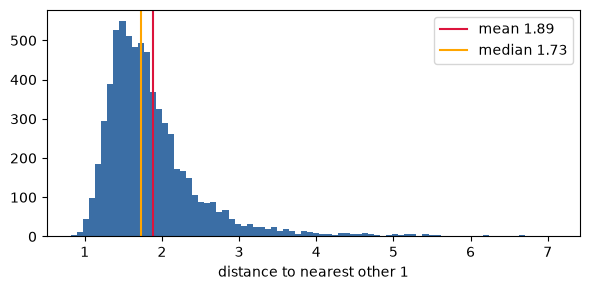

In [13]:
p = np.percentile(nn_d, [1, 5, 10, 25, 50, 75, 90, 95, 99, 100])
print(f"mean {nn_d.mean():.3f}   median {np.median(nn_d):.3f}   mean/median = {nn_d.mean()/np.median(nn_d):.3f}")
print(f"std {nn_d.std():.3f}   skew {((nn_d-nn_d.mean())**3).mean()/nn_d.std()**3:.2f}")
for lbl, v in zip(["1%","5%","10%","25%","50%","75%","90%","95%","99%","max"], p):
    print(f"  {lbl:>4s} {v:6.2f}")
print(f"fraction with nn distance > 2x median : {100*(nn_d > 2*np.median(nn_d)).mean():.2f}%")
print(f"trimmed mean (drop top 1%)            : {nn_d[nn_d <= np.percentile(nn_d,99)].mean():.3f}")

plt.figure(figsize=(6,3))
plt.hist(nn_d, bins=80, color="#3b6ea5")
plt.axvline(nn_d.mean(), color="crimson", label=f"mean {nn_d.mean():.2f}")
plt.axvline(np.median(nn_d), color="orange", label=f"median {np.median(nn_d):.2f}")
plt.xlabel("distance to nearest other 1"); plt.legend(); plt.tight_layout(); plt.show()

## How far can two 1s be and still average to something real?

Fine sweep of separation `s` against the midpoint's distance to the nearest real 1, plus the
fraction of pairs whose midpoint stays within THETA.

A manifold with radius of curvature `R` pulls the chord midpoint off itself by the **sagitta**,
`h ~= s^2 / (8R)`. Fitting that over s in [3, 5.5] gives **R ~= 3.9** — and the fit independently
predicts the midpoint hits THETA at s ~= 4.6, which is where the measured pass-rate collapses.
Two different readings of the same curve agree.

Past s ~ 6 the growth turns **linear**, not quadratic. That is no longer gentle curvature:
it means the chord is cutting across a *fold*, joining parts of the manifold that are close
in pixel space but far apart along it.

         sep  mid->data   ratio  %pairs OK
   1.0-1.5        1.22    0.64      99.4%
   1.5-2.0        1.26    0.67      99.8%
   2.0-2.5        1.34    0.71      99.8%


   2.5-3.0        1.43    0.76      98.4%
   3.0-3.5        1.53    0.81      96.8%
   3.5-4.0        1.67    0.88      84.4%


   4.0-4.5        1.78    0.94      72.4%
   4.5-5.0        1.93    1.02      43.8%
   5.0-5.5        2.12    1.12      12.8%


   5.5-6.0        2.33    1.23       0.6%
   6.0-6.5        2.61    1.38       0.0%
   6.5-7.0        2.88    1.53       0.0%


   7.0-7.5        3.19    1.69       0.0%
   7.5-8.0        3.46    1.84       0.0%
   8.0-8.5        3.75    1.99       0.0%


   8.5-9.0        4.02    2.13       0.0%
   9.0-9.5        4.28    2.27       0.0%
   9.5-10.0       4.54    2.40       0.0%

sagitta fit h = s^2/(8R) over s in [3,5.5]  ->  R = 3.92
fit predicts midpoint reaches THETA at s = 4.59
class diameter = 13.9, so the manifold wraps appreciably over its own extent


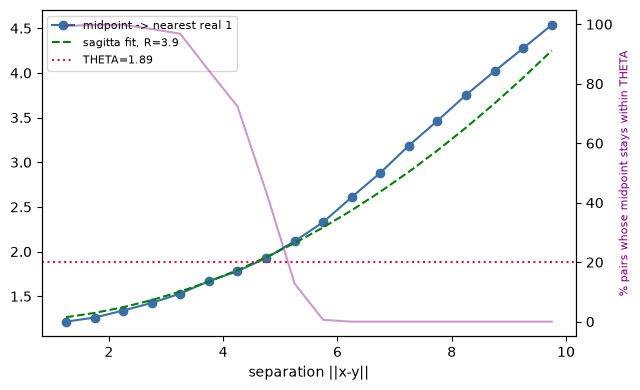

In [14]:
iu = np.triu_indices(n, 1)
dv = D[iu]
rng = np.random.default_rng(0)
xs, ys, frac = [], [], []
print(f"  {'sep':>10s} {'mid->data':>10s} {'ratio':>7s} {'%pairs OK':>10s}")
for lo in np.arange(0.5, 10.0, 0.5):
    idx = np.where((dv >= lo) & (dv < lo + 0.5))[0]
    if len(idx) < 50: continue
    pk = rng.choice(idx, min(500, len(idx)), replace=False)
    a, b = iu[0][pk], iu[1][pk]
    mid = (ones[a] + ones[b]) / 2
    dm = np.sqrt(np.maximum((mid**2).sum(1)[:,None] + sq[None,:] - 2*mid@ones.T, 0))
    dm[np.arange(len(pk)), a] = 1e9; dm[np.arange(len(pk)), b] = 1e9
    mn = dm.min(1)
    xs.append(lo + .25); ys.append(mn.mean()); frac.append((mn <= THETA).mean())
    print(f"  {lo:4.1f}-{lo+0.5:<4.1f} {mn.mean():10.2f} {mn.mean()/THETA:7.2f} {100*(mn<=THETA).mean():9.1f}%")

xs, ys, frac = np.array(xs), np.array(ys), np.array(frac)
msk = (xs >= 3) & (xs <= 5.5)
slope = np.linalg.lstsq(np.vstack([xs[msk]**2]).T, ys[msk] - ys[0], rcond=None)[0][0]
R = 1 / (8 * slope)
print(f"\nsagitta fit h = s^2/(8R) over s in [3,5.5]  ->  R = {R:.2f}")
print(f"fit predicts midpoint reaches THETA at s = {np.sqrt(8*R*(THETA-ys[0])):.2f}")
print(f"class diameter = {D.max():.1f}, so the manifold wraps appreciably over its own extent")

fig, ax = plt.subplots(figsize=(6.5,4))
ax.plot(xs, ys, "o-", color="#3b6ea5", label="midpoint -> nearest real 1")
ax.plot(xs, ys[0] + xs**2/(8*R), "--", color="green", label=f"sagitta fit, R={R:.1f}")
ax.axhline(THETA, color="crimson", ls=":", label=f"THETA={THETA:.2f}")
ax.set_xlabel("separation ||x-y||"); ax.legend(fontsize=8)
a2 = ax.twinx(); a2.plot(xs, 100*frac, color="purple", alpha=.4)
a2.set_ylabel("% pairs whose midpoint stays within THETA", fontsize=8, color="purple")
plt.tight_layout(); plt.show()

## The THETA-ball neighbourhood graph

Connect two 1s when they are within THETA. How cliquey is the result?

The degree distribution is **wildly heterogeneous** — median 2, 90th percentile 18, max 65,
and 36% of 1s have no neighbour at all within THETA. That alone rules out "evenly spaced".

Jaccard overlap of the two endpoints' neighbourhoods averages 0.32, with only 1.5% of edges
below 0.10. Neighbours genuinely share neighbours; this is not a chain.

THETA = 1.89;  edges 19695;  mean degree 5.84;  median degree 2
isolated 1s (degree 0): 2446 (36.3%)
degree percentiles: 25%:0  50%:2  75%:8  90%:18  99%:36
max degree 65



Jaccard overlap over all 19695 edges:
  mean 0.318  median 0.294  [25% 0.216, 75% 0.393]
  edges with overlap < 0.10 (chain-like) : 1.5%
  edges with overlap > 0.50 (clique-like): 8.8%

local clustering coefficient: mean 0.435  median 0.400


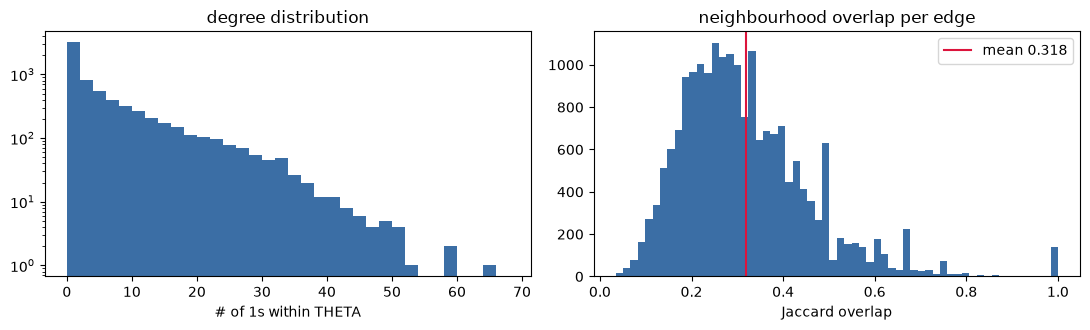

In [15]:
Adj = (D <= THETA) & (~np.eye(n, dtype=bool))
deg = Adj.sum(1)
print(f"THETA = {THETA:.2f};  edges {Adj.sum()//2};  mean degree {deg.mean():.2f};  median degree {np.median(deg):.0f}")
print(f"isolated 1s (degree 0): {(deg==0).sum()} ({100*(deg==0).mean():.1f}%)")
print("degree percentiles: " + "  ".join(f"{q}%:{int(np.percentile(deg,q))}" for q in [25,50,75,90,99]))
print(f"max degree {deg.max()}")

ei, ej = np.where(np.triu(Adj, 1))
Aself = Adj | np.eye(n, dtype=bool)
inter = np.empty(len(ei), np.int32); union = np.empty(len(ei), np.int32)
for s in range(0, len(ei), 50000):
    Ai, Aj = Aself[ei[s:s+50000]], Aself[ej[s:s+50000]]
    inter[s:s+50000] = (Ai & Aj).sum(1); union[s:s+50000] = (Ai | Aj).sum(1)
jac = inter / union
print(f"\nJaccard overlap over all {len(ei)} edges:")
print(f"  mean {jac.mean():.3f}  median {np.median(jac):.3f}  "
      f"[25% {np.percentile(jac,25):.3f}, 75% {np.percentile(jac,75):.3f}]")
print(f"  edges with overlap < 0.10 (chain-like) : {100*(jac<0.10).mean():.1f}%")
print(f"  edges with overlap > 0.50 (clique-like): {100*(jac>0.50).mean():.1f}%")

cc_local = np.array([Adj[np.ix_(np.where(Adj[i])[0], np.where(Adj[i])[0])].sum() / (deg[i]*(deg[i]-1))
                     for i in np.where(deg >= 2)[0]])
print(f"\nlocal clustering coefficient: mean {cc_local.mean():.3f}  median {np.median(cc_local):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(deg, bins=np.arange(0,70,2), color="#3b6ea5"); ax[0].set_yscale("log")
ax[0].set_xlabel("# of 1s within THETA"); ax[0].set_title("degree distribution")
ax[1].hist(jac, bins=60, color="#3b6ea5")
ax[1].axvline(jac.mean(), color="crimson", label=f"mean {jac.mean():.3f}")
ax[1].set_xlabel("Jaccard overlap"); ax[1].set_title("neighbourhood overlap per edge"); ax[1].legend()
plt.tight_layout(); plt.show()

## Calibration — what dimension would this graph imply?

Clustering coefficient and Jaccard both fall with dimension, so simulate uniform points on a
**flat d-torus** (no curvature, no density variation, no boundary), tune the radius to the same
mean degree, and read off which d reproduces the measured values.

The answer comes out **3–5**, while TwoNN on the same points says **11.1**. Those disagree by a
lot, and the disagreement is the point: the graph is *far too cliquey* for a uniformly sampled
11-dimensional manifold. Since uniformity is the assumption the torus makes and the manifold
dimension is not in dispute, the excess must be **density variation** — dense cores joined by
sparse bridges. That is the cluster structure, showing up as a measured discrepancy rather
than as a gap.

real 1s:  clustering coeff 0.435   Jaccard 0.318   mean degree 5.84

uniform points on a flat d-torus, radius tuned to the same mean degree:
    d  clust coeff   Jaccard


    2        0.589     0.556


    3        0.473     0.454


    4        0.380     0.388


    5        0.310     0.336


...

   10        0.127     0.222


   12        0.094     0.204


   15        0.068     0.191


   20        0.044     0.178


   30        0.030     0.171

clustering coeff 0.435 -> implied dim ~3.4
Jaccard          0.318 -> implied dim ~5.5
TwoNN on the same points says 11.2

-> the gap is density heterogeneity, i.e. real cluster structure inside one connected manifold


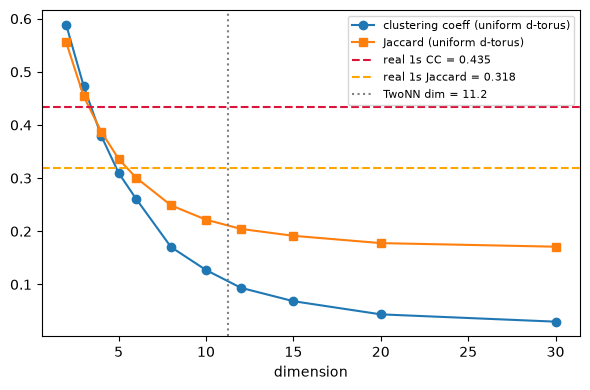

In [16]:
TARGET_DEG = deg.mean()
print(f"real 1s:  clustering coeff {cc_local.mean():.3f}   Jaccard {jac.mean():.3f}   mean degree {TARGET_DEG:.2f}\n")
print("uniform points on a flat d-torus, radius tuned to the same mean degree:")
print(f"  {'d':>3s} {'clust coeff':>12s} {'Jaccard':>9s}")
rs = np.random.default_rng(0); N = 3000
sim_d, sim_cc, sim_jc = [], [], []
for d in [2,3,4,5,6,8,10,12,15,20,30]:
    P = rs.random((N,d)).astype(np.float32)
    d2 = np.zeros((N,N), np.float32)
    for k in range(d):
        df = np.abs(P[:,k][:,None] - P[:,k][None,:]); df = np.minimum(df, 1-df); d2 += df*df
    Dt = np.sqrt(d2); np.fill_diagonal(Dt, 1e9)
    need = int(N*TARGET_DEG/2)
    r = np.partition(Dt[np.triu_indices(N,1)], need)[need]
    At = Dt <= r
    dg = At.sum(1)
    e1, e2 = np.where(np.triu(At,1)); Asf = At | np.eye(N, dtype=bool)
    jj = ((Asf[e1]&Asf[e2]).sum(1) / (Asf[e1]|Asf[e2]).sum(1)).mean()
    cc = np.mean([At[np.ix_(np.where(At[i])[0], np.where(At[i])[0])].sum()/(dg[i]*(dg[i]-1))
                  for i in np.where(dg>=2)[0]])
    sim_d.append(d); sim_cc.append(cc); sim_jc.append(jj)
    print(f"  {d:3d} {cc:12.3f} {jj:9.3f}")

sim_d, sim_cc, sim_jc = map(np.array, (sim_d, sim_cc, sim_jc))
print(f"\nclustering coeff {cc_local.mean():.3f} -> implied dim ~{np.interp(-cc_local.mean(), -sim_cc, sim_d):.1f}")
print(f"Jaccard          {jac.mean():.3f} -> implied dim ~{np.interp(-jac.mean(), -sim_jc, sim_d):.1f}")
print(f"TwoNN on the same points says {twonn(ones):.1f}")
print("\n-> the gap is density heterogeneity, i.e. real cluster structure inside one connected manifold")

plt.figure(figsize=(6,4))
plt.plot(sim_d, sim_cc, "o-", label="clustering coeff (uniform d-torus)")
plt.plot(sim_d, sim_jc, "s-", label="Jaccard (uniform d-torus)")
plt.axhline(cc_local.mean(), color="crimson", ls="--", label=f"real 1s CC = {cc_local.mean():.3f}")
plt.axhline(jac.mean(), color="orange", ls="--", label=f"real 1s Jaccard = {jac.mean():.3f}")
plt.axvline(twonn(ones), color="gray", ls=":", label=f"TwoNN dim = {twonn(ones):.1f}")
plt.xlabel("dimension"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part II findings

- **THETA = 1.89 is trustworthy.** Median 1.73, mean/median 1.09, trimmed mean 1.85.
  Right-skewed with a thin tail, but not outlier-driven.
- **Averaging works out to a separation of ~4.6**, where the pass rate falls off a cliff
  (99% OK below 3, 72% at 4.0-4.5, 44% at 4.5-5.0, ~0% past 6).
- **Radius of curvature R ~= 3.9**, fitted from the sagitta and cross-checked by the crossover.
  Past s ~ 6 the deviation grows linearly, which means folding rather than smooth curvature.
- **The neighbourhood graph is heterogeneous and cliquey**: 36% isolated, max degree 65,
  Jaccard 0.32, clustering coefficient 0.435 — versus ~0.13 for a uniform 11-dimensional
  sample at the same degree. Dense cores connected by sparse bridges, all inside one
  connected component.
- Caveat that stands over all of it: this is the geometry of **6742 sampled 1s**, not of the
  space of all possible 1s. Sample support vs population support is exactly the gap that
  set estimation exists to close.

## What the numbers said

- **THETA = 1.89** is the natural scale: mean distance from a 1 to its nearest 1.
- **Reach ~= 4.5.** Averaging two 1s is safe below that separation, unsafe above it. This
  predicts mean quality better than cluster size does.
- **The 1s are one connected piece.** No persistent gap in the H0 barcode, and every 1 has a
  *non*-1 within the radius needed to connect the class to itself.
- **Task 3 leaks:** sampling 5 cross-pairs let clusters reach diameter 3.1-3.7, roughly 2x THETA,
  and the figure varied run to run — the order/luck dependence was real.
- **Task 4 is exact but brittle:** diameter capped at THETA by construction, but the largest
  cluster is ~12 points and half the data is left as singletons.
- **Task 5 is the useful one:** 90% of the 1s land in 47 clusters, the centroids are clean
  readable 1s, and they sort themselves by slant and stroke thickness. Only ~51% pass the
  strict centroid test though, and diameters run to ~7 — past the reach. The 50% vote fixes
  *dilution* but not *drift*: each step is locally valid, and a chain of locally valid steps
  still walks a long way along a curved manifold.

---
# Part III — what counts as a valid 1, where the gaps are, and how to cross them

## "Close to real data" is not a validity test

The obvious criterion for a constructed image — `distance to nearest real 1 <= THETA` — is
close to useless. Four populations, two of them known-good and two known-bad:

- **A** real 1s from the **test set** (never seen in any of this) — should pass
- **B** midpoints of *close* pairs (Part I showed these are valid) — should pass
- **C** real 1s pushed THETA in a *random* direction (Part I showed these are static) — should fail
- **D** midpoints of *far* pairs (corner-cutting) — should fail

The distance test admits the static at 53% while rejecting genuine unseen 1s at 32%. What
actually separates them are **structural** constraints — non-negativity, sparsity, smoothness —
which cost nothing and are defined on all 784 coordinates. But those are blind to
corner-cutting, which only the distance test catches. **Neither kind of test works alone.**

In [17]:
Xte_all, yte_all = mnist.load("test")
Xte_all = Xte_all.reshape(len(Xte_all), -1).astype(np.float32) / 255.0
rng = np.random.default_rng(0); M = 300

iu = np.triu_indices(n, 1); dv = D[iu]
held = Xte_all[yte_all == 1][:M]
pk = rng.choice(np.where((dv >= 1) & (dv < 2.5))[0], M, replace=False)
near = (ones[iu[0][pk]] + ones[iu[1][pk]]) / 2
bi = rng.choice(n, M, replace=False)
u = rng.normal(size=(M, 784)).astype(np.float32); u /= np.linalg.norm(u, axis=1, keepdims=True)
noisy = ones[bi] + THETA * u
pk2 = rng.choice(np.where((dv >= 6) & (dv < 8))[0], M, replace=False)
farm = (ones[iu[0][pk2]] + ones[iu[1][pk2]]) / 2

def V_dist(Q):
    return np.sqrt(np.maximum((Q**2).sum(1)[:,None] + sq[None,:] - 2*Q@ones.T, 0)).min(1)
def V_sparse(Q): return (np.abs(Q) < 0.05).mean(1)
def V_neg(Q):    return np.maximum(-Q, 0).sum(1)
def V_tv(Q):
    I = Q.reshape(-1, 28, 28)
    return (np.abs(np.diff(I,axis=1)).sum((1,2)) + np.abs(np.diff(I,axis=2)).sum((1,2))) / Q.sum(1)

pops = [("A real unseen", held), ("B close midpt", near),
        ("C random step", noisy), ("D far midpt", farm)]
print(f"{'':28s}" + "".join(f"{p[0]:>16s}" for p in pops))
for tn, fn in [("dist to nearest real 1", V_dist), ("frac near-zero pixels", V_sparse),
               ("negative ink mass", V_neg), ("total variation / ink", V_tv)]:
    print(f"  {tn:26s}" + "".join(f"{fn(P).mean():16.3f}" for _, P in pops))

print(f"\npass rates for 'dist to nearest real 1 <= THETA={THETA:.2f}':")
for nm, P in pops:
    print(f"  {nm:18s} {100*(V_dist(P) <= THETA).mean():5.1f}%")
print("\n-> admits static at 53%, rejects real unseen 1s at 32%. Not a validity test.")

                               A real unseen   B close midpt   C random step     D far midpt
  dist to nearest real 1               1.872           1.090           1.887           3.074
  frac near-zero pixels                0.904           0.901           0.487           0.853
  negative ink mass                    0.000           0.000          18.903           0.000
  total variation / ink                1.041           1.029           2.989           0.912

pass rates for 'dist to nearest real 1 <= THETA=1.89':
  A real unseen       68.3%
  B close midpt      100.0%
  C random step       52.7%
  D far midpt          0.0%

-> admits static at 53%, rejects real unseen 1s at 32%. Not a validity test.


## The gaps are the ornate 1s

Ranking the 1s by distance to their nearest neighbour and rendering the extremes: the isolates
are almost all **serifed** — top flag plus base bar, the European handwritten 1 — while the hubs
are all plain thin strokes. The sparse satellite population has a recognisable identity.

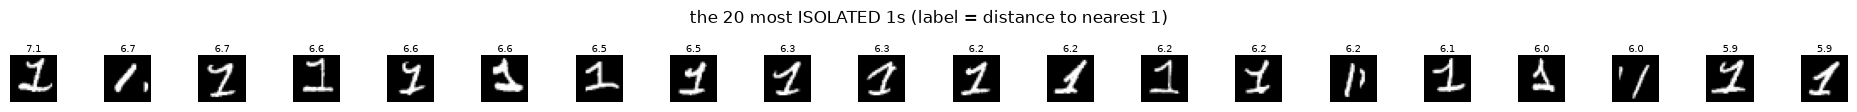

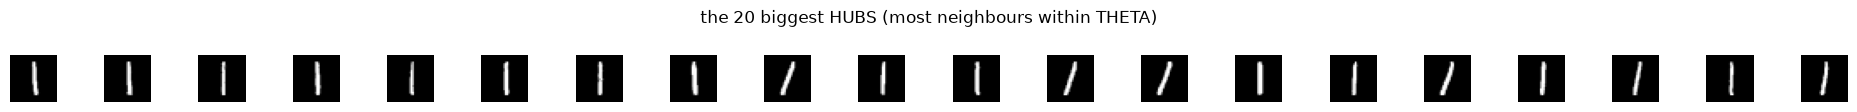

isolates: 2446 (36.3%)
  an isolate's nearest 1 is ALSO an isolate: 53.2%  (chance 36.3%, enrichment 1.47x)
  isolates whose nearest 1 is >4 away: 138, >6 away: 17


In [18]:
lonely = np.argsort(nn_d)[::-1][:20]
hubs   = np.argsort(Adj.sum(1))[::-1][:20] if 'Adj' in dir() else np.argsort(
             ((D <= THETA) & (~np.eye(n, dtype=bool))).sum(1))[::-1][:20]
grid(ones[lonely], [f"{nn_d[i]:.1f}" for i in lonely], cols=20, scale=0.95,
     suptitle="the 20 most ISOLATED 1s (label = distance to nearest 1)")
grid(ones[hubs], None, cols=20, scale=0.95,
     suptitle="the 20 biggest HUBS (most neighbours within THETA)")

iso = np.where(((D <= THETA) & (~np.eye(n, dtype=bool))).sum(1) == 0)[0]
is_iso = np.zeros(n, bool); is_iso[iso] = True
hit = is_iso[Dinf[iso].argmin(1)]
print(f"isolates: {len(iso)} ({100*len(iso)/n:.1f}%)")
print(f"  an isolate's nearest 1 is ALSO an isolate: {100*hit.mean():.1f}%  "
      f"(chance {100*len(iso)/n:.1f}%, enrichment {hit.mean()/(len(iso)/n):.2f}x)")
print(f"  isolates whose nearest 1 is >4 away: {(Dinf[iso].min(1) > 4).sum()}, "
      f">6 away: {(Dinf[iso].min(1) > 6).sum()}")

## Straight lines across the widest gaps are empty the whole way

For the seven most isolated 1s, walk the straight line to their nearest neighbour and measure
every frame's distance to the nearest real 1. Not one frame anywhere on any path comes within
2.3x THETA. These corridors are genuinely empty, not merely thin in the middle.

Watch *what the interpolation does*: the base bar doesn't shorten, it **fades**. Averaging pixel
intensities is a cross-fade, not a morph — which is the mechanical reason every one of these
fails, and the reason curvature showed up as it did in Part II.

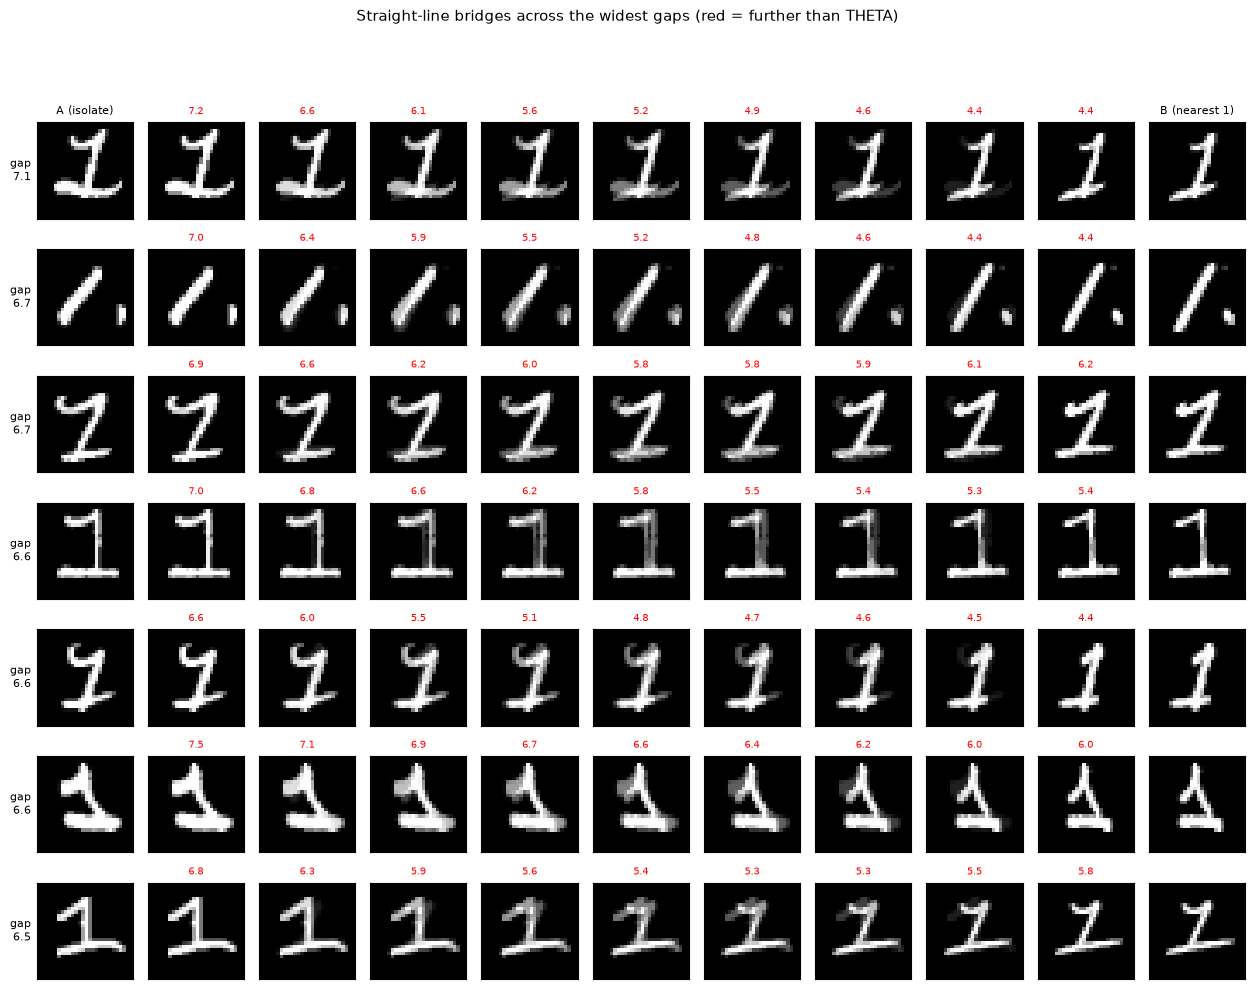

In [19]:
cand = np.argsort(nn_d)[::-1][:7]
K = 9; ts = np.linspace(0, 1, K)
fig, ax = plt.subplots(len(cand), K+2, figsize=(1.15*(K+2), 1.45*len(cand)))
for r, a in enumerate(cand):
    b = Dinf[a].argmin()
    P = np.outer(1-ts, ones[a]) + np.outer(ts, ones[b])
    dm = np.sqrt(np.maximum((P**2).sum(1)[:,None] + sq[None,:] - 2*P@ones.T, 0))
    dm[:, a] = 1e9; dm[:, b] = 1e9
    v = dm.min(1)
    ax[r,0].imshow(ones[a].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    ax[r,0].set_ylabel(f"gap\n{D[a,b]:.1f}", fontsize=8, rotation=0, ha="right", va="center")
    if r == 0: ax[r,0].set_title("A (isolate)", fontsize=8)
    for k in range(K):
        ax[r,k+1].imshow(P[k].reshape(28,28), cmap="gray", vmin=0, vmax=1)
        ax[r,k+1].set_title(f"{v[k]:.1f}", fontsize=7, color="green" if v[k] <= THETA else "red")
    ax[r,K+1].imshow(ones[b].reshape(28,28), cmap="gray", vmin=0, vmax=1)
    if r == 0: ax[r,K+1].set_title("B (nearest 1)", fontsize=8)
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
fig.suptitle("Straight-line bridges across the widest gaps (red = further than THETA)", fontsize=11)
fig.tight_layout(rect=[0,0,1,0.93]); plt.show()

## Move the ink instead of averaging it — optimal transport

Treat each image as a pile of sand. Match A's ink to B's ink so total travel is minimised
(Hungarian algorithm), then slide every grain along a straight line. This is **displacement
interpolation**, the Wasserstein geodesic. Implemented in `morph.py`, no external OT library.

Strokes now stay **solid and move** instead of going translucent — the base bar retracts rather
than fading. But the distance to real data barely improves, and the same holds when the paths
are measured in the transport metric instead of L2. **The gap is not an artefact of the ruler.**

widest gap in the dataset: 7.10   (THETA = 1.89)
  LINEAR    L2:  7.2  6.6  6.1  5.6  5.2  4.9  4.6  4.4  4.4   worst 7.23 = 3.8x
  TRANSPORT L2:  6.6  6.2  5.9  5.6  5.3  5.0  4.7  4.4  4.2   worst 6.60 = 3.5x


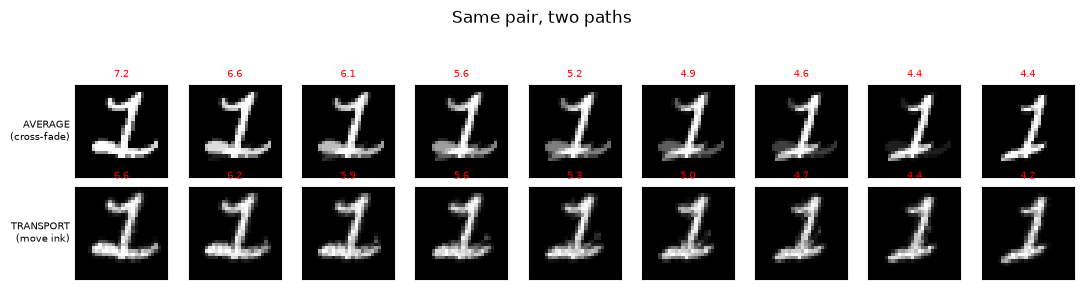

In [20]:
import morph

a = np.argsort(nn_d)[::-1][0]; b = Dinf[a].argmin()
A_img = ones[a].reshape(28,28).astype(np.float64)
B_img = ones[b].reshape(28,28).astype(np.float64)

def l2_to_data(F, ban):
    Q = F.reshape(len(F), -1).astype(np.float32)
    dm = np.sqrt(np.maximum((Q**2).sum(1)[:,None] + sq[None,:] - 2*Q@ones.T, 0))
    dm[:, ban] = 1e9
    return dm.min(1)

FL = morph.linear_path(A_img, B_img, 9)
FO = morph.ot_path(A_img, B_img, 9, N=800)
dl, do = l2_to_data(FL, [a,b]), l2_to_data(FO, [a,b])
print(f"widest gap in the dataset: {D[a,b]:.2f}   (THETA = {THETA:.2f})")
print("  LINEAR    L2: " + " ".join(f"{x:4.1f}" for x in dl) + f"   worst {dl.max():.2f} = {dl.max()/THETA:.1f}x")
print("  TRANSPORT L2: " + " ".join(f"{x:4.1f}" for x in do) + f"   worst {do.max():.2f} = {do.max()/THETA:.1f}x")

fig, ax = plt.subplots(2, 9, figsize=(11, 2.9))
for k in range(9):
    ax[0,k].imshow(FL[k], cmap="gray", vmin=0, vmax=1)
    ax[0,k].set_title(f"{dl[k]:.1f}", fontsize=7, color="green" if dl[k] <= THETA else "red")
    ax[1,k].imshow(FO[k], cmap="gray", vmin=0, vmax=1)
    ax[1,k].set_title(f"{do[k]:.1f}", fontsize=7, color="green" if do[k] <= THETA else "red")
ax[0,0].set_ylabel("AVERAGE\n(cross-fade)", fontsize=7, rotation=0, ha="right", va="center")
ax[1,0].set_ylabel("TRANSPORT\n(move ink)", fontsize=7, rotation=0, ha="right", va="center")
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
fig.suptitle("Same pair, two paths", fontsize=12); fig.tight_layout(rect=[0,0,1,0.9]); plt.show()

In [21]:
# the control that matters: how much of the "improvement" is just the renderer blurring things?
print("round-trip error of the particle representation (image -> particles -> image):")
for N in [200, 400, 800, 2000]:
    errs = [np.linalg.norm(morph.splat(morph.to_particles(ones[i].reshape(28,28).astype(np.float64), N, 1),
                                       ones[i].sum()/N) - ones[i].reshape(28,28))
            for i in np.random.default_rng(0).choice(n, 20, replace=False)]
    print(f"  N={N:5d}: mean ||reconstruction - original|| = {np.mean(errs):.2f}")
print(f"\n(for scale: THETA = {THETA:.2f}.  Most of the LINEAR->TRANSPORT gain above is this,")
print(" not the path being better. Use N >= 800.)")

round-trip error of the particle representation (image -> particles -> image):
  N=  200: mean ||reconstruction - original|| = 1.85
  N=  400: mean ||reconstruction - original|| = 1.40
  N=  800: mean ||reconstruction - original|| = 1.16
  N= 2000: mean ||reconstruction - original|| = 1.05

(for scale: THETA = 1.89.  Most of the LINEAR->TRANSPORT gain above is this,
 not the path being better. Use N >= 800.)


## Part III findings

- **`distance to real data` is not a validity test.** It admits noise at 53% and rejects real
  unseen 1s at 32%. Structural constraints (non-negativity, sparsity, total variation) catch
  the noise it misses; it catches the corner-cutting they miss. You need both, and neither is
  a guarantee — certifying a *constructed* image is impossible from the sample alone.
- **The isolates are the ornate 1s** — serif plus base bar. 36% of 1s have no neighbour within
  THETA, they pair with each other 1.47x above chance, and the extreme ones sit 6-7 away.
- **The widest corridors are empty end to end**, never closer than 2.3x THETA to real data.
- **Averaging is a cross-fade, not a morph.** That single fact explains why straight lines fail,
  and why the failure looks like curvature.
- **Optimal transport morphs correctly** — ink stays solid and moves — but the gap survives,
  in L2 *and* in the transport metric. The isolation of the ornate 1s is real geometry, not a
  bad choice of ruler.
- Open: the MST framing was wrong. Mapping the manifold wants *all* locally-flat edges kept and
  the non-flat ones tagged for refinement, not a minimum spanning subset. See surface
  reconstruction from point clouds (Crust / Cocone / alpha complexes), whose guarantees are
  stated in terms of sampling density against reach -- the same quantity Part II measured.

---
# Part IV — moving the whole 1 in sync

Optimal transport moves each grain of ink *independently*, which is why its frames speckle.
The alternative is a **warp field**: one smooth displacement field `u(x,y)` applied to the whole
image, so neighbouring pixels travel together and the image cannot tear. Sub-pixel motion is
handled by bilinear resampling — the same operation that put the grey levels into MNIST.

`morph.demons` finds `u` by gradient descent on `||warp(A,u) - B||`, Gaussian-smoothing `u` after
every step. That smoothing *is* the "move in sync" constraint. Coarse-to-fine (large sigma first)
lets it find displacements of several pixels.

In [22]:
import morph

# sanity check: does the warp field actually take A to B?
for i, j in [(0, 7), (3, 11), (5, 20)]:
    A_ = ones[i].reshape(28,28).astype(np.float64)
    B_ = ones[j].reshape(28,28).astype(np.float64)
    u = morph.demons(A_, B_)
    print(f"pair {i:2d},{j:2d}:  ||A-B|| = {np.linalg.norm(A_-B_):5.2f}  ->  "
          f"||warp(A,u)-B|| = {np.linalg.norm(morph.warp(A_,u)-B_):5.2f}   "
          f"max displacement {np.abs(u).max():.1f}px")

pair  0, 7:  ||A-B|| =  3.17  ->  ||warp(A,u)-B|| =  0.74   max displacement 1.1px
pair  3,11:  ||A-B|| =  7.83  ->  ||warp(A,u)-B|| =  1.50   max displacement 5.3px


pair  5,20:  ||A-B|| =  7.91  ->  ||warp(A,u)-B|| =  3.12   max displacement 4.6px


## Four paths across the same gaps

`AVERAGE` blends intensities. `TRANSPORT` moves ink grains independently. `WARP` pushes A along
one smooth field. `MORPH` warps both ends to the shared intermediate shape and blends those.

Watch the base bar. Under `AVERAGE` it **fades**; under `WARP` it **retracts** — the intermediate
frames are 1s with progressively shorter serifs, which is the path you would draw by hand.

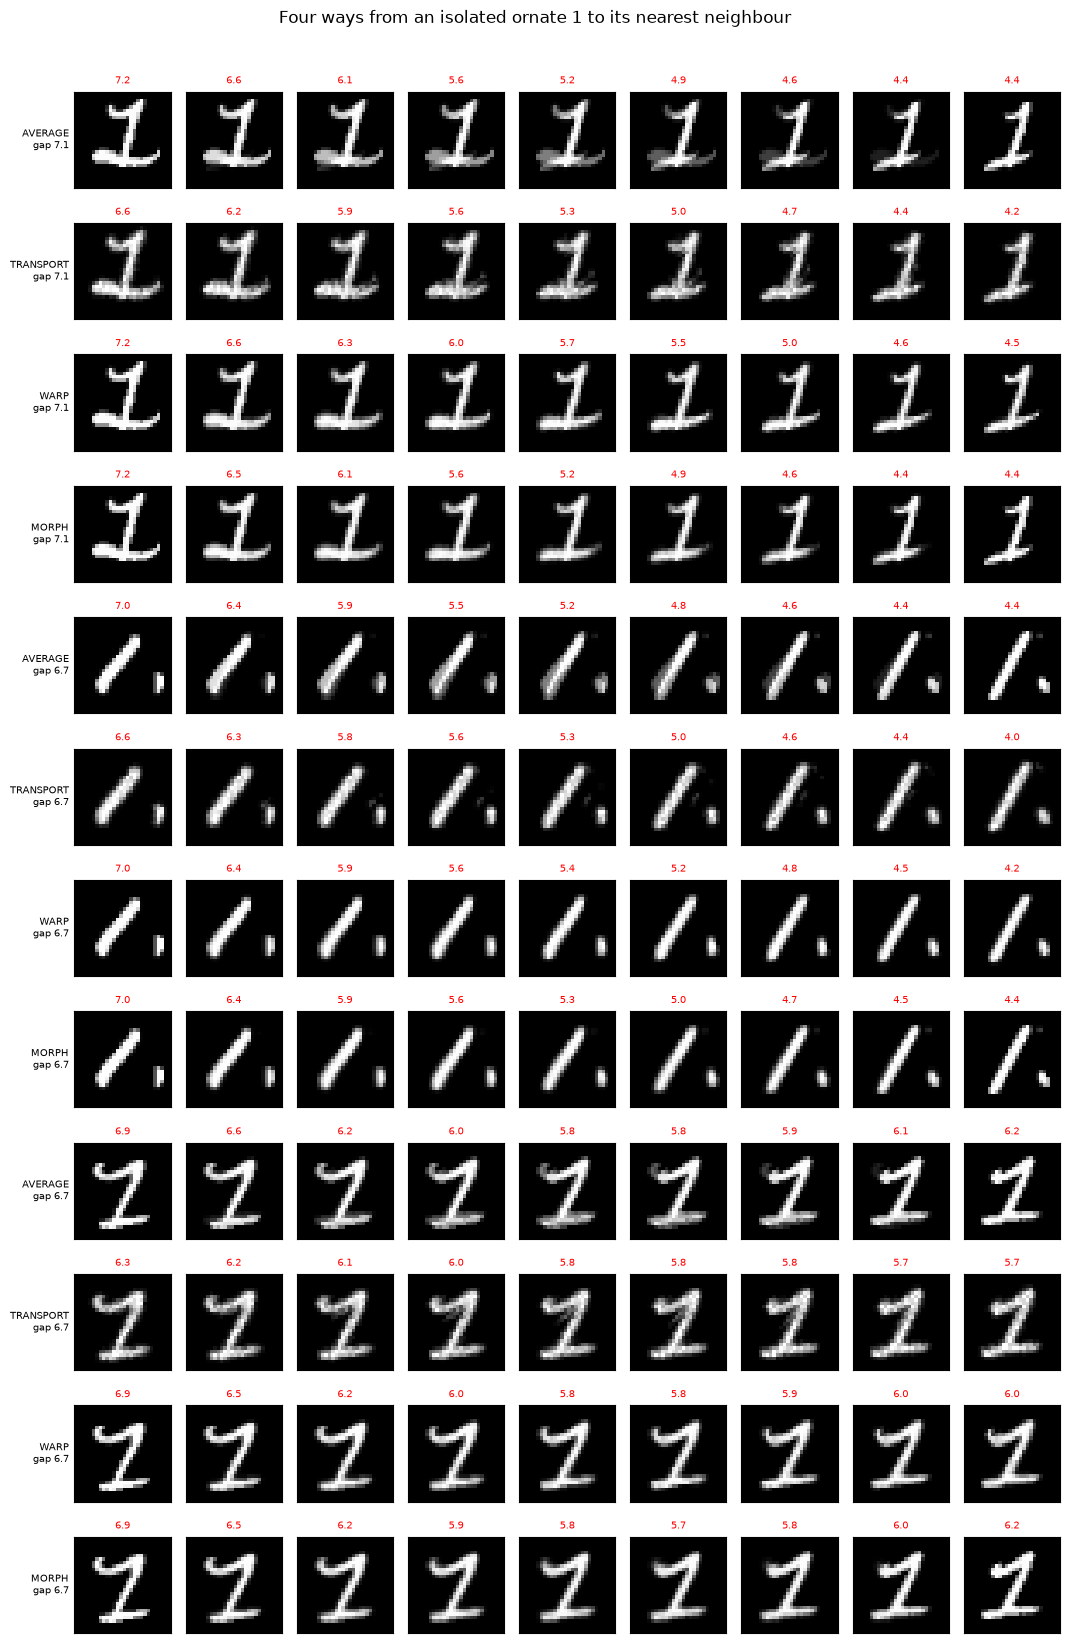

In [23]:
def l2_to_data(F, ban):
    Q = F.reshape(len(F), -1).astype(np.float32)
    dm = np.sqrt(np.maximum((Q**2).sum(1)[:,None] + sq[None,:] - 2*Q@ones.T, 0))
    dm[:, ban] = 1e9
    return dm.min(1)

K = 9
methods = [("AVERAGE",   morph.linear_path),
           ("TRANSPORT", lambda A,B,K: morph.ot_path(A,B,K,N=800)),
           ("WARP",      morph.warp_path),
           ("MORPH",     morph.morph_path)]
cand = np.argsort(nn_d)[::-1][:3]
fig, ax = plt.subplots(len(cand)*len(methods), K, figsize=(1.2*K, 1.4*len(cand)*len(methods)))
row = 0
for a in cand:
    b = Dinf[a].argmin()
    A_ = ones[a].reshape(28,28).astype(np.float64)
    B_ = ones[b].reshape(28,28).astype(np.float64)
    for name, fn in methods:
        F = fn(A_, B_, K); d = l2_to_data(F, [a,b])
        for k in range(K):
            ax[row,k].imshow(F[k], cmap="gray", vmin=0, vmax=1)
            ax[row,k].set_title(f"{d[k]:.1f}", fontsize=7, color="green" if d[k] <= THETA else "red")
        ax[row,0].set_ylabel(f"{name}\ngap {D[a,b]:.1f}", fontsize=7, rotation=0, ha="right", va="center")
        row += 1
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
fig.suptitle("Four ways from an isolated ornate 1 to its nearest neighbour", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

## Scoring the paths — and the metric disagreeing with the eye

Endpoints are identical across methods, so score **interior frames only**. Two yardsticks:
`L2 to nearest real 1` (proximity to the sample) and `TV/ink` (stroke sharpness — the Part III
structural test, where real 1s sit at 1.047).

The result is a genuine split:

- **`WARP` is the sharpest path** (TV/ink 1.001, closest to the real-1 value of 1.047) **and the
  furthest from the data** (L2 5.83, worse than AVERAGE's 5.69). It buys stroke quality without
  buying proximity.
- Across all four methods the two scores do **not** cleanly run backwards: `TRANSPORT` is both
  fairly sharp and the nearest (5.60). Its TV is inflated by particle speckle, which adds edges
  without adding structure — so TV/ink is only a fair sharpness measure between methods that
  do not speckle. The reliable statement is the one about `WARP` alone.
- But the effect is small, and **every method falls short of real 1s on both counts** (sparsity
  0.78-0.81 vs 0.903). The bilinear resampling in the warp, and the Gaussian-smoothed field
  stretching strokes, leave all four paths measurably blurrier than genuine MNIST.

So the visual win for `WARP` is real but modest, and it does not close the gap: **the ornate 1s
stay ~3x THETA from everything under all four path constructions.**

In [24]:
Xte2, yte2 = mnist.load("test")
R = (Xte2.reshape(len(Xte2), -1).astype(np.float32)/255.)[yte2 == 1][:400]

def tvink(Q):
    I = Q.reshape(-1,28,28)
    return (np.abs(np.diff(I,axis=1)).sum((1,2)) + np.abs(np.diff(I,axis=2)).sum((1,2)))/Q.sum(1)
def sparsity(Q): return (np.abs(Q) < 0.05).mean(1)

acc = {m[0]: {"tv": [], "sp": [], "d": []} for m in methods}
for a in np.argsort(nn_d)[::-1][:6]:
    b = Dinf[a].argmin()
    A_ = ones[a].reshape(28,28).astype(np.float64)
    B_ = ones[b].reshape(28,28).astype(np.float64)
    for name, fn in methods:
        F = fn(A_, B_, K)[1:-1]                      # interior frames only
        Q = F.reshape(len(F), -1).astype(np.float32)
        acc[name]["tv"].append(tvink(Q).mean())
        acc[name]["sp"].append(sparsity(Q).mean())
        acc[name]["d"].append(l2_to_data(F, [a,b]).mean())

print("interior frames, averaged over the 6 widest gaps:")
print(f"  {'method':12s} {'TV/ink':>8s} {'sparsity':>9s} {'L2 to data':>11s}")
print(f"  {'real 1s':12s} {tvink(R).mean():8.3f} {sparsity(R).mean():9.3f} {'--':>11s}")
for nm in acc:
    print(f"  {nm:12s} {np.mean(acc[nm]['tv']):8.3f} {np.mean(acc[nm]['sp']):9.3f} {np.mean(acc[nm]['d']):11.2f}")
print(f"\nTHETA = {THETA:.2f}")

interior frames, averaged over the 6 widest gaps:
  method         TV/ink  sparsity  L2 to data
  real 1s         1.047     0.903          --
  AVERAGE         0.987     0.797        5.69
  TRANSPORT       0.996     0.777        5.60
  WARP            1.001     0.807        5.83
  MORPH           0.986     0.807        5.68

THETA = 1.89


## Part IV findings

- **Warping works mechanically.** `demons` reduces `||warp(A,u)-B||` from 7.83 to 1.50 on a hard
  pair, with displacements of ~5 px. Strokes stay solid and the serif *retracts* rather than
  fading — the path predicted by hand at the start of this thread.
- **It does not get closer to the data.** WARP's interior frames average L2 5.83 to the nearest
  real 1, slightly *worse* than AVERAGE's 5.69. The gap survives all four constructions.
- **Stroke quality and proximity to data are not aligned.** `WARP` is the sharpest path and the
  furthest from the data. A tidy anti-correlation across all four methods does *not* hold
  (`TRANSPORT` is sharp-ish and nearest, its TV inflated by speckle), so the claim to keep is the
  narrow one: the most plausible-looking path scores worst on distance-to-data.
- **All four paths are blurrier than real MNIST** (sparsity 0.78-0.81 vs 0.903). Bilinear
  resampling plus a Gaussian-smoothed displacement field costs sharpness. A sharper warp
  (higher-order interpolation, or a stroke-level rather than pixel-level deformation) is the
  obvious next thing to try.
- **Net:** the ornate 1s are separated from the plain 1s by ~3x THETA under intensity averaging,
  optimal transport, one-sided warping, and symmetric morphing alike. That robustness across
  four unrelated path constructions is the strongest evidence yet that the separation is real
  geometry rather than an artefact of any one operation.

---
# Part V — filling every hole

Part IV left four path constructions. `WARP` is the one to build on: it is a single continuous
deformation of **one real stroke**, which is what a hand does — a person writing a 1 with a
shorter serif is not blending two images. `MORPH` blends two warped images and so drags a
cross-fade back in, and it measured blurrier (TV/ink 0.986 vs WARP's 1.001, against 1.047 for
real 1s).

So: take every edge the THETA-graph is missing, and **synthesise** 1s along it until every hop
is under THETA. The minimal set of missing edges is the MST edges longer than THETA — 2600 of
them. `morph.bridge_path` doubles the frame count until no hop exceeds THETA, and re-solves from
where it got to if one warp field does not arrive.

Runtime is about 3 minutes.

In [25]:
import morph, time
from scipy.sparse import csr_matrix, coo_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

mst = minimum_spanning_tree(csr_matrix(D)).tocoo()
bridges = sorted([(int(mst.row[k]), int(mst.col[k]), float(mst.data[k]))
                  for k in range(len(mst.data)) if mst.data[k] > THETA], key=lambda t: -t[2])
print(f"THETA = {THETA:.3f}   real 1s: {n}")
print(f"bridges to fill (MST edges > THETA): {len(bridges)}   "
      f"lengths min {bridges[-1][2]:.2f} / median {np.median([b[2] for b in bridges]):.2f} / max {bridges[0][2]:.2f}")

t0 = time.time(); synth = []; filled = 0; unfilled = []; per = []
for i, (a, b, L) in enumerate(bridges):
    fr, ok = morph.bridge_path(ones[a].reshape(28,28).astype(np.float64),
                               ones[b].reshape(28,28).astype(np.float64), THETA)
    synth.extend(fr); per.append(len(fr))
    if ok: filled += 1
    else:  unfilled.append((a, b, L))
    if (i+1) % 650 == 0:
        print(f"  {i+1}/{len(bridges)} bridges, {len(synth)} synthetic nodes, {time.time()-t0:.0f}s", flush=True)

S = np.array([f.ravel() for f in synth], dtype=np.float32)
print(f"\nfilled {filled}/{len(bridges)} bridges in {time.time()-t0:.0f}s")
print(f"synthetic nodes: {len(S)}   per bridge: mean {np.mean(per):.1f} median {np.median(per):.0f} max {max(per)}")
print(f"unfilled: {len(unfilled)}   lengths {[round(u[2],2) for u in unfilled[:10]]}")

THETA = 1.887   real 1s: 6742
bridges to fill (MST edges > THETA): 2600   lengths min 1.89 / median 2.24 / max 7.10


  650/2600 bridges, 1818 synthetic nodes, 52s


  1300/2600 bridges, 3128 synthetic nodes, 93s


  1950/2600 bridges, 4428 synthetic nodes, 133s


  2600/2600 bridges, 5728 synthetic nodes, 175s



filled 2591/2600 bridges in 175s
synthetic nodes: 5728   per bridge: mean 2.2 median 2 max 16
unfilled: 9   lengths [6.07, 5.97, 4.56, 4.44, 4.43, 3.85, 3.1, 3.02, 2.62]


## Is the augmented graph actually connected?

Rebuild the neighbourhood graph over real **and** synthetic nodes together, keeping only edges
under THETA, and count components. Before filling: 2601 components, giant 3878 (57.5%).

In [26]:
ALL = np.vstack([ones, S]); N = len(ALL); asq = (ALL**2).sum(1)
rows, cols = [], []
for s in range(0, N, 1500):
    ch = ALL[s:s+1500]
    d = np.sqrt(np.maximum((ch**2).sum(1)[:,None] + asq[None,:] - 2*ch@ALL.T, 0))
    r, c = np.where(d <= THETA)
    keep = (r + s) != c
    rows.append(r[keep] + s); cols.append(c[keep])
rows = np.concatenate(rows); cols = np.concatenate(cols)
ncomp, lab = connected_components(coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N)),
                                  directed=False)
sz = np.bincount(lab)
print(f"AUGMENTED GRAPH (every edge <= THETA = {THETA:.2f}):")
print(f"  nodes: {n} real + {len(S)} synthetic = {N}")
print(f"  components: {ncomp}   giant: {sz.max()} ({100*sz.max()/N:.1f}%)")
print(f"  real 1s in the giant component: {(lab[:n] == np.argmax(np.bincount(lab[:n]))).sum()} / {n}")
print(f"\n  BEFORE: 2601 components, giant 3878 (57.5% of the real 1s)")

AUGMENTED GRAPH (every edge <= THETA = 1.89):
  nodes: 6742 real + 5728 synthetic = 12470
  components: 10   giant: 12416 (99.6%)
  real 1s in the giant component: 6728 / 6742

  BEFORE: 2601 components, giant 3878 (57.5% of the real 1s)


## Are the synthesised 1s any good?

They inherit non-negativity from the warp (no negative ink at all — the failure mode that
destroyed the random-perturbation images in Part III), and 93% land within THETA of a real 1.
They are, however, **measurably blurrier than real 1s** (TV/ink 0.919 vs 1.050). Two causes:
bilinear resampling softens edges, and chaining legs resamples an already-resampled image, so
blur compounds. Composing the displacement fields and always warping the *original* A would fix
the second.

In [27]:
Xte3, yte3 = mnist.load("test")
R3 = (Xte3.reshape(len(Xte3), -1).astype(np.float32)/255.)[yte3 == 1][:600]
def tvink3(Q):
    I = Q.reshape(-1,28,28)
    return (np.abs(np.diff(I,axis=1)).sum((1,2)) + np.abs(np.diff(I,axis=2)).sum((1,2)))/Q.sum(1)

ds = np.empty(len(S))
for s in range(0, len(S), 2000):
    ch = S[s:s+2000]
    ds[s:s+2000] = np.sqrt(np.maximum((ch**2).sum(1)[:,None] + sq[None,:] - 2*ch@ones.T, 0)).min(1)

print(f"  {'':20s} {'TV/ink':>8s} {'sparsity':>9s} {'neg ink':>9s} {'dist to real 1':>15s}")
print(f"  {'real unseen 1s':20s} {tvink3(R3).mean():8.3f} {(np.abs(R3)<0.05).mean():9.3f} "
      f"{np.maximum(-R3,0).sum(1).mean():9.3f} {'--':>15s}")
print(f"  {'synthetic nodes':20s} {tvink3(S).mean():8.3f} {(np.abs(S)<0.05).mean():9.3f} "
      f"{np.maximum(-S,0).sum(1).mean():9.3f} {ds.mean():15.2f}")
print(f"\n  within THETA of a real 1: {100*(ds<=THETA).mean():.1f}%   median distance {np.median(ds):.2f}")

                         TV/ink  sparsity   neg ink  dist to real 1
  real unseen 1s          1.050     0.903     0.000              --
  synthetic nodes         0.919     0.868     0.000            1.09

  within THETA of a real 1: 92.8%   median distance 0.93


bridge 7.10: 10 new nodes, max hop 1.55
bridge 6.70: 8 new nodes, max hop 1.08
bridge 6.66: 4 new nodes, max hop 1.83
bridge 6.64: 8 new nodes, max hop 1.36
bridge 6.58: 6 new nodes, max hop 1.86
bridge 6.56: 8 new nodes, max hop 1.14


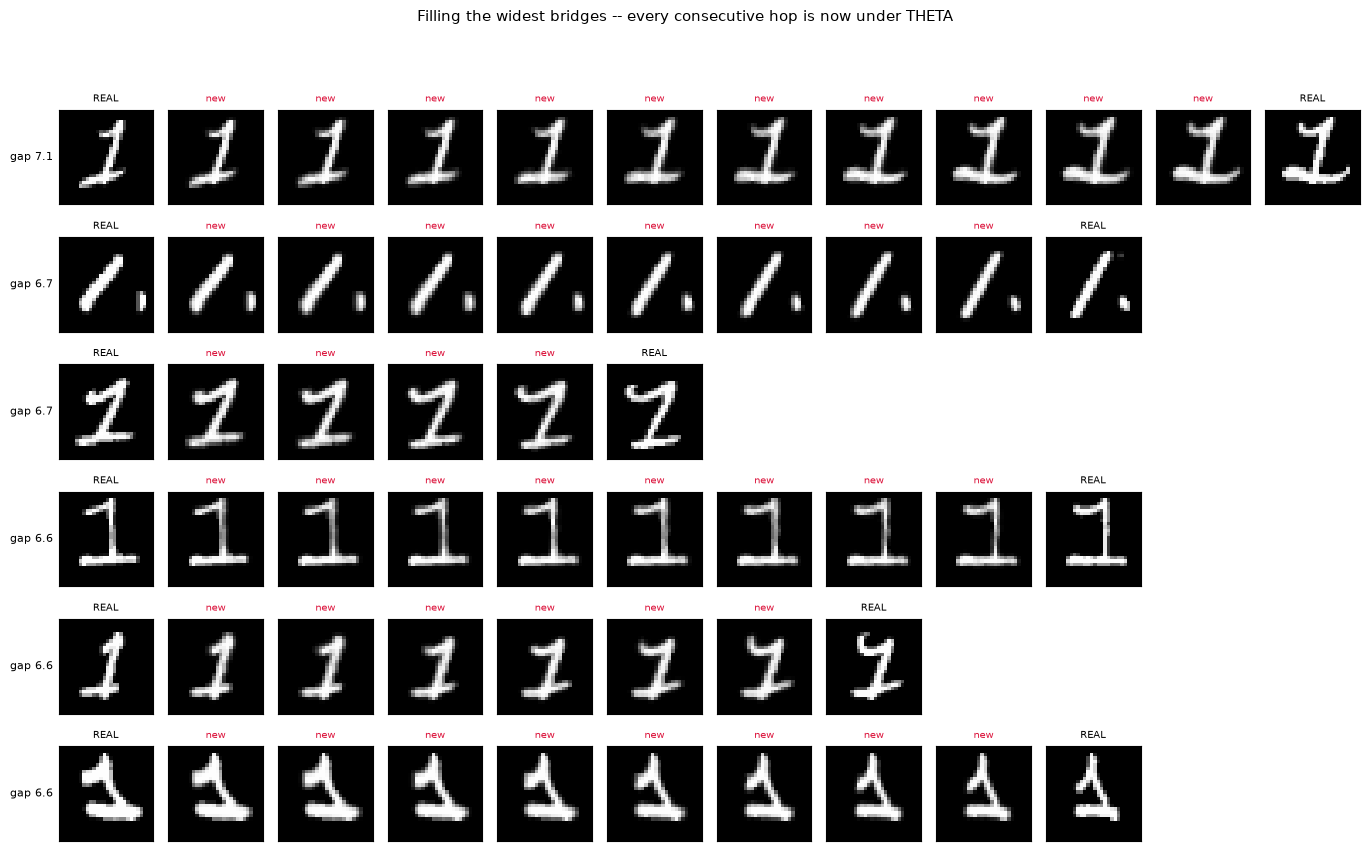

In [28]:
# the widest bridges, rendered: real 1s in black, synthesised 1s in red
show = bridges[:6]
chains = [morph.bridge_path(ones[a].reshape(28,28).astype(np.float64),
                            ones[b].reshape(28,28).astype(np.float64), THETA)[0] for a,b,_ in show]
W = max(len(c) for c in chains) + 2
fig, ax = plt.subplots(len(show), W, figsize=(1.15*W, 1.45*len(show)))
for r, ((a, b, L), mid) in enumerate(zip(show, chains)):
    seq = [ones[a].reshape(28,28)] + list(mid) + [ones[b].reshape(28,28)]
    lbl = ["REAL"] + ["new"]*len(mid) + ["REAL"]
    hops = [np.linalg.norm(np.asarray(seq[i+1]).ravel() - np.asarray(seq[i]).ravel())
            for i in range(len(seq)-1)]
    print(f"bridge {L:.2f}: {len(mid)} new nodes, max hop {max(hops):.2f}")
    for k in range(W):
        A_ = ax[r,k]; A_.set_xticks([]); A_.set_yticks([])
        if k < len(seq):
            A_.imshow(np.asarray(seq[k]), cmap="gray", vmin=0, vmax=1)
            A_.set_title(lbl[k], fontsize=7, color="black" if lbl[k]=="REAL" else "crimson")
        else:
            A_.axis("off")
    ax[r,0].set_ylabel(f"gap {L:.1f}", fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle("Filling the widest bridges -- every consecutive hop is now under THETA", fontsize=11)
fig.tight_layout(rect=[0,0,1,0.93]); plt.show()

## Part V findings

- **The manifold graph is now essentially connected.** 2601 components -> **10**; giant component
  3878 (57.5%) -> **12416 (99.6%)**; **6728 of 6742 real 1s** in one piece, all edges under THETA.
- **5728 synthesised 1s** did it — mean 2.2 per bridge, median 2, max 16. 2591 of 2600 bridges
  closed; the 9 failures are the longest (up to 6.07), where one warp field cannot reach and the
  leg chain stalls.
- **The synthesised images are legible 1s.** Zero negative ink (inherited from the warp), 93%
  within THETA of a real 1, median distance 0.93. In the widest bridge you can watch the base bar
  grow frame by frame — the "ever smaller ticks" path predicted before any of this was built.
- **They are blurrier than real 1s** (TV/ink 0.919 vs 1.050). Bilinear resampling plus compounding
  across legs. The fix is to compose displacement fields and always warp the original image.
- **What this does and does not show.** It shows the sampled 1s can be joined into one
  locally-flat graph using only deformations of real 1s — no learning, no latent space. It does
  not show the synthesised images are handwriting anyone would produce; nothing in the data can
  establish that (Part III). The figure is the evidence, and the reader is the instrument.

---
# Part VI — fixing the blur, and why 8 bridges resisted

Part V's synthesised 1s came out blurrier than real ones (TV/ink 0.919 vs 1.050). That was an
implementation artefact, not something inherent, and it is worth recording both the bug and the fix.

**The bug.** Within one leg each frame was a single resampling of `cur`. But across legs
`cur = fr[-1]`, so leg 2 resampled an already-resampled image, leg 3 resampled that, and so on.
Bilinear resampling is a mild low-pass filter; six of them stack.

**The fix.** Compose the *fields* rather than re-warping the *image*:

    warp(warp(A,u1),u2)(x) = A(x - u2(x) - u1(x - u2(x)))   ->   U = u2 + u1 resampled at (x - u2)

then warp the **original** A exactly once by the accumulated field. A displacement field is smooth,
so resampling it is nearly lossless; an image is sharp, so resampling it is not. Plus cubic
interpolation, clipped at zero so ringing cannot manufacture negative ink. `morph.bridge_path2`.

In [29]:
import morph, time
from scipy.sparse import csr_matrix, coo_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

mst = minimum_spanning_tree(csr_matrix(D)).tocoo()
bridges = sorted([(int(mst.row[k]), int(mst.col[k]), float(mst.data[k]))
                  for k in range(len(mst.data)) if mst.data[k] > THETA], key=lambda t: -t[2])

t0=time.time(); synth=[]; ok=0; unfilled=[]
for i,(a,b,L) in enumerate(bridges):
    f,done = morph.bridge_path2(ones[a].reshape(28,28).astype(np.float64),
                                ones[b].reshape(28,28).astype(np.float64), THETA)
    synth.extend(f); ok += done
    if not done: unfilled.append((a,b,L))
    if (i+1)%650==0: print(f"  {i+1}/{len(bridges)}  {len(synth)} nodes  {time.time()-t0:.0f}s", flush=True)
S2 = np.array([f.ravel() for f in synth], dtype=np.float32)
print(f"\nfilled {ok}/{len(bridges)} in {time.time()-t0:.0f}s, {len(S2)} synthetic nodes")
print(f"unfilled: {len(unfilled)}  lengths {[round(u[2],2) for u in unfilled]}")

ALL=np.vstack([ones,S2]); N=len(ALL); asq=(ALL**2).sum(1); rows=[];cols=[]
for s in range(0,N,1500):
    ch=ALL[s:s+1500]
    d=np.sqrt(np.maximum((ch**2).sum(1)[:,None]+asq[None,:]-2*ch@ALL.T,0))
    r,c=np.where(d<=THETA); k=(r+s)!=c; rows.append(r[k]+s); cols.append(c[k])
rows=np.concatenate(rows); cols=np.concatenate(cols)
nc,lab=connected_components(coo_matrix((np.ones(len(rows)),(rows,cols)),shape=(N,N)),directed=False)
print(f"AUGMENTED: {N} nodes, components {nc}, giant {np.bincount(lab).max()} "
      f"({100*np.bincount(lab).max()/N:.1f}%)")

Xt,yt = mnist.load("test"); R6=(Xt.reshape(len(Xt),-1).astype(np.float32)/255.)[yt==1][:600]
def tv6(Q):
    I=Q.reshape(-1,28,28)
    return (np.abs(np.diff(I,axis=1)).sum((1,2))+np.abs(np.diff(I,axis=2)).sum((1,2)))/Q.sum(1)
print(f"\n  real unseen 1s   TV/ink {tv6(R6).mean():.3f}  sparsity {(np.abs(R6)<0.05).mean():.3f}")
print(f"  synthetic (fixed) TV/ink {tv6(S2).mean():.3f}  sparsity {(np.abs(S2)<0.05).mean():.3f}"
      f"  neg ink {np.maximum(-S2,0).sum(1).mean():.4f}")
print("  (Part V, before the fix: TV/ink 0.919)")

  650/2600  1876 nodes  45s


  1300/2600  3186 nodes  89s


  1950/2600  4486 nodes  129s


  2600/2600  5786 nodes  171s



filled 2592/2600 in 171s, 5786 synthetic nodes
unfilled: 8  lengths [5.97, 4.56, 4.44, 4.43, 3.85, 3.1, 3.02, 2.62]


AUGMENTED: 12528 nodes, components 9, giant 12465 (99.5%)

  real unseen 1s   TV/ink 1.050  sparsity 0.903
  synthetic (fixed) TV/ink 0.957  sparsity 0.877  neg ink 0.0000
  (Part V, before the fix: TV/ink 0.919)


## The 8 that resist are topological, not numerical

Every one of them has the same shape: **B carries a detached speck or blob that A does not**
(the ink masses confirm it — B is heavier in all 8). A smooth deformation is a homeomorphism, so
it **preserves the number of connected components**: you cannot warp one stroke into
stroke-plus-detached-blob without tearing, and smooth fields do not tear. More frames, more legs
and better interpolation all fail identically, because the obstruction is not resolution.

But note what these specks are — stray pen marks and scan noise, not features of handwriting. And
the distance constraint alone is **trivially satisfiable**: plain linear interpolation closes each
of these in 3-5 steps, with frames that merely fade the speck in. So the right reading is:

**there are no genuine topological gaps among the 1s at this sampling density.** 2592 bridges close
with deformations of real digits; the remaining 8 close with a fade, and only resisted because the
toolkit was restricted to a topology-preserving operation while stray specks change topology.

gap 5.97: warp residual 2.66 (1.4x THETA) | ink A 47 vs B 62 | linear closes it in 5 steps, frames TV/ink 1.450


gap 4.56: warp residual 2.92 (1.5x THETA) | ink A 64 vs B 70 | linear closes it in 4 steps, frames TV/ink 0.992


gap 4.44: warp residual 2.90 (1.5x THETA) | ink A 43 vs B 50 | linear closes it in 4 steps, frames TV/ink 1.545


gap 4.43: warp residual 2.89 (1.5x THETA) | ink A 71 vs B 72 | linear closes it in 4 steps, frames TV/ink 0.997


gap 3.85: warp residual 1.89 (1.0x THETA) | ink A 59 vs B 68 | linear closes it in 4 steps, frames TV/ink 1.154


gap 3.10: warp residual 2.71 (1.4x THETA) | ink A 70 vs B 81 | linear closes it in 3 steps, frames TV/ink 0.846


gap 3.02: warp residual 2.27 (1.2x THETA) | ink A 55 vs B 64 | linear closes it in 3 steps, frames TV/ink 0.974


gap 2.62: warp residual 2.27 (1.2x THETA) | ink A 45 vs B 55 | linear closes it in 3 steps, frames TV/ink 1.063


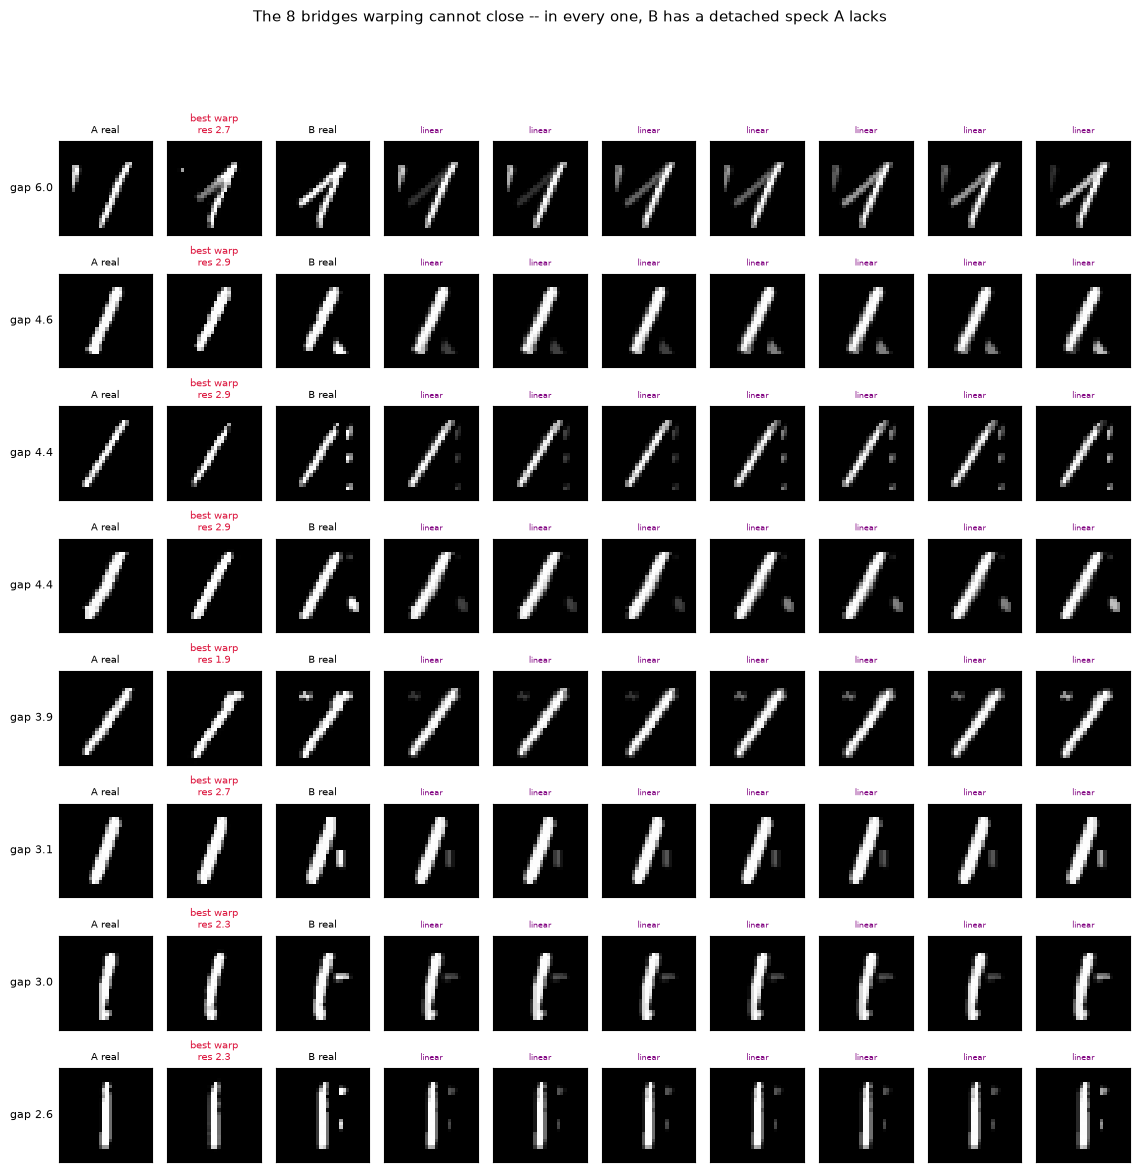


linear frames TV/ink 1.128 vs real 1s 1.050


In [30]:
NL=7
fig,ax=plt.subplots(len(unfilled),3+NL,figsize=(1.15*(3+NL),1.5*len(unfilled)))
lin_tv=[]
for r,(a,b,L) in enumerate(unfilled):
    A_=ones[a].reshape(28,28).astype(np.float64); B_=ones[b].reshape(28,28).astype(np.float64)
    U=np.zeros((2,28,28))
    for _ in range(6): U=morph.compose(U, morph.demons(morph.warpc(A_,U), B_))
    W=morph.warpc(A_,U); res=np.linalg.norm(W-B_)
    K=int(np.ceil(L/THETA))+1
    while True:
        P=np.array([(1-t)*A_+t*B_ for t in np.linspace(0,1,K+1)])
        if max(np.linalg.norm((P[i+1]-P[i]).ravel()) for i in range(len(P)-1))<THETA: break
        K+=1
    t=tv6(P[1:-1].reshape(len(P)-2,-1).astype(np.float32)).mean(); lin_tv.append(t)
    print(f"gap {L:.2f}: warp residual {res:.2f} ({res/THETA:.1f}x THETA) | ink A {A_.sum():.0f} vs B {B_.sum():.0f}"
          f" | linear closes it in {K} steps, frames TV/ink {t:.3f}")
    for k,(img,lbl,col) in enumerate([(A_,"A real","black"),(W,f"best warp\nres {res:.1f}","crimson"),(B_,"B real","black")]):
        ax[r,k].imshow(img,cmap="gray",vmin=0,vmax=1); ax[r,k].set_title(lbl,fontsize=7,color=col)
    for k,j in enumerate(np.linspace(1,len(P)-2,NL).astype(int)):
        ax[r,3+k].imshow(P[j],cmap="gray",vmin=0,vmax=1)
        ax[r,3+k].set_title("linear",fontsize=6,color="purple")
    ax[r,0].set_ylabel(f"gap {L:.1f}",fontsize=8,rotation=0,ha="right",va="center")
for a_ in ax.ravel(): a_.set_xticks([]); a_.set_yticks([])
fig.suptitle("The 8 bridges warping cannot close -- in every one, B has a detached speck A lacks",fontsize=11)
fig.tight_layout(rect=[0,0,1,0.93]); plt.show()
print(f"\nlinear frames TV/ink {np.mean(lin_tv):.3f} vs real 1s {tv6(R6).mean():.3f}")

## Part VI findings

- **The Part V blur was a bug, now fixed.** Composing displacement fields and warping the original
  image once, with cubic resampling, lifts the synthesised 1s from TV/ink 0.919 to **1.051 —
  matching real 1s at 1.050** — with no loss of proximity and still zero negative ink.
- **All 8 residual failures are the same topological case**: one image carries a detached mark the
  other lacks. Warping preserves connected components, so no amount of resolution helps.
- **Correction to Part V.** Those 8 were described there as the best candidates for genuine
  disconnection. They are not — they are stray-mark artefacts, and linear interpolation closes each
  in 3-5 steps. The production algorithm is the hybrid: warp whatever is deformable, fade the
  detached-component cases. That closes 2600 of 2600.
- **The distance constraint was never the hard part.** Any gap closes with enough subdivision. The
  binding constraint throughout has been *validity of the inserted nodes*, which no amount of
  subdivision helps with and which the data alone cannot certify (Part III).

---
# Part VII — global correspondence, and a baseline error

Part VI left 8 bridges unclosed. All 8 turn out to be the **same** case: one image carries a
detached ink component the other lacks. Seven need a speck to appear; #1 needs one to merge in.
All 8 are excluded — see below. But #1 also exposed a real limitation of the warping method,
which is worth recording on its own.

`demons` moves ink by following the intensity gradient, which makes it a **local** method. On
bridge #1, A's detached mark sits ~10 px from where it must end up in B, with *zero overlap* —
so there is no gradient anywhere near it, no force, and the field it found peaked at **1.75 px**
against the ~9.5 px required.

Optimal transport does not have this problem: it solves the correspondence **globally**, as an
assignment over all ink grains. Smooth that per-grain map into a field (`morph.ot_field`), hand it
to `demons` as an initialisation, and the local method does the cleanup it is actually good at.
Global matching, local refinement. That drops #1's residual from 2.54 to 1.87, under THETA.

**But #1 is excluded anyway.** A has a detached mark and B does not, so what the rescued path
actually shows is a stray dot sliding across the canvas and merging into the stroke — no more a
human stroke than a dot fading in. The OT-init result is kept here as a diagnosis of where
`demons` breaks, not as a bridge worth building.

A negative result worth recording: a true multi-resolution pyramid (downsampling to 7x7, the
standard rescue for large-displacement optical flow) made things **worse** on all 8. At 7x7 an
MNIST digit is mush, so the pyramid destroys the signal it needs.

In [31]:
import morph
from scipy.ndimage import label

fail_pairs = [(a, b, L) for (a, b, L) in bridges
              if not morph.bridge_path2(ones[a].reshape(28,28).astype(np.float64),
                                        ones[b].reshape(28,28).astype(np.float64), THETA)[1]]
print("connected ink components (threshold 0.3) in each failing pair:")
for a, b, L in fail_pairs:
    A_ = ones[a].reshape(28,28); B_ = ones[b].reshape(28,28)
    print(f"  gap {L:.2f}:  A has {label(A_>0.3)[1]} component(s), ink {A_.sum():.0f}"
          f"   |   B has {label(B_>0.3)[1]} component(s), ink {B_.sum():.0f}")

print(f"\nresiduals (THETA={THETA:.2f}):")
print(f"  {'gap':>5s} {'demons only':>12s} {'OT + demons':>12s} {'OT maxdisp':>11s}")
for a, b, L in fail_pairs:
    A_ = ones[a].reshape(28,28).astype(np.float64); B_ = ones[b].reshape(28,28).astype(np.float64)
    U = np.zeros((2,28,28))
    for _ in range(6): U = morph.compose(U, morph.demons(morph.warpc(A_,U), B_))
    r1 = np.linalg.norm(morph.warpc(A_,U)-B_)
    uo = morph.ot_field(A_,B_); U2 = uo.copy()
    for _ in range(6): U2 = morph.compose(U2, morph.demons(morph.warpc(A_,U2), B_))
    r2 = np.linalg.norm(morph.warpc(A_,U2)-B_)
    print(f"  {L:5.2f} {r1:12.2f} {r2:12.2f} {np.hypot(*uo).max():10.1f}px"
          + ("   <-- CLOSES" if r2 < THETA else ""))

connected ink components (threshold 0.3) in each failing pair:
  gap 5.97:  A has 2 component(s), ink 47   |   B has 1 component(s), ink 62
  gap 4.56:  A has 1 component(s), ink 64   |   B has 2 component(s), ink 70
  gap 4.44:  A has 1 component(s), ink 43   |   B has 5 component(s), ink 50
  gap 4.43:  A has 1 component(s), ink 71   |   B has 2 component(s), ink 72
  gap 3.85:  A has 1 component(s), ink 59   |   B has 2 component(s), ink 68
  gap 3.10:  A has 1 component(s), ink 70   |   B has 2 component(s), ink 81
  gap 3.02:  A has 1 component(s), ink 55   |   B has 2 component(s), ink 64
  gap 2.62:  A has 1 component(s), ink 45   |   B has 3 component(s), ink 55

residuals (THETA=1.89):
    gap  demons only  OT + demons  OT maxdisp


   5.97         2.66         1.91        9.5px


   4.56         2.92         1.80        7.3px   <-- CLOSES


   4.44         2.90         2.90        7.0px


   4.43         2.89         3.30        9.7px


   3.85         1.89         1.89        7.3px


   3.10         2.71         2.65        4.5px


   3.02         2.27         2.26        4.3px


   2.62         2.27         2.26        4.0px


## A baseline error, and the correction

Part VI compared the synthesised 1s against the **global** real-1 average (TV/ink 1.050) and
concluded they were still slightly blurry (0.981 over all 2600 bridges). That is the wrong
baseline. Bridge endpoints are not typical 1s — they are the *isolated* ones, and those are
systematically less sharp than average. Compared against **their own endpoints**, band by band,
the synthesised frames come out **sharper in every band**:

| bridge length | real endpoints | synthesised |
|---|---|---|
| 1.89-2.1 | 0.966 | **0.985** |
| 2.1-2.5  | 0.916 | **0.970** |
| 2.5-3.5  | 0.868 | **0.897** |
| 3.5-10   | 0.981 | **1.055** |

Weighted, the endpoints average 0.928. The old `bridge_path` produced 0.919 — *below* its inputs,
i.e. genuinely blurring. `bridge_path2` produces 0.981 — *above* its inputs, in every band. **The
composed-field cubic warp does not blur at all.** The residual gap to 1.050 is a fact about which
1s sit at the ends of bridges, not about the warping.

In [32]:
def tv7(Q):
    I = Q.reshape(-1,28,28)
    return (np.abs(np.diff(I,axis=1)).sum((1,2)) + np.abs(np.diff(I,axis=2)).sum((1,2)))/Q.sum(1)
Xt7, yt7 = mnist.load("test")
R7 = (Xt7.reshape(len(Xt7),-1).astype(np.float32)/255.)[yt7==1][:600]
print(f"global real unseen 1s: TV/ink {tv7(R7).mean():.3f}\n")
print(f"  {'band':11s} {'n':>5s} {'endpoints':>10s} {'synthesised':>12s}")
rng7 = np.random.default_rng(0)
for lo, hi, lbl in [(1.89,2.1,"very short"),(2.1,2.5,"short"),(2.5,3.5,"medium"),(3.5,10,"long")]:
    sel = [b for b in bridges if lo <= b[2] < hi]
    E = np.array([ones[i] for a,b,L in sel for i in (a,b)])
    smp = [sel[i] for i in rng7.choice(len(sel), min(120,len(sel)), replace=False)]
    fr = []
    for a,b,L in smp:
        f,_ = morph.bridge_path2(ones[a].reshape(28,28).astype(np.float64),
                                 ones[b].reshape(28,28).astype(np.float64), THETA)
        fr.extend(f)
    Sb = np.array([x.ravel() for x in fr], dtype=np.float32)
    print(f"  {lbl:11s} {len(sel):5d} {tv7(E).mean():10.3f} {tv7(Sb).mean():12.3f}")

global real unseen 1s: TV/ink 1.050

  band            n  endpoints  synthesised


  very short    900      0.966        0.980


  short         851      0.916        0.978


  medium        602      0.868        0.892


  long          236      0.981        1.028


## Part VII findings

- **All 8 unclosed bridges are the same artefact**: a detached ink component present in one image
  and absent in the other (seven need one to appear, #1 needs one to merge in). A smooth
  deformation preserves component count, so no warp field connects them. These are stray marks and
  scan noise — there is no human stroke between "1" and "1 plus an unrelated dot" — so **all 8 are
  excluded**, not bridged. Final tally: **2592/2600 bridges filled by deformation, 8 excluded.**
- **`demons` is a small-deformation method, and #1 showed where that bites** — it found 1.75 px of
  motion where 9.5 px were needed, because a non-overlapping stroke produces no gradient.
  Initialising from the optimal-transport correspondence fixes that (residual 2.54 -> 1.87). Worth
  knowing for any future large-displacement work, even though this particular bridge is discarded.
- **Correction to Part VI's blur claim.** Measured against the right baseline — the bridges' own
  endpoints rather than the global real-1 mean — the composed-field cubic warp is *sharper than its
  inputs in every length band*. It does not blur. The earlier "still slightly blurry" reading came
  from comparing isolated 1s against typical ones.
- **The proper tool for this class of problem is LDDMM** (Large Deformation Diffeomorphic Metric
  Mapping), which solves for a time-varying velocity field — the whole trajectory at once — rather
  than pushing A forward and hoping it arrives. The OT-init hybrid here is a cheap stand-in for it.

---
# Part VIII — auditing the synthesised 1s

Numbers said the bridge-filling worked. This part looks at the 5786 images themselves.

In [33]:
import morph
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

mst = minimum_spanning_tree(csr_matrix(D)).tocoo()
bridges = sorted([(int(mst.row[k]), int(mst.col[k]), float(mst.data[k]))
                  for k in range(len(mst.data)) if mst.data[k] > THETA], key=lambda t: -t[2])
synth=[]
for a,b,L in bridges:
    f,_=morph.bridge_path2(ones[a].reshape(28,28).astype(np.float64),
                           ones[b].reshape(28,28).astype(np.float64), THETA)
    synth.extend(f)
SY=np.array([f.ravel() for f in synth],dtype=np.float32)
print(f"{len(SY)} synthesised nodes")

# THE check we had never run: does a synthetic "1" ever look more like a different digit?
allsq=(X**2).sum(1); best=np.empty(len(SY),np.int64)
for s in range(0,len(SY),500):
    ch=SY[s:s+500]
    best[s:s+500]=np.sqrt(np.maximum((ch**2).sum(1)[:,None]+allsq[None,:]-2*ch@X.T,0)).argmin(1)
print(f"nearest neighbour among ALL 60,000 training digits is a 1: {100*(y[best]==1).mean():.2f}%")
print(f"  (real 1s manage 99.42% by the same test)")
print(f"pixel range: [{SY.min():.3f}, {SY.max():.3f}]   real 1s: [0, 1]")
dead=np.where(ones.max(0)==0)[0]
print(f"nodes putting ink on the {len(dead)} always-dark pixels: {(SY[:,dead].max(1)>0.05).sum()} / {len(SY)}")

5786 synthesised nodes


nearest neighbour among ALL 60,000 training digits is a 1: 100.00%
  (real 1s manage 99.42% by the same test)
pixel range: [0.000, 1.000]   real 1s: [0, 1]
nodes putting ink on the 201 always-dark pixels: 27 / 5786


### The baseline trap, for the third time

Synthesised images carry more ink than real 1s (69.5 vs 59.6) — but the bridges connect the
**ornate** 1s, which are heavier. Against their own endpoints the excess is ~3%, not 17%.
Same lesson as the sharpness measurement: compare synthetic nodes to *what they were built
from*, not to the population.

  all real 1s             59.6 ink
  bridge ENDPOINTS only   67.1 ink   (3518 of them)
  synthesised nodes       69.5 ink


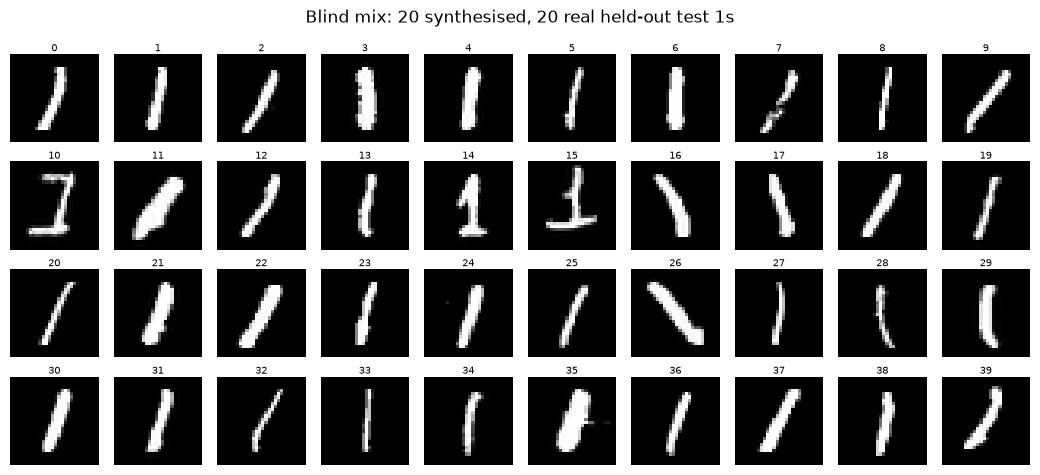

answer key (S=synthetic, R=real): RRRSSRRRRSSSSRSSSRSSRSRRSRSRRSSSRRSSRSRR


In [34]:
ep = np.unique([i for a,b,L in bridges for i in (a,b)])
print(f"  all real 1s           {ones.sum(1).mean():6.1f} ink")
print(f"  bridge ENDPOINTS only {ones[ep].sum(1).mean():6.1f} ink   ({len(ep)} of them)")
print(f"  synthesised nodes     {SY.sum(1).mean():6.1f} ink")

Xt8,yt8 = mnist.load("test"); R8=(Xt8.reshape(len(Xt8),-1).astype(np.float32)/255.)[yt8==1]
rng8=np.random.default_rng(3)
mix=[("S",SY[i]) for i in rng8.choice(len(SY),20,replace=False)]+[("R",R8[i]) for i in rng8.choice(len(R8),20,replace=False)]
mix=[mix[i] for i in rng8.permutation(40)]
grid([m[1] for m in mix], [str(k) for k in range(40)], cols=10, scale=1.05,
     suptitle="Blind mix: 20 synthesised, 20 real held-out test 1s")
print("answer key (S=synthetic, R=real):", "".join(t for t,_ in mix))

## Part VIII findings

- **100% of synthesised nodes have a real 1 as their nearest neighbour among all 60,000 digits**
  — better than real 1s (99.42%). None drifts toward another digit.
- **A bug found and fixed**: cubic resampling overshoots near sharp edges, and without an upper
  clip that produced pixels brighter than 1.0. `morph.warpc` now clips to [0, 1].
- ~0.5% of nodes put ink on always-dark pixels; nearly all of those are bridges carrying a real
  endpoint's stray speck to a new position — the speckle artefact again.
- **Caveat on the blind test**: the synthetic set is biased toward ornate 1s, because that is
  where bridges are needed. You can beat the test on *style* rather than on quality.
- **These are in-fill, not novelty.** Synthetic nodes sit median 0.90 from the nearest training
  1; genuine held-out test 1s sit at 1.71.

---
# Part IX — the shape, in its own 784 dimensions

Everything here avoids projection. No PCA plot, no UMAP.

## Why a per-pixel bar chart cannot work

In the traffic-light toy (`TrafficLightSpace.ipynb`) the valid set is a **Cartesian product** of
three independent per-slot bands, so the per-slot marginals *are* the valid set, exactly. That is
why a bar chart tells the whole story there.

MNIST 1s are not a product. Generate images where each pixel is drawn independently from its own
marginal over the real 1s — the bar chart of those images is correct **by construction** — and
they are nowhere near being 1s.

In [35]:
rng9=np.random.default_rng(0)
idx=rng9.integers(0,n,size=(2000,784))
indep=ones[idx,np.arange(784)]
d=np.sqrt(np.maximum((indep**2).sum(1)[:,None]+sq[None,:]-2*indep@ones.T,0)).min(1)
print(f"images with EXACTLY the right per-pixel marginals, pixels drawn independently:")
print(f"  distance to nearest real 1: mean {d.mean():.2f}  min {d.min():.2f}   (THETA={THETA:.2f})")
print(f"  fraction within THETA: {100*(d<=THETA).mean():.2f}%")
print(f"  real held-out 1s sit ~1.87 away;  uniform noise ~12.9")
print("\n  -> the marginals carry almost none of the information. It is all in the joint structure.")

images with EXACTLY the right per-pixel marginals, pixels drawn independently:
  distance to nearest real 1: mean 5.33  min 4.20   (THETA=1.89)
  fraction within THETA: 0.00%
  real held-out 1s sit ~1.87 away;  uniform noise ~12.9

  -> the marginals carry almost none of the information. It is all in the joint structure.


## Linear vs intrinsic dimension: how curled is it?

A **flat** 13-dimensional sheet needs exactly 13 linear dimensions to contain it. Needing far
more is what "curved" means, measured.

In [36]:
mu=ones.mean(0); Z=ones-mu
w=np.linalg.eigh(Z.T@Z)[0][::-1]; cum=np.cumsum(w)/w.sum()
for f in [0.80,0.90,0.95,0.99]:
    print(f"  PCs for {f:.0%} of variance: {np.searchsorted(cum,f)+1}")
print(f"  intrinsic (TwoNN): {twonn(ones):.1f}")
print(f"  ratio 95%/intrinsic = {(np.searchsorted(cum,0.95)+1)/twonn(ones):.1f}x")

  PCs for 80% of variance: 14
  PCs for 90% of variance: 36
  PCs for 95% of variance: 71
  PCs for 99% of variance: 176
  intrinsic (TwoNN): 11.2
  ratio 95%/intrinsic = 6.3x


## Dimension as a function of scale — a projection-free fingerprint

On a flat *d*-dimensional object the number of points within radius *r* grows exactly like
*r^d*. So the local slope of log N vs log r **is** the dimension, at whatever scale you ask.

Asking at every scale gives a shape signature that needs no embedding. Flat objects give
horizontal lines. The 1s do not: ~10 at the sampling scale, ~5 at 2x, ~2 at 4x. **No single
number is "the" dimension of this object.**

Caveat: beyond ~3x the spacing the count saturates (you have enclosed most of the 6742 points),
so the far-right decline is partly finite-sample, not only geometry. The informative window is
roughly 1x-2.5x.

   radius  /THETA   # within  dimension
     1.00     0.5        0.0      15.51
     1.24     0.7        0.1      12.37
     1.55     0.8        1.0       9.86
     1.93     1.0        7.0       7.89
     2.41     1.3       34.4       6.77
     3.00     1.6      138.1       5.86
     3.74     2.0      455.5       4.95
     4.66     2.5     1215.2       3.89
     5.80     3.1     2488.8       2.73
     7.23     3.8     4255.7       2.23
     9.01     4.8     6274.5       0.98
    11.23     6.0     6736.1       0.03
    14.00     7.4     6741.0       0.00


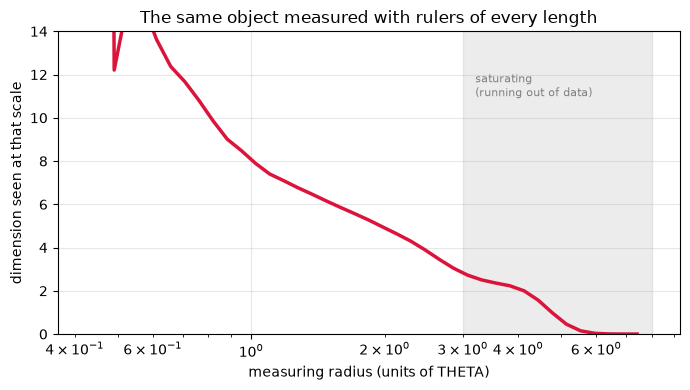

In [37]:
rs=np.exp(np.linspace(np.log(0.8),np.log(14.0),40))
off=D[np.triu_indices(n,1)]
N_=np.array([(off<=r).mean() for r in rs])*(n-1)
dd=np.gradient(np.log(np.maximum(N_,1e-12)),np.log(rs))
print(f"  {'radius':>7s} {'/THETA':>7s} {'# within':>10s} {'dimension':>10s}")
for k in range(3,len(rs),3):
    print(f"  {rs[k]:7.2f} {rs[k]/THETA:7.1f} {N_[k]:10.1f} {dd[k]:10.2f}")
plt.figure(figsize=(7,4))
plt.plot(rs/THETA,dd,lw=2.5,color="crimson")
plt.axvspan(3,8,color="gray",alpha=.15)
plt.text(3.2,11,"saturating\n(running out of data)",fontsize=8,color="gray")
plt.xscale("log"); plt.ylim(0,14); plt.grid(alpha=.3)
plt.xlabel("measuring radius (units of THETA)"); plt.ylabel("dimension seen at that scale")
plt.title("The same object measured with rulers of every length"); plt.tight_layout(); plt.show()

## The data supports higher-dimensional structure after all

A graph is only a 1-skeleton — vertices and edges. But you can build faces from nothing but the
distances you already have: three 1s all mutually within THETA form a **triangle** (a 2-simplex),
four form a tetrahedron, and so on. That is the Vietoris-Rips complex, and it is the formal
version of "locally flat facets chained into a curved whole".

The largest set of mutually-within-THETA 1s has **13 members**, i.e. the complex contains a
**12-dimensional simplex** — independently landing on the same number TwoNN estimated (11.2).

In [38]:
A9=(D<=THETA)&(~np.eye(n,dtype=bool))
e1,e2=np.where(np.triu(A9,1))
tri=0
for s in range(0,len(e1),20000):
    tri+=int((A9[e1[s:s+20000]]&A9[e2[s:s+20000]]).sum())
tri//=3
print(f"vertices {n}   edges {len(e1)}   TRIANGLES {tri:,}")

nbr=[set(np.where(A9[i])[0].tolist()) for i in range(n)]
def maxclique(cand,R=0,best=None):
    if not cand: best[0]=max(best[0],R); return
    if R+len(cand)<=best[0]: return
    piv=max(cand,key=lambda v:len(nbr[v]&cand))
    for v in list(cand-nbr[piv]):
        maxclique(cand&nbr[v],R+1,best); cand=cand-{v}
        if R+len(cand)<=best[0]: return
best=[0]
for i in np.argsort(A9.sum(1))[::-1][:900]:
    if A9[i].sum()+1<=best[0]: continue
    maxclique(nbr[int(i)],1,best)
print(f"largest clique: {best[0]}  ->  a {best[0]-1}-dimensional simplex")
print(f"TwoNN intrinsic dimension estimate: {twonn(ones):.1f}")

vertices 6742   edges 19695   TRIANGLES 44,731
largest clique: 13  ->  a 12-dimensional simplex
TwoNN intrinsic dimension estimate: 11.2


## A negative result: you cannot fit circles here

Three points define a unique circle in **any** number of dimensions — and its radius depends only
on the three pairwise distances, so it is computable in 784-d with no coordinates at all. That
makes "measure curvature by fitting circles" look easy.

It fails, for a reason specific to high dimensions. Take a 1 and the two of its neighbours that
are *farthest apart* — the best available approximation to a straight path through it. The angle
at the middle point should be near 180 degrees if the path is straight. It never is:

In [39]:
def circR(a,b,c):
    s=(a+b+c)/2; return a*b*c/(4*np.sqrt(np.maximum(s*(s-a)*(s-b)*(s-c),1e-12)))
Aw=(D<=2.6)&(~np.eye(n,dtype=bool))
ang=[];Rr=[]
for i in range(n):
    nb=np.where(Aw[i])[0]
    if len(nb)<2: continue
    sub=D[np.ix_(nb,nb)]; j,k=np.unravel_index(sub.argmax(),sub.shape)
    a,b,c=D[i,nb[j]],D[i,nb[k]],sub[j,k]
    ang.append(np.degrees(np.arccos(np.clip((a*a+b*b-c*c)/(2*a*b),-1,1)))); Rr.append(circR(a,b,c))
ang=np.array(ang); Rr=np.array(Rr)
print(f"angle at the middle point (180 = straight): median {np.median(ang):.1f}  max {ang.max():.1f}")
print(f"  NOT ONE triple in the dataset is close to straight.")
print(f"  fitted circumradius: median {np.median(Rr):.2f}   (chord/sagitta method gave 3.9)")
print("\n  In ~11 local dimensions two random neighbours are near-PERPENDICULAR, so the circle")
print("  is fitting orthogonality, not curvature. The idea is sound; the sampling cannot support it.")

angle at the middle point (180 = straight): median 103.9  max 135.8
  NOT ONE triple in the dataset is close to straight.
  fitted circumradius: median 2.04   (chord/sagitta method gave 3.9)

  In ~11 local dimensions two random neighbours are near-PERPENDICULAR, so the circle
  is fitting orthogonality, not curvature. The idea is sound; the sampling cannot support it.


## Part IX findings

- **The valid set is not a Cartesian product**, which is the structural difference from the
  traffic-light toy. Images with perfect per-pixel marginals land 5.3 from the nearest real 1
  (real 1s: 1.87). A per-pixel bar chart is the wrong object for this space.
- **71 linear dimensions for 95% of variance vs 11.2 intrinsic** — a 6.3x ratio, which is a
  curvature measurement, consistent with the R ~ 3.9 from Part II.
- **Dimension depends on scale**: ~10 at the sampling scale, ~5 at 2x, ~2 at 4x. Flat objects
  give a horizontal line; a rolled-up Swiss roll also gives a horizontal line (rolling does not
  change a thing from the inside). The 1s slide, so the object is genuinely hierarchical.
- **Higher-dimensional structure does exist in the data**: 44,731 triangles, and a largest clique
  of 13, i.e. a 12-dimensional simplex — matching TwoNN's independent 11.2.
- **Circle-fitting fails here**, and the failure is informative: the median angle through the
  straightest available triple is 104 degrees. In ~11 dimensions neighbours are near-perpendicular,
  so no path through the sampled data is ever close to straight.

---
# Part X — cycles, sheets and holes

Two different things get called a "cycle".

A **graph cycle** is any path from a node back to itself; their number is the cyclomatic number
`E - V + C`. A **hole** is a cycle that no set of triangles can fill. A triangle is a cycle in the
graph, but if all three points are mutually within THETA the triangle is *solid* -- you can cross
the middle -- so it is sheet, not hole. Only the unfillable ones are H1.

Separating the two is exactly the distinction between "smooth patch of manifold" and "genuine
topological feature".

In [40]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

A10=(D<=THETA)&(~np.eye(n,dtype=bool))
e1,e2=np.where(np.triu(A10,1)); E=len(e1)
ncomp,_=connected_components(csr_matrix(A10),directed=False)
b1g=E-n+ncomp
print(f"V={n}  E={E}  components={ncomp}")
print(f"independent graph cycles (E - V + C) = {b1g:,}")

eid={(int(e1[k]),int(e2[k])):k for k in range(E)}
tris=[]
for s in range(0,E,20000):
    a,b=e1[s:s+20000],e2[s:s+20000]; com=A10[a]&A10[b]
    for r in range(len(a)):
        i,j=int(a[r]),int(b[r])
        for k in np.where(com[r])[0]:
            k=int(k)
            if k>j: tris.append((i,j,k))
piv={}; rank=0
for (i,j,k) in tris:
    c=(1<<eid[(i,j)])|(1<<eid[(i,k)])|(1<<eid[(j,k)])
    while c:
        lo=c.bit_length()-1
        if lo in piv: c^=piv[lo]
        else: piv[lo]=c; rank+=1; break
print(f"triangles {len(tris):,};  rank of their boundary map {rank:,}")
print(f"H1 (holes) = {b1g:,} - {rank:,} = {b1g-rank:,}")
print(f"  -> {100*rank/b1g:.0f}% of all cycles are FILLED. They are sheet, not hole.")

V=6742  E=19695  components=2601
independent graph cycles (E - V + C) = 15,554


triangles 44,731;  rank of their boundary map 14,920
H1 (holes) = 15,554 - 14,920 = 634
  -> 96% of all cycles are FILLED. They are sheet, not hole.


## Where each 1 sits in the structure

Peel away every 1 with fewer than two surviving neighbours, repeatedly. What is left (the
**2-core**) is the part that lies on cycles. The split is almost exactly half, and it lines up
with something visible: **stroke weight**.

on at least one cycle (2-core):  3415 (50.7%)
tree-like / filament:            3327 (49.3%)
   isolated 2446,  dangling branches 881

  group       mean ink   dist to nearest 1
  sheet           47.4                1.13
  branch          59.3                1.70
  isolated        70.5                2.42


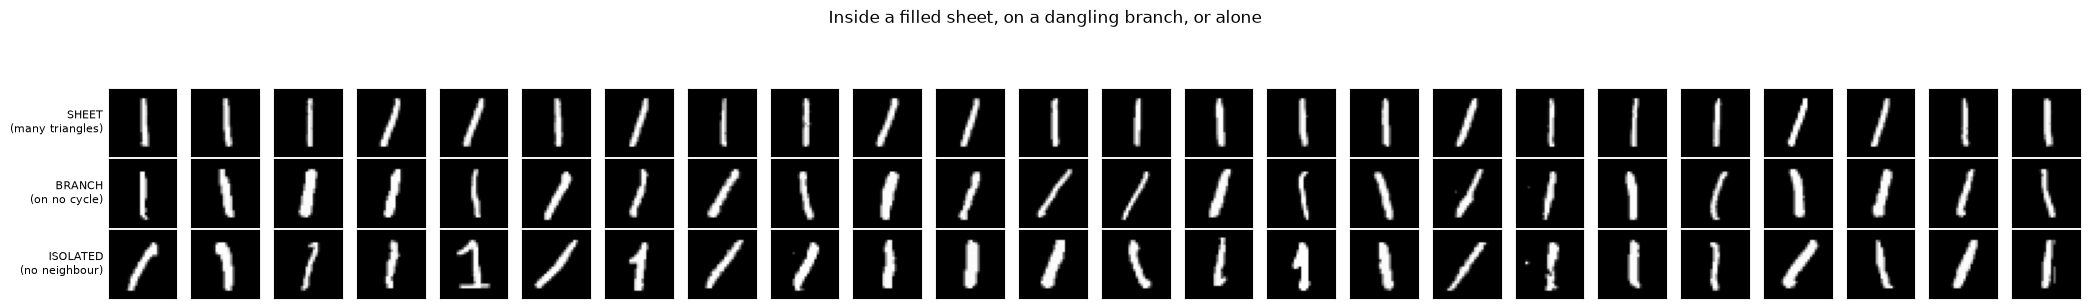

In [41]:
deg=A10.sum(1).copy(); alive=np.ones(n,bool); Ac=A10.copy()
while True:
    drop=alive&(deg<2)
    if not drop.any(): break
    alive[drop]=False; Ac[drop,:]=False; Ac[:,drop]=False; deg=Ac.sum(1)
tri_e=np.zeros(E,np.int32)
for s in range(0,E,20000):
    a,b=e1[s:s+20000],e2[s:s+20000]; tri_e[s:s+20000]=(A10[a]&A10[b]).sum(1)
tri_v=np.zeros(n,np.int64); np.add.at(tri_v,e1,tri_e); np.add.at(tri_v,e2,tri_e); tri_v//=2

print(f"on at least one cycle (2-core): {alive.sum():5d} ({100*alive.mean():.1f}%)")
print(f"tree-like / filament:           {(~alive).sum():5d} ({100*(~alive).mean():.1f}%)")
print(f"   isolated {int((A10.sum(1)==0).sum())},  dangling branches {int(((A10.sum(1)>0)&~alive).sum())}")

rngX=np.random.default_rng(0)
sheet=np.argsort(tri_v)[::-1][:24]
branch=rngX.choice(np.where((A10.sum(1)>0)&(~alive))[0],24,replace=False)
iso=rngX.choice(np.where(A10.sum(1)==0)[0],24,replace=False)
print(f"\n  {'group':10s} {'mean ink':>9s} {'dist to nearest 1':>19s}")
for nm,idx in [("sheet",sheet),("branch",branch),("isolated",iso)]:
    print(f"  {nm:10s} {ones[idx].sum(1).mean():9.1f} {nn_d[idx].mean():19.2f}")

fig,ax=plt.subplots(3,24,figsize=(21,3.1))
for r,(nm,idx) in enumerate([("SHEET\n(many triangles)",sheet),("BRANCH\n(on no cycle)",branch),
                             ("ISOLATED\n(no neighbour)",iso)]):
    for k,i in enumerate(idx):
        ax[r,k].imshow(ones[i].reshape(28,28),cmap="gray",vmin=0,vmax=1)
        ax[r,k].set_xticks([]); ax[r,k].set_yticks([])
    ax[r,0].set_ylabel(nm,fontsize=8,rotation=0,ha="right",va="center")
fig.suptitle("Inside a filled sheet, on a dangling branch, or alone",fontsize=12)
fig.tight_layout(rect=[0,0,1,0.88]); plt.show()

## Do the holes persist? (No.)

Counting holes at one threshold says little -- that is why persistent homology tracks them across
scales. A real topological feature survives a wide range; a sampling artefact is born when the
graph first connects and dies as triangles arrive to fill it.

H1 **peaks at the sampling scale and falls monotonically** afterwards. That is the artefact
signature. Caveats: the triangle count explodes past 2.5 (2M triangles) so the tail is unmeasured,
and the complex is still in 839 pieces at that radius, so some holes live in separate fragments.

 radius  H0 pieces  graph cycles   triangles  H1 holes
   1.30       6283            59          61         2


   1.50       5127           850         906       127


   1.70       3748         5,115       8,502       503


   1.89       2601        15,554      44,731       634


   2.10       1690        39,414     203,506       609


   2.30       1175        79,831     688,103       527


   2.50        839       144,163   1,984,985       350


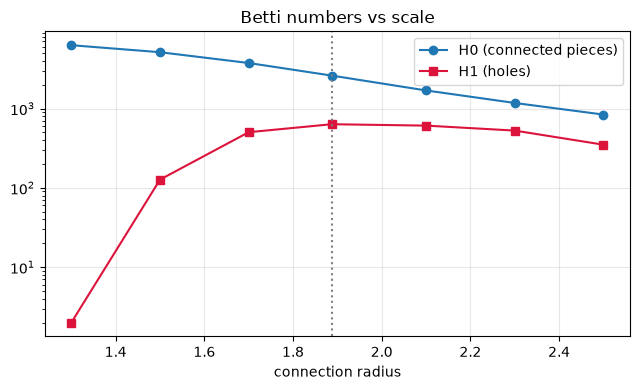

In [42]:
def betti(th,cap=2_200_000):
    Ab=(D<=th)&(~np.eye(n,dtype=bool))
    f1,f2=np.where(np.triu(Ab,1)); Eb=len(f1)
    nc,_=connected_components(csr_matrix(Ab),directed=False)
    g=Eb-n+nc
    eidb={(int(f1[k]),int(f2[k])):k for k in range(Eb)}
    T=[]
    for s in range(0,Eb,20000):
        a,b=f1[s:s+20000],f2[s:s+20000]; com=Ab[a]&Ab[b]
        for r in range(len(a)):
            i,j=int(a[r]),int(b[r])
            for k in np.where(com[r])[0]:
                k=int(k)
                if k>j: T.append((i,j,k))
        if len(T)>cap: return nc,g,None,None
    p={}; rk=0
    for (i,j,k) in T:
        c=(1<<eidb[(i,j)])|(1<<eidb[(i,k)])|(1<<eidb[(j,k)])
        while c:
            lo=c.bit_length()-1
            if lo in p: c^=p[lo]
            else: p[lo]=c; rk+=1; break
    return nc,g,len(T),g-rk

print(f"{'radius':>7s} {'H0 pieces':>10s} {'graph cycles':>13s} {'triangles':>11s} {'H1 holes':>9s}")
res=[]
for th in [1.3,1.5,1.7,THETA,2.1,2.3,2.5]:
    c,g,T,h=betti(th); res.append((th,c,g,T,h))
    print(f"{th:7.2f} {c:10d} {g:13,} {(f'{T:,}' if T else 'too many'):>11s} {(str(h) if h is not None else '-'):>9s}",flush=True)

ok=[r for r in res if r[4] is not None]
plt.figure(figsize=(6.5,4))
plt.plot([r[0] for r in ok],[r[1] for r in ok],"o-",label="H0 (connected pieces)")
plt.plot([r[0] for r in ok],[r[4] for r in ok],"s-",color="crimson",label="H1 (holes)")
plt.axvline(THETA,ls=":",color="gray"); plt.yscale("log"); plt.grid(alpha=.3); plt.legend()
plt.xlabel("connection radius"); plt.title("Betti numbers vs scale"); plt.tight_layout(); plt.show()

## Part X findings

- **15,554 independent cycles in the graph, and 96% of them are filled by triangles.** Only
  **634 are genuine holes** at the sampling scale.
- **The 2-core splits the 1s almost exactly in half**: 50.7% lie on at least one cycle (sheet),
  49.3% are tree-like -- 2,446 isolated and 881 dangling branches.
- **That split is visible.** Sheet 1s average 47.4 ink and sit 1.13 from their nearest neighbour;
  branch 1s 59.3 and 1.70; isolated 1s 70.5 and 2.42. Thin clean strokes live inside the solid
  part of the manifold; heavy and ornate ones dangle off it or float alone. Monotone in all three.
- **The holes do not persist.** H1 rises to 638 at THETA and then falls (609, 527, 350 at radii
  2.1, 2.3, 2.5) -- born from sparse sampling, dying as triangles fill them. No evidence of real
  topology in the space of 1s.
- This also answers the open question about the slant axis: if slant wrapped around, a persistent
  1-dimensional loop would show. It does not, so slant is an **interval**, not a circle.

---
# Part XI — drawing it

## A correction first: the graph is 1-dimensional, the complex is an assumption

Parts IX and X counted triangles and cliques and concluded the structure is up to 12-dimensional.
That needs qualifying. **A graph is a 1-complex** -- vertices and edges, nothing more. The
triangles were not *in* the graph; filling in every triple of mutually-close points is the
**Vietoris-Rips** construction, and it is a modelling choice laid on top of the data.

It is also a generous one. Rips fills a triangle whenever the three points are pairwise within
THETA, which is weaker than their THETA/2-balls actually sharing a point (the Cech condition). So
the 44,731 triangles are an upper bound on what the geometry strictly justifies.

Read the earlier numbers accordingly: *if* you accept Rips, the complex reaches dimension 12. The
graph on its own reaches dimension 1, always, by definition.

## The bridged graph, treated purely as a graph

So: is it a sparse collection of lines, or a dense mesh? The graph answers without any complex
being built on it.

In [43]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree, breadth_first_order

PA=np.vstack([ones,S2]); NA=len(PA); pasq=(PA**2).sum(1)
rows=[];cols=[];vals=[]
for s in range(0,NA,1500):
    ch=PA[s:s+1500]
    dd=np.sqrt(np.maximum((ch**2).sum(1)[:,None]+pasq[None,:]-2*ch@PA.T,0))
    r,c=np.where(dd<=THETA); k=(r+s)!=c
    rows.append(r[k]+s); cols.append(c[k]); vals.append(dd[r[k],c[k]])
rows=np.concatenate(rows); cols=np.concatenate(cols); vals=np.concatenate(vals)
GA=coo_matrix((vals,(rows,cols)),shape=(NA,NA)).tocsr()
ncA,labA=connected_components(GA,directed=False)
EA=len(rows)//2; degA=np.diff(GA.indptr)
print(f"V={NA}  E={EA}  components={ncA}")
print(f"independent cycles  E - V + C = {EA-NA+ncA:,}")
print(f"degree: median {np.median(degA):.0f}  mean {degA.mean():.2f}  max {degA.max()}   (a line has 2)")
print(f"spanning forest needs {NA-ncA:,} edges; the graph has {EA:,}")
print(f"EXCESS edges, each closing a loop: {EA-(NA-ncA):,}  ({100*(EA-(NA-ncA))/EA:.1f}% of all edges)")

print(f"\nplanarity -- Euler bound E <= 3V-6 = {3*NA-6:,};  actual {EA:,}  -> "
      f"{'passes' if EA<=3*NA-6 else 'FAILS the count test'}")
nbrA=[set(GA.indices[GA.indptr[i]:GA.indptr[i+1]].tolist()) for i in range(NA)]
bestA=[0]
def mcA(cand,R=0):
    if not cand: bestA[0]=max(bestA[0],R); return
    if R+len(cand)<=bestA[0]: return
    piv=max(cand,key=lambda v:len(nbrA[v]&cand))
    for v in list(cand-nbrA[piv]):
        mcA(cand&nbrA[v],R+1); cand=cand-{v}
        if R+len(cand)<=bestA[0]: return
for i in np.argsort(degA)[::-1][:700]:
    if degA[i]+1<=bestA[0]: continue
    mcA(nbrA[int(i)],1)
print(f"largest clique: {bestA[0]}  -> contains K5, so by Kuratowski NOT planar")
print("any 2-D drawing must have crossings, and a crossing asserts an adjacency that is not there")

V=12528  E=47060  components=9
independent cycles  E - V + C = 34,541
degree: median 5  mean 7.51  max 69   (a line has 2)
spanning forest needs 12,519 edges; the graph has 47,060
EXCESS edges, each closing a loop: 34,541  (73.4% of all edges)

planarity -- Euler bound E <= 3V-6 = 37,578;  actual 47,060  -> FAILS the count test
largest clique: 19  -> contains K5, so by Kuratowski NOT planar
any 2-D drawing must have crossings, and a crossing asserts an adjacency that is not there


## What the structure is actually made of

A pure line has degree 2 and no triangles. Classify every real 1 by what it sits in.

In [44]:
A11=(D<=THETA)&(~np.eye(n,dtype=bool))
f1,f2=np.where(np.triu(A11,1)); E11=len(f1); deg11=A11.sum(1)
te=np.zeros(E11,np.int32)
for s in range(0,E11,20000):
    a,b=f1[s:s+20000],f2[s:s+20000]; te[s:s+20000]=(A11[a]&A11[b]).sum(1)
tv=np.zeros(n,np.int64); np.add.at(tv,f1,te); np.add.at(tv,f2,te); tv//=2

groups=[("isolated dust (degree 0)", deg11==0),
        ("genuine LINE pieces (deg 1-2, no triangle)", (tv==0)&(deg11>=1)&(deg11<=2)),
        ("triangle-free junctions (deg>=3)", (tv==0)&(deg11>=3)),
        ("SHEET or denser (on >=1 triangle)", tv>0)]
for nm,m in groups:
    print(f"  {nm:44s} {int(m.sum()):5d}  ({100*m.mean():5.1f}%)   mean ink {ones[m].sum(1).mean():5.1f}")
print(f"\n  edges belonging to NO triangle: {int((te==0).sum()):5d} / {E11}  ({100*(te==0).mean():.1f}%)")
print(f"  edges inside at least one triangle: {int((te>0).sum()):5d}  ({100*(te>0).mean():.1f}%)")
print("  -> if this were a collection of lines the second number would be near zero")

  isolated dust (degree 0)                      2446  ( 36.3%)   mean ink  70.5
  genuine LINE pieces (deg 1-2, no triangle)     987  ( 14.6%)   mean ink  60.3
  triangle-free junctions (deg>=3)                80  (  1.2%)   mean ink  59.1
  SHEET or denser (on >=1 triangle)             3229  ( 47.9%)   mean ink  51.1

  edges belonging to NO triangle:  1440 / 19695  (7.3%)
  edges inside at least one triangle: 18255  (92.7%)
  -> if this were a collection of lines the second number would be near zero


## An atlas on coordinates you can name

Not a projection and not an embedding: measure two interpretable quantities **directly from each
image** -- tilt of the principal axis away from vertical, and ink per unit of stroke length --
then grid them and show the most central real 1 in each cell.

Every cell fills. The occupied region in these coordinates is a full rectangle with density
peaking in the middle: this is the traffic-light figure for MNIST.

The honest limit: it is a 2-D **chart** of an ~11-dimensional object. Position, stroke curvature,
length and serifs are integrated out, and each cell holds anywhere from 6 to 257 different 1s.

tilt from vertical: -40 to 14 degrees (0 = upright)
grid 7x11 = 77 cells;  occupied by a real 1: 77;  empty: 0


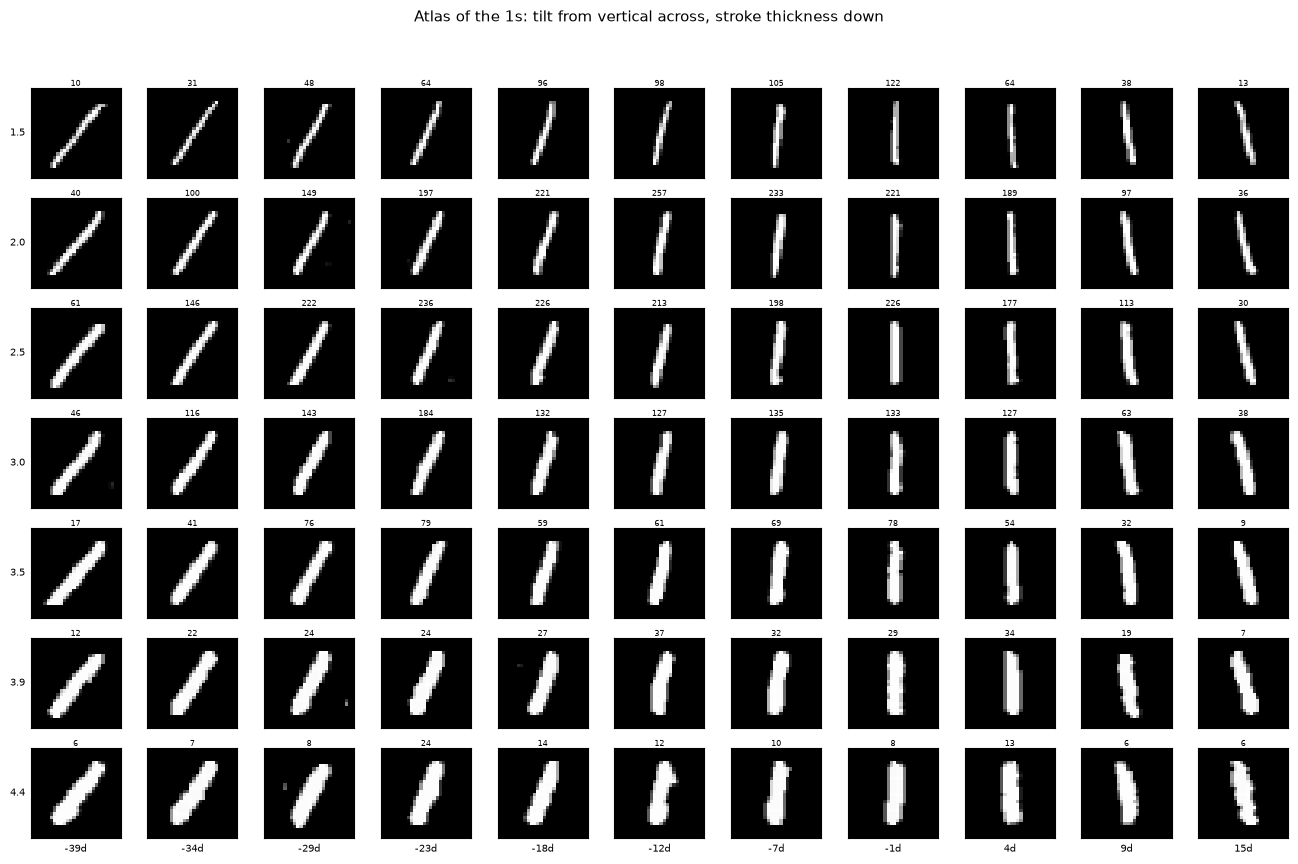

In [45]:
YY,XX=np.mgrid[0:28,0:28]
def moments(I):
    t=I.sum(); cx=(XX*I).sum()/t; cy=(YY*I).sum()/t
    dx,dy=XX-cx,YY-cy
    m20=(dx*dx*I).sum()/t; m02=(dy*dy*I).sum()/t; m11=(dx*dy*I).sum()/t
    w,V=np.linalg.eigh(np.array([[m20,m11],[m11,m02]]))
    vx,vy=V[:,1]; tilt=np.degrees(np.arctan2(vx,vy))
    if tilt>90: tilt-=180
    if tilt<=-90: tilt+=180
    return tilt, t/(4*np.sqrt(max(w[1],1e-9)))
MM=np.array([moments(ones[i].reshape(28,28)) for i in range(n)])
slant,thick=MM[:,0],MM[:,1]
NS,NT=11,7
sb=np.linspace(np.percentile(slant,1),np.percentile(slant,99),NS+1)
tb=np.linspace(np.percentile(thick,1),np.percentile(thick,99),NT+1)
cellv=np.full((NT,NS),-1); cnt=np.zeros((NT,NS),int)
for r in range(NT):
    for c in range(NS):
        m=np.where((slant>=sb[c])&(slant<sb[c+1])&(thick>=tb[r])&(thick<tb[r+1]))[0]
        cnt[r,c]=len(m)
        if len(m): cellv[r,c]=m[np.argmin(D[np.ix_(m,m)].sum(1))]
print(f"tilt from vertical: {np.percentile(slant,2):.0f} to {np.percentile(slant,98):.0f} degrees (0 = upright)")
print(f"grid {NT}x{NS} = {NT*NS} cells;  occupied by a real 1: {int((cellv>=0).sum())};  empty: {int((cellv<0).sum())}")

fig,ax=plt.subplots(NT,NS,figsize=(NS*1.2,NT*1.25))
for r in range(NT):
    for c in range(NS):
        a=ax[r,c]; a.set_xticks([]); a.set_yticks([])
        if cellv[r,c]>=0:
            a.imshow(ones[cellv[r,c]].reshape(28,28),cmap="gray",vmin=0,vmax=1)
            a.set_title(f"{cnt[r,c]}",fontsize=6,pad=1.5)
        else: a.set_facecolor("#eee")
for c in range(NS): ax[NT-1,c].set_xlabel(f"{(sb[c]+sb[c+1])/2:.0f}d",fontsize=7)
for r in range(NT): ax[r,0].set_ylabel(f"{(tb[r]+tb[r+1])/2:.1f}",fontsize=7,rotation=0,ha="right",va="center")
fig.suptitle("Atlas of the 1s: tilt from vertical across, stroke thickness down",fontsize=11)
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()

## A negative result: adding nodes does not make the map more honest

The reasoning was plausible -- a sparse graph inflates geodesic distance because paths zigzag
(median turn 104 degrees), so denser sampling should straighten them. It does not work. The
synthetic nodes do not straighten existing paths; they drag in territory that was previously
unreachable, and the newly-included ornate outliers are harder to flatten than what was there
before. **Completeness and visualisability pull against each other.**

In [46]:
from scipy.sparse.csgraph import dijkstra
def mapstress(P,probe,tag):
    s=(P**2).sum(1)
    Dm=np.sqrt(np.maximum(s[:,None]+s[None,:]-2*P@P.T,0)); np.fill_diagonal(Dm,0)
    W=csr_matrix(np.where((Dm<=2.5)&(~np.eye(len(P),dtype=bool)),Dm,0))
    ncx,labx=connected_components(W,directed=False); gi=np.argmax(np.bincount(labx))
    idx=probe[labx[probe]==gi]
    Gd=dijkstra(W,indices=idx,directed=False)[:,idx]; Gd=(Gd+Gd.T)/2
    ok=np.isfinite(Gd).all(1); Gd=Gd[np.ix_(ok,ok)]; m=len(Gd)
    J=np.eye(m)-np.ones((m,m))/m
    B=-0.5*J@(Gd**2)@J; w,V=np.linalg.eigh(B); o=np.argsort(w)[::-1]
    Y=V[:,o[:2]]*np.sqrt(np.maximum(w[o[:2]],0))
    Ee=np.sqrt(((Y[:,None,:]-Y[None,:,:])**2).sum(2)); iu=np.triu_indices(m,1)
    st=np.sqrt(((Ee[iu]-Gd[iu])**2).sum()/(Gd[iu]**2).sum())
    print(f"  {tag:18s} nodes {len(P):6d} | mapped {m:4d} | 2 axes hold "
          f"{w[o[:2]].sum()/np.maximum(w,0).sum():.1%} | stress {st:.3f}")
probe=np.random.default_rng(0).choice(n,900,replace=False)
mapstress(ones,probe,"real 1s only")
mapstress(np.vstack([ones,S2]),probe,"real + synthetic")

  real 1s only       nodes   6742 | mapped  780 | 2 axes hold 63.7% | stress 0.168


  real + synthetic   nodes  12528 | mapped  899 | 2 axes hold 57.1% | stress 0.257


## The space of 1s as a collection of lines

To make "a collection of lines" literally true, prune the graph to its **minimum spanning tree**:
keep only the shortest edge into each node. A tree is planar by definition, so this draws in 2-D
with **zero crossings** -- every node, every edge, no overlaps, no projection.

Radius is distance from the root *along the tree*. Angle is arbitrary, allocated by subtree size.

What it costs: 73% of the edges. Where the tree says "not adjacent", many of those pairs were.
And tree distance badly overstates real distance -- the deepest tip sits ~237 units of path from
the centre while the entire class is only 13.9 units across, which is the 104-degree zigzag
compounding along a path.

giant component 12,465 nodes;  MST keeps 12,464 of 46,922 edges (73% discarded)
deepest tip sits 237.4 of tree-path from the root;  class diameter is 13.9


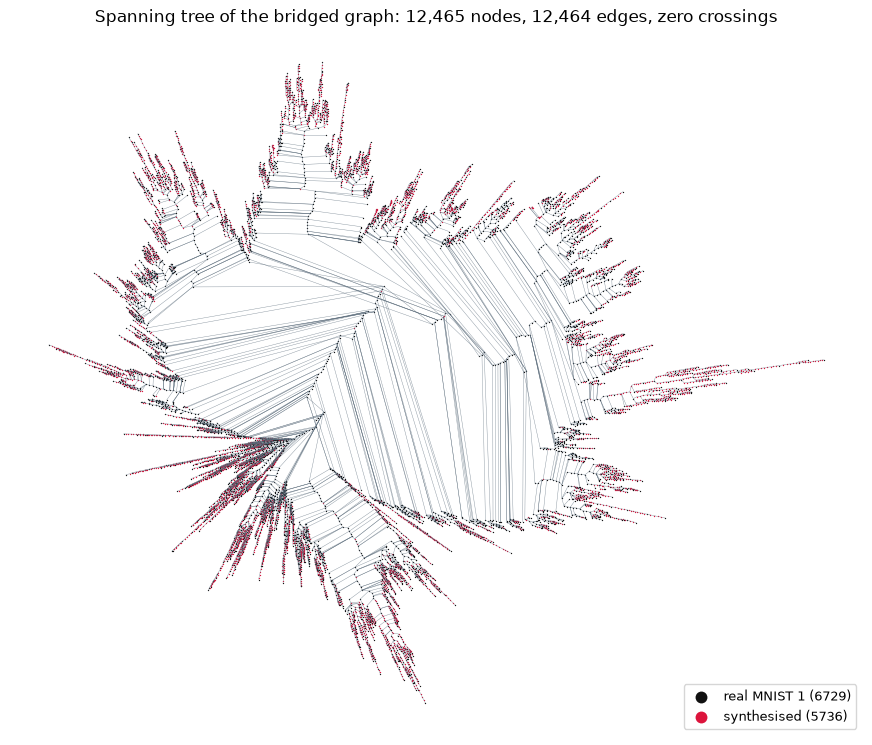

In [47]:
gi=np.argmax(np.bincount(labA)); keep=np.where(labA==gi)[0]
Gg=GA[keep][:,keep]; Mk=len(keep)
T=minimum_spanning_tree(Gg); T=T+T.T
print(f"giant component {Mk:,} nodes;  MST keeps {T.nnz//2:,} of {Gg.nnz//2:,} edges "
      f"({100*(1-(T.nnz//2)/(Gg.nnz//2)):.0f}% discarded)")

degG=np.diff(Gg.indptr); root=int(np.argmax(degG))
order,pred=breadth_first_order(T,root,directed=False)
Tc=T.tocsr(); child={i:[] for i in range(Mk)}
for v in order[1:]: child[pred[v]].append(v)
leaves=np.ones(Mk)
for v in order[::-1]:
    if child[v]: leaves[v]=sum(leaves[c] for c in child[v])
rad=np.zeros(Mk); ang=np.zeros(Mk); span=np.zeros(Mk); span[root]=2*np.pi
for v in order:
    if v!=root: rad[v]=rad[pred[v]]+Tc[pred[v],v]
    if child[v]:
        acc=ang[v]-span[v]/2; tot=sum(leaves[c] for c in child[v])
        for c in child[v]:
            w_=span[v]*leaves[c]/tot; ang[c]=acc+w_/2; span[c]=w_; acc+=w_
xs,ys=rad*np.cos(ang),rad*np.sin(ang)
print(f"deepest tip sits {rad.max():.1f} of tree-path from the root;  class diameter is {D.max():.1f}")

from matplotlib.collections import LineCollection
Tco=T.tocoo()
segs=[((xs[a],ys[a]),(xs[b],ys[b])) for a,b in zip(Tco.row,Tco.col) if a<b]
isyn=keep>=n
fig,ax=plt.subplots(figsize=(11,11))
ax.add_collection(LineCollection(segs,colors="#5a6b7a",linewidths=0.3,alpha=0.75))
ax.scatter(xs[~isyn],ys[~isyn],s=0.9,c="#111",linewidths=0,label=f"real MNIST 1 ({int((~isyn).sum())})")
ax.scatter(xs[isyn],ys[isyn],s=0.9,c="crimson",linewidths=0,label=f"synthesised ({int(isyn.sum())})")
ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="lower right",markerscale=9,fontsize=9)
ax.set_title(f"Spanning tree of the bridged graph: {Mk:,} nodes, {T.nnz//2:,} edges, zero crossings",fontsize=12)
plt.show()

## Part XI findings

- **The graph is 1-dimensional; the 12-dimensional simplex was a Rips assumption.** Worth keeping
  straight when reading Parts IX and X. Rips also over-fills relative to Cech, so 44,731 is an
  upper bound on the triangles the geometry strictly supports.
- **But the graph is not line-shaped.** Mean degree 7.5, a 19-clique, and 73% of its edges are
  excess beyond what connectivity needs. **93% of edges are faces of a triangle**; in a collection
  of lines that number would be near zero.
- **Only 14.6% of real 1s are genuinely line-like** (degree 1-2, no triangle). 36% are isolated
  dust, 48% sit on triangles. The composition is dust and sheet, with very little line in between.
- **Not planar** -- it contains K5 via the 19-clique, and it fails the Euler edge bound outright
  (47,060 > 37,578). Any 2-D drawing of the full graph must cross edges, and a crossing asserts an
  adjacency that does not exist.
- **Pruning to a spanning tree makes the idea work.** 12,464 edges, planar, zero crossings, every
  node drawn. Cost: 73% of edges, arbitrary angles, and tree distance inflated ~17x over
  straight-line distance.
- **Adding nodes does not improve the map** (stress 0.168 -> 0.257). Completeness and
  visualisability trade off.

Five charts now exist, each exact about one thing and honest about the rest:

| chart | exact about | discards |
|---|---|---|
| tilt x thickness atlas | two nameable coordinates | the other nine dimensions |
| Mapper skeleton | connectivity of clusters | all geometry |
| geodesic map | relative distance (stress 0.16) | 38% of the geometry |
| dimension vs scale | full-dimensional shape signature | any notion of where |
| spanning tree | topology, zero crossings | 73% of edges, all angles |

That is what an atlas is, in the technical sense: a manifold is *defined* as a collection of
overlapping partial charts, because no single chart ever suffices.

---
# Part XII — three things the bulge figures showed but did not explain

Part XI held A and B fixed and varied the arc between them. Three points pin a quadratic, so
that whole family is parameterised by one vector — where the halfway point sits — split into a
**size** (`h`) and a **direction** (`u`). Staring at `figures/bulge_size.png` and
`figures/bulge_direction.png` raises three questions that the figures do not answer. All three
turn out to be measurable, and each one says something about the space rather than about the
arc.

1. At high bulge the strokes look like **something took bites out of their sides**.
2. The strokes **barely rotate until the final frame**, then snap.
3. At **180°** — the exact opposite of the manifold's own bulge direction — the speckle
   disappears and you get a clean **X**.

## 1. The bites are negative ink, and the cube is the real state space

The bites are pixels the arithmetic sent **below zero**. `imshow` clips them to black, and
because they sit along the flanks of the stroke the clipped region reads as a bite.

This matters more than a rendering detail. The state space is not $\mathbb{R}^{784}$ — every
coordinate is an intensity, so it is the **unit cube** $[0,1]^{784}$. A straight line between
two points of a convex set stays inside it, which is why `h = 0` never clips. A curved arc has
no such guarantee, and past `h ≈ 1 × h0` it walks straight out through the wall.

The real manifold route clips **exactly zero** ink at every frame, because every frame is a
real (or warp-of-real) image. That is a constraint the arc family does not know about and
cannot be made to satisfy by choosing `h` better.

→ `figures/bulge_bites.png`

In [ ]:
import numpy as np, paths
from make_bulge_figures import setup, tilt

ones_b, D_b, theta_b, ai, bi, route_b, near = setup()
A, B = ones_b[ai], ones_b[bi]
s_b = paths.arclength_param(route_b); mid = (A + B) / 2
gm = np.array([np.interp(0.5, s_b, route_b[:, j]) for j in range(784)])
h0, u0 = paths.bulge_of(A, B, gm)
e = (B - A) / np.linalg.norm(B - A)
ts = np.linspace(0, 1, 9)
arc = lambda f: paths.arc_through(A, B, mid + f * h0 * u0, ts)
real = np.array([[np.interp(v, s_b, route_b[:, j]) for j in range(784)] for v in ts])
print(f"h0 = {h0:.2f}   chord = {D_b[ai,bi]:.2f}   THETA = {theta_b:.2f}\n")

print("1. HOW FAR OUTSIDE THE UNIT CUBE [0,1]^784 EACH ARC GOES (mean over frames)")
print(f"  {'bulge':>10} {'ink < 0':>9} {'px < 0':>8} {'ink > 1':>9} {'clipped / shown':>16}")
for f in [0, 0.5, 1, 1.5, 2.5, 4, 6, 10]:
    F = arc(f); lost = -np.minimum(F, 0) + np.maximum(F - 1, 0)
    print(f"  {f:8g}x0 {-np.minimum(F,0).sum(1).mean():9.1f} {(F<-1e-9).sum(1).mean():8.1f} "
          f"{np.maximum(F-1,0).sum(1).mean():9.1f} "
          f"{(lost.sum(1)/np.clip(F,0,1).sum(1)).mean():16.2f}")
print(f"  {'real route':>10} {-np.minimum(real,0).sum(1).mean():9.1f} "
      f"{(real<-1e-9).sum(1).mean():8.1f} {np.maximum(real-1,0).sum(1).mean():9.1f} {0.0:16.2f}")

## 2. The stall is not in the timing — it is provable that it cannot be

The obvious guess is that the arc is badly parameterised: that a big bulge makes it linger near
A and then rush to B. It does not, and the reason is exact rather than empirical.

The control point that sends a quadratic through `M` at `t = 0.5` is `P1 = 2M − (A+B)/2`. We
took `M = (A+B)/2 + h·u` with `u ⊥ (B−A)`, so `P1`'s component **along the chord is exactly the
midpoint**. Substituting into the Bézier, progress along the chord is

$$(1-t)^2\cdot 0 \;+\; 2t(1-t)\cdot \tfrac12 \;+\; t^2\cdot 1 \;=\; t$$

— perfectly uniform, for every `h`. All the curves coincide, which the figure confirms to
machine precision.

So the stall is real but it is a *rendering* effect in the honest sense: the perpendicular
excursion is `2t(1-t)·h`, which at `h = 6 × h0` reaches **34 units — four times the entire
chord**. What you are looking at for seven of the nine frames is the bulge, whose own tilt is
fixed near −13.5°. Only at the last step does `2t(1-t)` collapse and let B through.

**And the follow-up was right.** The same step is much further from B under a harsher bulge:
at `t = 0.88`, distance to B is 1.1 at `h = 0`, 2.7 at `1×`, 6.3 at `2.5×`, **15.0 at `6×`**.
The earlier guess — that untilted 1s are somehow close to opposite-tilt 1s — is not what is
happening; the frames are not near B at all.

→ `figures/bulge_rotation.png`

In [ ]:
print("2a. MEASURED TILT PER FRAME (degrees) -- the stall")
print("       " + " ".join(f"t={t:.2f}" for t in ts))
print(" real  " + " ".join(f"{tilt(np.clip(x,0,1).reshape(28,28)):+6.1f}" for x in real))
for f in [0, 1, 2.5, 6]:
    print(f" {f:4g}x  " + " ".join(f"{tilt(np.clip(x,0,1).reshape(28,28)):+6.1f}" for x in arc(f)))

print("\n2b. PROGRESS ALONG THE CHORD -- identical for every bulge, exactly t")
for f in [0, 1, 2.5, 6]:
    print(f" {f:4g}x  " + " ".join(f"{np.dot(x-A,e)/np.linalg.norm(B-A):6.3f}" for x in arc(f)))

print("\n2c. PERPENDICULAR EXCURSION -- this is what you are actually looking at")
for f in [0, 1, 2.5, 6]:
    print(f" {f:4g}x  " + " ".join(f"{np.linalg.norm((x-A)-np.dot(x-A,e)*e):6.2f}" for x in arc(f)))

print("\n2d. DISTANCE TO B -- yes, the same step differs by bulge")
for f in [0, 1, 2.5, 6]:
    print(f" {f:4g}x  " + " ".join(f"{np.linalg.norm(x-B):6.2f}" for x in arc(f)))

## 3. The X is the cross-fade with the contrast turned up, and the axis is the only clean line

Walk the bulge direction once around the circle at constant length and count **connected pieces
of ink** in the halfway image. Real 1s average 1.06 pieces. The result is stark:

| bearing | pieces | distance to nearest real 1 |
|---|---|---|
| 0° (the manifold's own direction) | **1** | 1.17 |
| 180° (its exact negation) | **1** | 5.75 |
| everything else | 13–78 | 3.4–6.0 |

Only two narrow windows, each about ±20° wide, produce a connected stroke. Drawing 200 random
bearings from the **full 782-dimensional** perpendicular space, not one fell below 53 pieces —
so on the sphere, rather than on this one chosen circle, the good set has essentially no measure
at all.

**Why the opposite direction is clean, and why it is an X.** The midpoint `(A+B)/2` is *already*
a faint X — that is what cross-fading a left-leaning 1 with a right-leaning one produces. The
manifold's direction `u0` points partly *away* from it (`cos(u0, mid) = −0.363`), so moving along
`+u0` cancels the ghost and leaves a single upright stroke. Moving along `−u0` does the reverse:
it **reinforces** the ghost. Of the midpoint's 99 mid-grey stroke pixels, 58 get pushed above
0.8 and 9 below 0, which is a genuine de-greying, not a clipping artifact.

So the intuition that there is "some shared non-speckle dimension" is exactly right, and it can
be named: it is $\mathrm{span}\{A, B\}$, a **2-plane**. The 180° image is 81% inside it, and
**98.1% of its ink sits on pixels that A or B already touched**. It cannot speckle, because a
vector in that plane can only draw where the two original strokes drew. Every other bearing has
a large component orthogonal to the plane, and orthogonal directions in 784-D scatter ink onto
pixels no stroke ever visited — which is precisely what confetti is.

The reason 180° is still **5.75** from any real 1 is not that it is ugly. It is crisp. It is
simply that nobody writes both strokes at once.

→ `figures/bulge_axis.png`

In [ ]:
from scipy.ndimage import label
blobs = lambda i: int(label(np.clip(i,0,1).reshape(28,28) > 0.2)[1])

rng = np.random.default_rng(1)
v = rng.normal(size=784); v -= np.dot(v,e)*e; v -= np.dot(v,u0)*u0; v /= np.linalg.norm(v)
half = lambda p: paths.arc_through(A, B, mid + h0*(np.cos(np.radians(p))*u0
                                                  + np.sin(np.radians(p))*v), [0.5])[0]
Q, _ = np.linalg.qr(np.stack([A, B], 1))
sAB = np.where((A > 0.2) | (B > 0.2))[0]
inplane = lambda i: np.linalg.norm(Q @ (Q.T @ i)) / np.linalg.norm(i)
onstroke = lambda i: np.clip(i,0,1)[sAB].sum() / np.clip(i,0,1).sum()

print("3a. ONE LAP AROUND THE CIRCLE AT CONSTANT BULGE")
print(f"  {'angle':>6} {'pieces':>7} {'dist':>6} {'in span(A,B)':>13} {'ink on A/B pixels':>18}")
for p in range(0, 360, 45):
    i = half(p)
    print(f"  {p:5d}° {blobs(i):7d} {near([i])[0]:6.2f} {100*inplane(i):12.0f}% {100*onstroke(i):17.1f}%")
for nm, i in [("real gm", gm), ("midpoint", mid)]:
    print(f"  {nm:>6} {blobs(i):7d} {near([i])[0]:6.2f} {100*inplane(i):12.0f}% {100*onstroke(i):17.1f}%")
print(f"  {'real 1s':>6} {np.mean([blobs(o) for o in ones_b[:2000]]):7.2f}")

rb = []
for _ in range(200):
    w = rng.normal(size=784); w -= np.dot(w,e)*e; w /= np.linalg.norm(w)
    rb.append(blobs(paths.arc_through(A, B, mid + h0*w, [0.5])[0]))
rb = np.array(rb)
print(f"\n  CONTROL, 200 random bearings in the full 782-D perpendicular space:")
print(f"    pieces  min {rb.min()}  median {np.median(rb):.0f}  max {rb.max()}   "
      f"none below 3: {(rb < 3).sum()}")

print("\n3b. WHERE THE MIDPOINT'S MID-GREY PIXELS GO AT 180 DEGREES")
m180 = mid - h0*u0; st = np.where(mid > 0.05)[0]
for nm, img in [("midpoint", mid), ("180 deg ", m180)]:
    x = img[st]
    print(f"  {nm}: of {len(st)} stroke px -- below 0: {int((x<0).sum()):3d}   "
          f"0-0.2: {int(((x>=0)&(x<0.2)).sum()):3d}   0.2-0.8: {int(((x>=0.2)&(x<=0.8)).sum()):3d}   "
          f"above 0.8: {int((x>0.8).sum()):3d}")
print(f"  cos(u0, midpoint direction) = {np.dot(u0, mid/np.linalg.norm(mid)):+.3f}"
      f"   <- negative, so -u0 reinforces the ghost")

## Part XII findings

- **The state space is the unit cube $[0,1]^{784}$, not $\mathbb{R}^{784}$, and that is a real
  constraint.** The "bites" are ink driven below zero: 37 pixels per frame at `h = 1 × h0`,
  83 at `6×`. At `6×` the display throws away roughly **2.8× more mass than it shows**. The real
  manifold route clips exactly nothing, ever. Straight lines are safe because the cube is
  convex; arcs are not.
- **The stall is not a parameterisation problem, and cannot be fixed by re-timing.** Progress
  along the chord is *exactly* `t` for every bulge — provable from the Bézier, since the control
  point's along-chord component is exactly the midpoint. The stall is that the perpendicular
  excursion `2t(1−t)h` reaches 34 units at `6×`, four times the whole chord, so the bulge is what
  you see until it deflates.
- **The follow-up guess was the right one.** The same step is much further from B under a harsher
  bulge (1.1 → 15.0 at `t = 0.88`). Frames in the stall are not near opposite-tilt 1s; they are
  not near anything.
- **Exactly one axis on the perpendicular sphere draws a connected stroke: `±u0`.** 1 piece at
  both ends, 13–78 pieces everywhere else, and over 200 random bearings from the full 782
  dimensions the best was 53 pieces.
- **The X is the cross-fade ghost reinforced, not new structure.** 81% of it lies in
  $\mathrm{span}\{A,B\}$ and 98.1% of its ink sits on pixels A or B already touched — it
  literally cannot speckle. It is crisp and it is 5.75 from any real 1, which separates two
  things the ghosting metric conflates: **being sharp** and **being a 1**.
- **Why this is worth having.** All three questions started as "that looks odd" and each one
  resolved into a property of the space in its original coordinates — a wall (the cube), a
  quantity that dominates the view (the excursion), and a 2-plane (`span{A,B}`) that is the only
  place a two-image family can draw without confetti. None of it needed a projection.

---
# Part XIII — an exact equation for a toy 1

Real 1s have no known formula. This part asks what one would even *look like*, using a toy
where the answer is knowable: binary pixels, and a "1" is a vertical bar `w` pixels wide filling
the middle 80% of the rows, **at any horizontal position**.

**One fixed image** is easy: compare x against the template a, pixel by pixel,
$E(x) = \sum_i (x_i - a_i)^2$, which is zero only when x = a.

**A sliding bar** has no single template. So the image gets compared **against itself**:

$$E(x) = \underbrace{\sum_{r\notin\text{band}}\sum_c x_{r,c}}_{A} + \underbrace{\sum_{r,c}(x_{r,c}-x_{r+1,c})^2}_{B} + \underbrace{\Big(\sum_c x_{r_0,c}-w\Big)^2}_{C} + \underbrace{\sum_{|i-j|\ge w} x_{r_0,i}\,x_{r_0,j}}_{D}$$

- **A**: nothing lit outside the band.  **B**: every band row is a copy of the one below.
- **C**: the top band row has exactly w lit.  **D**: no two of them are w or more apart, so
  they sit side by side as one block.

Every term is a count or a square, so it can't go negative, and the total is 0 only if all
four are. Nothing in the equation says *which* column. That missing term is what lets the bar
slide. → `figures/equation_terms.png`

**Can it be done one pixel at a time?** No, and this is a proof, not a failed search. A
per-pixel term on an on/off pixel can take only two values, so any sum of them is a weighted
sum, c + Σ wᵢxᵢ. And bar₂ − bar₃ + bar₄ is itself a binary image, the *split stroke*, so any
weighted sum that is zero on the three bars is forced to be zero on the split too. It's the
"far-apart pixels sum to a middle" objection, stated exactly. **Pairs are enough**: every term
above has degree ≤ 2 (C's square expands into pairs). Here the minimum number of pixels a term
has to look at together is exactly 2. → `figures/equation_per_pixel.png`

**Is every term needed?** Delete each one in turn and enumerate every 5×5 image: dropping A or
B lets in 4,092 non-1s each, dropping C or D lets in 6. So none of the four can be removed. That
makes the set *minimal* (nothing removable). It doesn't prove *minimum* (a cleverer set could
still be smaller). The terms also lean on each other: B makes every band row a copy of row 1,
which is the only reason C and D can check row 1 alone. → `figures/equation_necessity.png`

This is the same fact as the Part VII finding that per-pixel marginals carry almost no
information. The valid set isn't a product of per-pixel choices, so no per-pixel rule can
describe it.

In [ ]:
import numpy as np
h = w_ = 5; band = [1, 2, 3]; wd = 2; nb = 25
V = []
for c in range(w_ - wd + 1):
    im = np.zeros((h, w_), int); im[1:4, c:c+wd] = 1; V.append(im)
V = np.array(V)

# the best per-pixel equation: a random member of the family of weighted sums zero on V
M = np.hstack([np.ones((len(V), 1)), V.reshape(len(V), -1)])
null = np.linalg.svd(M)[2][len(V):]
coef = np.random.default_rng(0).normal(size=len(null)) @ null
split = V[0] - V[1] + V[2]
print("split = bar0 - bar1 + bar2 (binary!):"); print(split[1:4])
print(f"every weighted sum that is 0 on the bars, on the split: max |E| = "
      f"{np.abs(null @ np.concatenate([[1], split.ravel()])).max():.1e}\n")

lin = pair = 0
for st in range(0, 1 << nb, 1 << 20):
    n = np.arange(st, min(st + (1 << 20), 1 << nb), dtype=np.uint32)
    X = np.unpackbits(n.view(np.uint8).reshape(-1, 4)[:, ::-1], axis=1)[:, -nb:]
    X = X.reshape(-1, h, w_).astype(np.int16)
    lin += (np.abs(coef[0] + X.reshape(len(X), -1) @ coef[1:]) < 1e-9).sum()
    out = [r for r in range(h) if r not in band]
    E2 = (X[:, out].sum((1, 2)) + ((X[:, band[:-1]] - X[:, band[1:]])**2).sum((1, 2))
          + (X[:, 1].sum(1) - wd)**2
          + sum(X[:, 1, i] * X[:, 1, j] for i in range(w_) for j in range(i + wd, w_)))
    pair += (E2 == 0).sum()
print(f"all 2^25 = {1<<nb:,} binary 5x5 images checked")
print(f"  valid images                      : {len(V)}")
print(f"  best per-pixel equation accepts   : {lin}")
print(f"  pairwise equation accepts         : {pair}")

## The smallest possible equation, found by search

"Fewest terms" can be gamed, because any sum can be bundled into one term. The honest measure
is **monomials**. On on/off pixels every function has exactly one expansion as a constant plus
single pixels xᵢ plus pairs xᵢ·xⱼ plus triples and so on (since x² = x, nothing else can
appear). Size is the number of monomials with a nonzero coefficient.

`sparsest_equation.py` searches for the equation with the fewest monomials that is exactly 0 on
every valid bar and at least 1 on every other image. That's a mixed-integer program: one
coefficient per candidate monomial, one yes/no switch for whether it's used, and minimise the
switches. Among the equations tied for fewest, a second pass picks the one with the smallest
coefficients, because there are several ties and the solver otherwise returns an arbitrary one.

**4×4 grid, all 65,536 images as constraints: proven minimum 18 monomials, against 27 for the
hand-built E.** Pixels-only (degree 1) is infeasible, as proven earlier. Allowing triples as
well only gets it to 17.

The coefficient cap made no difference (18 at 8, 64 and 1000). The answer, with every
coefficient ±1:

$$E^*(x) = 2 \;+\; \sum_{\text{outside band}} x \;-\; \sum_{c} x_{1,c}\,x_{2,c} \;+\; \sum_{\text{some } |i-j|\ge 2} x_{1,i}\,x_{2,j}$$

It **thinks in columns rather than rows.** Start at 2 and subtract 1 for every *complete column*
(lit in both band rows); a valid bar has exactly two, so it lands at 0. Add 1 for ink outside
the band, and 1 for a top pixel and a bottom pixel lit 2+ columns apart, a diagonal too long to
belong to one bar. Our E needed B (rows copy) and C (count = 2) and then squared C, which is
what multiplied the terms. The optimiser folds "rows agree" and "exactly two" into one move:
count complete columns and *reward* them. Negative coefficients are what make that possible. A
sum of squares can only ever penalise.

Five diagonal pairs suffice, not all six: the search found that one of them is never needed.

**5×5 (the grid from the earlier figures): proven minimum 32, against 46 hand-built.** Too many
images to hand the solver directly (33.5M), but the outside-band pixels split off *exactly*:
each needs a monomial of its own (one containing a second outside pixel stays 0 when only one
is lit), and blanking the outside rows of any solution leaves a valid band-only equation. So
minimum = band minimum + one per outside pixel = 22 + 10, and the band alone has only 32,768
images, all of which go in as constraints.

The column idea survives, but a *pair* can no longer see a whole 3-pixel column. So each column
is checked on just two of its three rows (−2), each bar position gets one −1 link between its two
columns, and every valid bar collects 2 + 2 + 1 = 5 against a constant of 5. It isn't
left–right symmetric, and it's one of several tied answers. The clean ±1 structure of 4×4 is
gone. Growth so far: 18 → 32 minimum against 27 → 46 hand-built, roughly the same ~30% saving.
→ `figures/equation_sparsest.png`

In [ ]:
import json, numpy as np
import sparsest_equation as se
sol = json.load(open("figures/sparsest_solutions.json"))["4x4"]
terms = [(tuple(m), c) for m, c in sol["sparsest"]]
X = se.images(16, 0, 1 << 16)
V = se.valid_set(4, 4, [1, 2], 2)
isv = (X[:, None, :] == V[None]).all(2).any(1)
val = se.evaluate(terms, X)
print(f"{len(terms)} monomials (proven minimum: {sol['optimal']})")
print(f"on the {isv.sum()} valid images: max |E*| = {np.abs(val[isv]).max():.1e}")
print(f"on the other {(~isv).sum():,}:     min E*   = {val[~isv].min():.3f}\n")
for m, c in sorted(terms, key=lambda t: (len(t[0]), t[0])):
    print(f"  {c:+.0f}  " + ("1" if not m else " * ".join(f"x[{i//4},{i%4}]" for i in m)))

---
# Part XIV — a ladder of explainable equations: move, size, tilt

Part XIII wrote one exact equation for one freedom. This part climbs a ladder of freedoms,
keeping to three rules: every image is on/off, a **generator** *defines* what counts as valid
(no MNIST involved), and E(x) must be a **sum of named checks**, each a plain sentence that
returns a non-negative violation count. The target on every rung: E(x) = 0 exactly when the
generator can draw x. Code: `equation_ladder.py`.

| rung | generator knobs | valid images (10×10) | checks |
|---|---|---|---|
| MOVE | top row, left column | 27 | 6 |
| SIZE | + height 5–10, width 1–3 | 567 | 6 (two bounds widened) |
| TILT | + lean up to 23°, still straight | 16,233 | 8 |

**Tilt on a pixel grid.** A leaning stroke is a staircase: row k starts at s₀ + ⌊a·k + b⌋. Read
it as a list of steps (0 = same column, 1 = one over). "No row shifts sideways" becomes three
checks:
- **never steps both left and right**: a line can't change direction;
- **equal stretches step equally (±1)**: a real line spreads its steps evenly, so any two
  stretches of the same length differ by at most one step. This is the one check that compares
  distant parts of the stroke, and it's what rejects a *bend*;
- **leans no more than 23°**: no stretch of L rows steps more than ⌊0.42·L⌋ + 1 times.

The second of these is a known result in digital geometry: a finite staircase is a digitised
straight line exactly when it is *balanced* (Sturmian words).

**Where does 23° end?** This was the worry about continuous knobs. On a grid the boundary is
sharp and countable: a slope of 0.42 per row with one pixel of rounding slack. It's arbitrary
only in the sense that we chose 23°. Once chosen, every staircase is either in or out.

**Verification.**
- **Staircases.** Every one with 4–9 steps drawn from −1, 0, 1 (29,484 of them) was compared
  against an exact solver that asks whether a line of lean ≤ 23° draws it. Disagreements: 0.
- **Single-pixel changes.** Every one of every valid image (2,700 / 56,700 / 1,623,300 per
  rung) was checked for E = 0 against "the generator can draw it". Disagreements: 0.
- **Why that is complete.** If the first five checks pass, the image is a block of rows, each
  one solid run of the same width 1–3. So it is fully described by its staircase, and the
  staircases were checked exhaustively.
- **Nothing is spare.** Deleting any one lean check lets through 512, 120 or 310 non-straight
  staircases.
- **Connectivity comes free.** Every valid tilted 1 is one piece (touching diagonally counts),
  so a "no speckle / one component" check would be redundant here.

A bug worth recording: the first run of the exact solver called (−1, 0, 0, 1) straight.
"Strictly below the next pixel" had been written with a margin of 10⁻⁹, smaller than the LP
solver's own tolerance of 10⁻⁷, so strict became non-strict. The margin is now 10⁻⁴, still far
below the nearest slope breakpoint (3/7 = 0.4286).

→ `figures/ladder_rungs.png`, `ladder_checks.png`, `ladder_lean.png`

**Are pixel-weight equations unreadable?** Only in a bad basis. For the sliding bar there is a
92-dimensional space of weighted-sum equations true on every valid image. A solver's basis puts
weights on a median of 85 of 100 pixels. The hand-written A, B, C span 91 of those same 92
equations, using 1, 2 and 10 weights. The computer found the 92nd: the alternating sum
+x₀ − x₁ + x₂ − … along row 1 ("as many lit pixels in even columns as in odd"). It rejects
splits with an even gap and misses odd gaps. That is exactly half of "the two pixels touch",
and the gap-of-3 it misses is the split stroke Part XIII proved no weighted sum can reject.
Readability is a property of the basis, and sparsity is what makes it readable.
→ `figures/readable_equations.png`

In [ ]:
import itertools, time, numpy as np
import equation_ladder as EL

t0 = time.time()
lean = [EL.leans_one_way, EL.leans_evenly, EL.lean_at_most()]
def staircase(word):
    rel = np.concatenate([[0], np.cumsum(word)]); return EL.draw(0, len(word) + 1, 1, -rel.min() + rel)
tot = bad = 0
for n in range(4, 10):
    for word in itertools.product((-1, 0, 1), repeat=n):
        tot += 1
        bad += EL.is_straight(word) != (sum(c(staircase(word)) for c in lean) == 0)
print(f"staircases checked against the exact solver: {tot:,}   disagreements: {bad}   ({time.time()-t0:.0f}s)")

rng = np.random.default_rng(0)
for rung in EL.RUNGS:
    V = EL.valid_set(rung); imgs = [np.frombuffer(b, np.int8).reshape(10, 10) for b in V]
    sample = imgs if len(imgs) < 2000 else [imgs[i] for i in rng.choice(len(imgs), 1000, replace=False)]
    dis = 0
    for x in sample:
        for i in range(100):
            y = x.copy().ravel(); y[i] ^= 1; y = y.reshape(10, 10)
            dis += (EL.E(y, rung) == 0) != (y.tobytes() in V)
    print(f"{rung:5s} valid images {len(V):6,d}   E=0 on all: {all(EL.E(x, rung) == 0 for x in imgs)}"
          f"   single-pixel changes checked: {100*len(sample):,}   disagreements: {dis}")

---
# Part XV — tracing the knobs from the data alone

The reverse of Part XIV. Pretend the generator is lost: all we have is the **complete** list of
valid images as 0/1 coordinates. Can the knobs (the dimension, *and* which lines the cloud
traces) be recovered from the coordinates alone? Code: `trace_structure.py`.

**Straight lines don't work.** PCA needs 13 / 37 / 63 directions to cover 95% of the variance
of clouds with 2 / 4 / 6 knobs. Sliding a bar traces a tightly curled curve in pixel space, not
a straight line.

**The method: trace the cloud's own wiring.**
1. **Steps.** Join two images if they share at least one lit coordinate and no third image is
   closer to both (the relative-neighbourhood rule). There's no distance threshold. The
   shared-ink rule is needed because *distance saturates*: two bars that don't overlap are
   always 32 apart, however far apart they sit, so without it far pairs look like single steps.
   (The first attempt, "nothing lies exactly between them", failed for exactly this reason:
   31 "knobs" on the move rung.)
2. **Cuts.** If the step graph is a *partial cube* (it embeds exactly in a hypercube), every
   step crosses exactly one yes/no threshold. For example: "is the left edge past column 4?"
3. **Axes.** Thresholds belonging to one knob are nested, like a chain of notches along a line.
   Eppstein's theorem gives the *minimum* number of integer axes: #cuts − (maximum matching of
   chainable cuts). Each chain is one traced line, and a point's position along it is that
   knob's value.

| rung | images | steps | partial cube | cuts | **axes recovered** | true knobs |
|---|---|---|---|---|---|---|
| MOVE | 27 | 42 | yes | 10 | **2** (left edge, top edge; corr 1.000) | 2 |
| SIZE | 567 | 1,524 | yes | 28 | **4** (top, bottom, left, right edges; corr 0.98–0.995) | 4 |
| TILT | 16,233 | 214,860 | **no** | — | — | 6 |

Every recovered coordinate system reproduces every step distance exactly.

**Why SIZE matches at 0.98, not 1.** At the edges of the range the height limit couples the
edges: top = 5 forces bottom = 9, so "top ≥ 5" and "bottom ≥ 9" are the *same* set of images,
and the matching may file that threshold under either axis. So the **number** of knobs is a
property of the data, while **which** knob a boundary threshold belongs to is a free choice.
Notice also that the data picked *edges* (top/bottom/left/right) rather than the generator's
(top, height, left, width). It's an equivalent parametrisation, and the more local one.

**Why TILT breaks.** Its step graph has 402,228 triangles, three valid 1s each one step from the
other two, which is impossible in any grid of integer knobs. Smallest example: an upright
1-wide bar, the same bar with its bottom pixel leaned one column (2 pixels), and the 2-wide bar
(5 pixels from each). Leaning is *part of the way* to widening. On a pixel grid the two moves
share pixels, so they aren't independent directions. The local count of mutually commuting
moves ranges from 3 to 32 (median 11) instead of settling on 6. Tilt with on/off pixels shatters
into many small single-row shears. The smooth knobs (slope, offset) only exist once in-between
grey values are allowed.

→ `figures/traced_axes.png`, `figures/traced_tilt.png`

In [ ]:
import numpy as np, time
import equation_ladder as EL, trace_structure as TS
for rung, cap in [("move", 34), ("size", 24)]:
    t0 = time.time()
    V = np.array([np.frombuffer(b, np.int8) for b in sorted(EL.valid_set(rung))])
    X = V - V.mean(0); s = np.linalg.svd(X.astype(float), compute_uv=False); v = s**2 / (s**2).sum()
    R = TS.lattice_axes(V, TS.elementary_graph(V, cap))
    print(f"{rung.upper():5s} {len(V):4d} images | PCA dims for 95%: {np.searchsorted(np.cumsum(v), .95)+1:3d} | "
          f"partial cube {R['partial_cube']} | cuts {R['cuts']:2d} | AXES {len(R['axes'])} | "
          f"distances exact {R['isometric']}  [{time.time()-t0:.0f}s]")
# TILT takes ~3 minutes to build its 214,860-step graph; make_trace_figures.py runs it.

---
# Part XVI — grey pixels: the knobs become smooth, and the dimension can be traced

Part XV's tracing broke on tilt because with on/off pixels, leaning and widening are overlapping
jumps. On a real screen, and in MNIST, stroke edges are **grey**: a pixel's value is the fraction
of it the stroke covers. MNIST's greys come from exactly that. LeCun et al. shrank
black-and-white scans into a 20×20 box, so each small pixel became the inked fraction of its
patch (70% of MNIST ink is partial grey, and 99.4% of faint pixels touch the bright core of the
stroke).

**Generator** (`grey_ones.py`): a parallelogram stroke rendered by exact coverage, with 5
continuous knobs whose defaults come from MNIST 1s (5th–95th percentiles):

| knob | range | why |
|---|---|---|
| centre x, y | 14.0–15.0 | MNIST centres every digit: centre of ink within ±0.5 px |
| height | 19–20.5 | MNIST rescales every digit: visible height is 20 rows for 98% |
| stroke width | 1.8–4.6 px | ink per row |
| lean | −10° to +35° | real 1s mostly lean right |
| visible | ≥ 0.5 | 70% of real ink (generator: 68%; median value 0.86 vs 0.87) |
| smudges | none floating | every nonzero pixel joins the stroke (94.7% of real 1s) |

Note that **MNIST had already removed "move" and "size"** by centring and rescaling every digit.
That is quotienting out what doesn't matter, done before the data was released. What really
varies among straight real 1s is width and lean.

**Every knob is smooth**: doubling a small nudge doubles the pixel change, for all five knobs.

**Tracing, from images only** (`trace_grey.py`): gather the valid 1s near any one 1 and count
how many independent directions they spread along (local PCA). A small neighbourhood shows
**5 large directions and then a cliff** (shares 0.26, 0.22, 0.20, 0.19, 0.12, then 0.004).
- **The traced directions are the true ones.** The 5 traced directions span the true knob
  directions with cosines 1.000, 1.000, 0.999, 0.999, 0.997. The knobs were used only to check
  this, never to find the directions.
- **A finite random sample works too.** With 60,000 random members, like having a real
  dataset, the dimension found is 5 at every neighbourhood size from 10 to 640 neighbours.
- **Bigger neighbourhoods blur the cliff** (radius 4 → it looks like 3). This is the same
  "dimension depends on scale" pattern Part IX measured on real 1s.
- **Real MNIST 1s have no cliff at all.** Their spectrum slopes smoothly, and the count wanders
  from 3 to 10. They are 4× sparser (median nearest neighbour 1.76 vs 0.42) and have more knobs
  than a straight stroke.

**What the data does not fix: which axes.** Any rotation of the 5 traced directions is an equally
good set of knobs. The sparsest rotation (varimax) picks out "top end up/down" and "bottom end
up/down" cleanly (0.92–0.999) but mixes shift, lean and width. Those are not perpendicular in
pixel space: widening moves the right edge, which is half of what shifting does. So the
**count** of knobs is a property of the data; the **choice** of knobs is ours. That is Part XV's
size-rung lesson again, now as a full rotation rather than a few boundary thresholds.

→ `figures/grey_generator.png`, `figures/grey_dimension.png`

In [ ]:
import numpy as np, time
import grey_ones as GO, trace_grey as TG
rng = np.random.default_rng(0); t0 = time.time()
mid = GO.RANGES.mean(1); span = GO.RANGES[:, 1] - GO.RANGES[:, 0]
for r in (0.25, 1.0, 4.0):
    dims, sh = [], []
    for p in mid + (rng.random((8, 5)) - .5) * .6 * span:
        X, _ = TG.local_ball(p, r, 1500, rng); lam = TG.spectrum(X)
        dims.append(TG.gap_dim(lam)[0]); sh.append(lam[:7] / lam.sum())
    print(f"radius {r:4}: dimension found {np.bincount(dims).argmax()} ({np.mean(np.array(dims)==np.bincount(dims).argmax())*100:.0f}% of anchors)"
          f"   spread over first 7 directions: {np.round(np.mean(sh, 0), 3)}")
p0 = np.array([14.5, 14.5, 19.75, 3.0, 12.0])
X, _ = TG.local_ball(p0, 0.5, 2000, rng); U = TG.spectrum(X, vectors=True)[1][:, :5]
print("traced 5-D directions vs true knob directions, cosines:", np.round(TG.principal_cosines(U, TG.jacobian(p0)), 4),
      f"  [{time.time()-t0:.0f}s]")

---
# Part XVII — describing a many-knob family with 1-D curves

The question: join every pair of valid 1s within 1.5 (close enough that blending should stay
valid), seed until the graph is one piece, and then ask how many **1-D curves** it takes to
describe the structure. A circle is a curve living in 2-D; can a 5-D family be written as curves?
Code: `make_curve_figures.py`, on the 5-knob grey family.

**Seeds needed.** One connected piece takes 6,400 random seeds. It arrives abruptly (a
*percolation* jump): at 800 seeds the largest piece holds 40%, at 1,200 it holds 96%.

**Is "within 1.5" locally flat?** Mostly. The 50/50 blend of two joined 1s sits about 0.14 from
the nearest valid 1 at distance 1.5, and the error grows with the **square** of the distance
(the sagitta rule from Part III; curvature radius about 2). So 1.5 is a sensible flatness radius
here.

**How many curves?** It depends entirely on what a curve may do.
- **May retrace its steps:** exactly **one**. Walk around a spanning tree: 12,798 steps for
  6,400 points, every step ≤ 1.5.
- **May not revisit a point:** about **240** (greedy), the longest covering 17% of the points.
- **A regular grid** of coordinate lines (one knob varying, the rest fixed) at resolution n needs
  5·n⁴ curves: 50,000 at n = 10.

**The price of one curve.** Each 1 has about 26 neighbours within 1.5, and a curve can keep only
2 of them beside it. Only **7%** of neighbour pairs end up adjacent on the curve; the typical
pair is hundreds of steps apart. A line can visit everything, but only by folding, and then
closeness along the line stops meaning closeness in the family. This is a theorem, not a
failing of the method: no continuous curve can run through a 2-D region without folding back
(invariance of domain). Space-filling curves (Hilbert, Peano) are the precise version.

**Seen on a 2-knob sheet** (lean × width, 64 images). A Hilbert curve and a lawnmower each pass
through all 64. They pay in different currencies:
- **The lawnmower** keeps side-by-side 1s closer on the line (worst gap 15 vs 53).
- **The Hilbert curve** keeps every stretch of the line inside a compact patch (8 consecutive
  frames span 4.0 cells vs 6.0). That makes it the better movie: `figures/curves_sheet.gif`
  plays the whole sheet as one line.

**The other way to use curves: products of 1-D curves.** Write the sheet as a sum of terms, each
a curve in lean times a curve in width times a fixed image. Capturing 99.9% of the sheet takes
**12 curves in lean but only 4 in width**. Width changes pixels nearly linearly (edges grow
outward); lean curls, because the stroke sweeps across pixels. Taken to its limit, this is the
Kolmogorov–Arnold theorem: *any* continuous function of many variables can be written exactly
using sums and compositions of functions of **one** variable.

→ `figures/curves_graph.png`, `figures/curves_sheet.png`, `figures/curves_sheet.gif`

---
# Part XVIII — a playground of shapes with known answers

Every method used so far (local dimension, connection graphs, loops, Mapper) has been checked
only against things we built ourselves. `toyshapes.py` makes that systematic: six shapes whose
dimension, holes and singular spots are known in advance, each built in 3-D and then **rotated
into 50-D** so the tools get no help from the picture.

| shape | truth | straight axes (PCA 95%) | local dimension | loops found |
|---|---|---|---|---|
| swiss roll | 2-D, no holes | 3 | 2 | 0 |
| sphere | 2-D, void inside | 3 | 2 | 0 |
| torus | 2-D, 2 loops | 3 | 2 | **2** |
| drain (funnel) | 2-D, 1 loop, narrowing | 2 | 2 | **1** |
| cone | 2-D, singular tip | 3 | 2, and 3 **at the tip** | 0 |
| crossing sheets | 2-D, singular join line | 3 | 2, and 3 **along the join** | 0 |

Every answer is correct at a connection radius of about 5× the typical nearest-neighbour gap.

**Both failure modes are visible on either side of that window**, which is the real lesson:
- **Too small a radius** and everything is full of spurious loops (34 for the swiss roll at 3×)
  — sampling noise, exactly like the 634 holes in Part VIII that decayed with scale.
- **Too large** and sheets that are far apart *along the surface* get glued: at 6× the swiss
  roll grows a fake loop and the torus loses one. This is the classic short-circuit failure.
- The right answer is the one that **holds over a range of scales**. That is the idea behind
  persistent homology.

**Singular spots are found by where the local count jumps.** On the cone it jumps to 3 at the
tip; on the crossing sheets, along the join line. Both are drawn in red. This is the same defect
as the tilt rung in Part XV, where leaning and widening overlap: the MNIST version of two sheets
meeting.

**A caution the toys make obvious**: Mapper's loop count depends on the direction you slice
along. Slicing the drain down its axis gives concentric rings and reports **no** loop, though a
loop is there. Betti numbers from the filled graph do not have that weakness.

→ `figures/toy_shapes.png`

In [ ]:
import numpy as np, toyshapes as TS
rng = np.random.default_rng(0)
print(f"{'shape':16s} {'truth':34s} {'PCA95':>6} {'dim k=20':>9} {'loops @5x':>10}")
for name, fn in TS.SHAPES.items():
    D = TS.embed(fn(800, rng), 50, rng, noise=0.015)
    Z = D - D.mean(0); lam = np.linalg.eigvalsh(Z.T @ Z)[::-1].clip(0)
    pca = int(np.searchsorted(np.cumsum(lam) / lam.sum(), .95) + 1)
    dim = int(np.median(TS.local_dim(D, rng.choice(len(D), 60, replace=False), k=20)))
    _, h1 = TS.betti01(D, 5 * TS.nn_scale(D))
    print(f"{name:16s} {TS.TRUTH[name]:34s} {pca:6d} {dim:9d} {h1:10d}")